In [2]:
from __future__ import annotations

from pathlib import Path
import os
import warnings
import requests
from pathlib import Path

import pandas as pd
import numpy as np
import re
import seaborn as sns 

import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Point

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from typing import Optional, Tuple, Dict
from datetime import datetime
import folium

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.2f}'.format

# Mac용 한글 폰트(AppleGothic) 및 마이너스 깨짐 방지
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

# 파일 불러오기

In [3]:
# 1. 기본 경로 및 폴더 설정
BASE_DIR = os.getcwd()                                               # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "완전최종_전처리완료_CSV모음")   # 가공 데이터 저장 폴더 (필요시 "병합완료"로 수정)

# ==========================================
# 2. 인프라 및 치안 데이터
# ==========================================
df_police = pd.read_csv(os.path.join(FOLDER_DIR, "치안센터.csv"))
df_rroom = pd.read_csv(os.path.join(FOLDER_DIR, "공중화장실.csv"))
df_cctv_final = pd.read_csv(os.path.join(FOLDER_DIR, "cctv.csv"))

# ==========================================
# 3. 인구 및 상권 데이터
# ==========================================
gdf_subway_final = pd.read_csv(os.path.join(FOLDER_DIR, "지하철_유동인구.csv"))
gdf_time_subway_final = pd.read_csv(os.path.join(FOLDER_DIR, "지하철_시간대별평균유동인구.csv"))
df_commerce_final = pd.read_csv(os.path.join(FOLDER_DIR, "상권_유동인구_직장인구_상주인구_상권변화지표.csv"))

# ==========================================
# 4. 관광 및 명소 데이터
# ==========================================
gdf_landmark_5179 = pd.read_csv(os.path.join(FOLDER_DIR, "서울시_관광_명소_보완.csv"))
gdf_120_place_5179 = pd.read_csv(os.path.join(FOLDER_DIR, "서울시_주요_120장소_목록.csv"))
gdf_park_5179 = pd.read_csv(os.path.join(FOLDER_DIR, "서울시_주요_공원.csv"))
df_festival = pd.read_csv(os.path.join(FOLDER_DIR, "서울시_문화행사정보.csv"))

# ==========================================
# 5. 검색어 및 언급량 (트렌드) 데이터
# ==========================================

df_search_rank = pd.read_csv(os.path.join(FOLDER_DIR, "카테고리별_검색순위.csv"))
df_keyword = pd.read_csv(os.path.join(FOLDER_DIR, "키워드별_언급량.csv"))
df_kor_tour_country_2025 = pd.read_csv(os.path.join(FOLDER_DIR, "한국관광관련_국가별_언급량_인게이지먼트_잠재적_노출량.csv"))
df_kor_tour_mention = pd.read_csv(os.path.join(FOLDER_DIR, "한국관광관련_언급량_인게이지먼트_추이.csv"))

# ==========================================
# 6. 숙박 및 방문객 데이터
# ==========================================
hotel_cleaned_5179 = pd.read_csv(os.path.join(FOLDER_DIR, "서울시_관광숙박업_인허가_정보.csv"))
motel_subset_5179 = pd.read_csv(os.path.join(FOLDER_DIR, "서울시_일반숙박업_인허가_정보.csv"))
native_foreigner = pd.read_csv(os.path.join(FOLDER_DIR, "자치구별_내외국인_방문자_수_추이.csv"))
stay = pd.read_csv(os.path.join(FOLDER_DIR, "자치구별_숙박방문외지인_숙박_체류시간_월별데이터.csv"))
df_airbnb = pd.read_csv(os.path.join(FOLDER_DIR, "에어비앤비.csv"))

# ==========================================
# 7. 교통 데이터
# ==========================================
df_subway_clean = pd.read_csv(os.path.join(FOLDER_DIR, "지하철역사정보.csv"))
df_bus_station_merged = pd.read_csv(os.path.join(FOLDER_DIR, "버스정류소_위치정보.csv"))

In [4]:
df_search_rank.columns

Index(['순위', '광역시/도', '자치구', '관광지명', '중분류 카테고리', '소분류 카테고리', '검색건수', '월',
       '연도'],
      dtype='str')

In [5]:
# 1. 기본 경로 및 폴더 설정 (상대 경로 방식)
BASE_DIR = os.getcwd()                                               # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "완전최종_전처리완료_GPKG모음")   # GPKG 데이터 저장 폴더

# ==========================================
# 2. 인프라 및 치안 데이터
# ==========================================
gdf_police = gpd.read_file(os.path.join(FOLDER_DIR, "치안센터.gpkg"))
gdf_rroom = gpd.read_file(os.path.join(FOLDER_DIR, "공중화장실.gpkg"))
gdf_cctv_final = gpd.read_file(os.path.join(FOLDER_DIR, "cctv.gpkg"))

# ==========================================
# 3. 인구 및 상권 데이터
# ==========================================
gdf_subway_final = gpd.read_file(os.path.join(FOLDER_DIR, "지하철_유동인구.gpkg"))
gdf_time_subway_final = gpd.read_file(os.path.join(FOLDER_DIR, "지하철_시간대별평균유동인구.gpkg"))
gdf_commerce_final = gpd.read_file(os.path.join(FOLDER_DIR, "상권_유동인구_직장인구_상주인구_상권변화지표.gpkg"))

# ==========================================
# 4. 관광 및 명소 데이터
# ==========================================
gdf_landmark = gpd.read_file(os.path.join(FOLDER_DIR, "서울시_관광_명소_보완.gpkg"))
gdf_120_place = gpd.read_file(os.path.join(FOLDER_DIR, "서울시_주요_120장소_목록.gpkg"))
gdf_park = gpd.read_file(os.path.join(FOLDER_DIR, "서울시_주요_공원.gpkg"))
gdf_festival = gpd.read_file(os.path.join(FOLDER_DIR, "서울시_문화행사정보.gpkg"))

# ==========================================
# 5. 숙박 데이터
# ==========================================
gdf_hotel = gpd.read_file(os.path.join(FOLDER_DIR, "서울시_관광숙박업_인허가_정보.gpkg"))
gdf_motel = gpd.read_file(os.path.join(FOLDER_DIR, "서울시_일반숙박업_인허가_정보.gpkg"))
gdf_airbnb = gpd.read_file(os.path.join(FOLDER_DIR, "에어비앤비.gpkg"))

# ==========================================
# 6. 교통 데이터
# ==========================================
gdf_subway_clean = gpd.read_file(os.path.join(FOLDER_DIR, "지하철역사정보.gpkg"))
gdf_bus_station = gpd.read_file(os.path.join(FOLDER_DIR, "버스정류소_위치정보.gpkg"))

# 지하철 유동인구

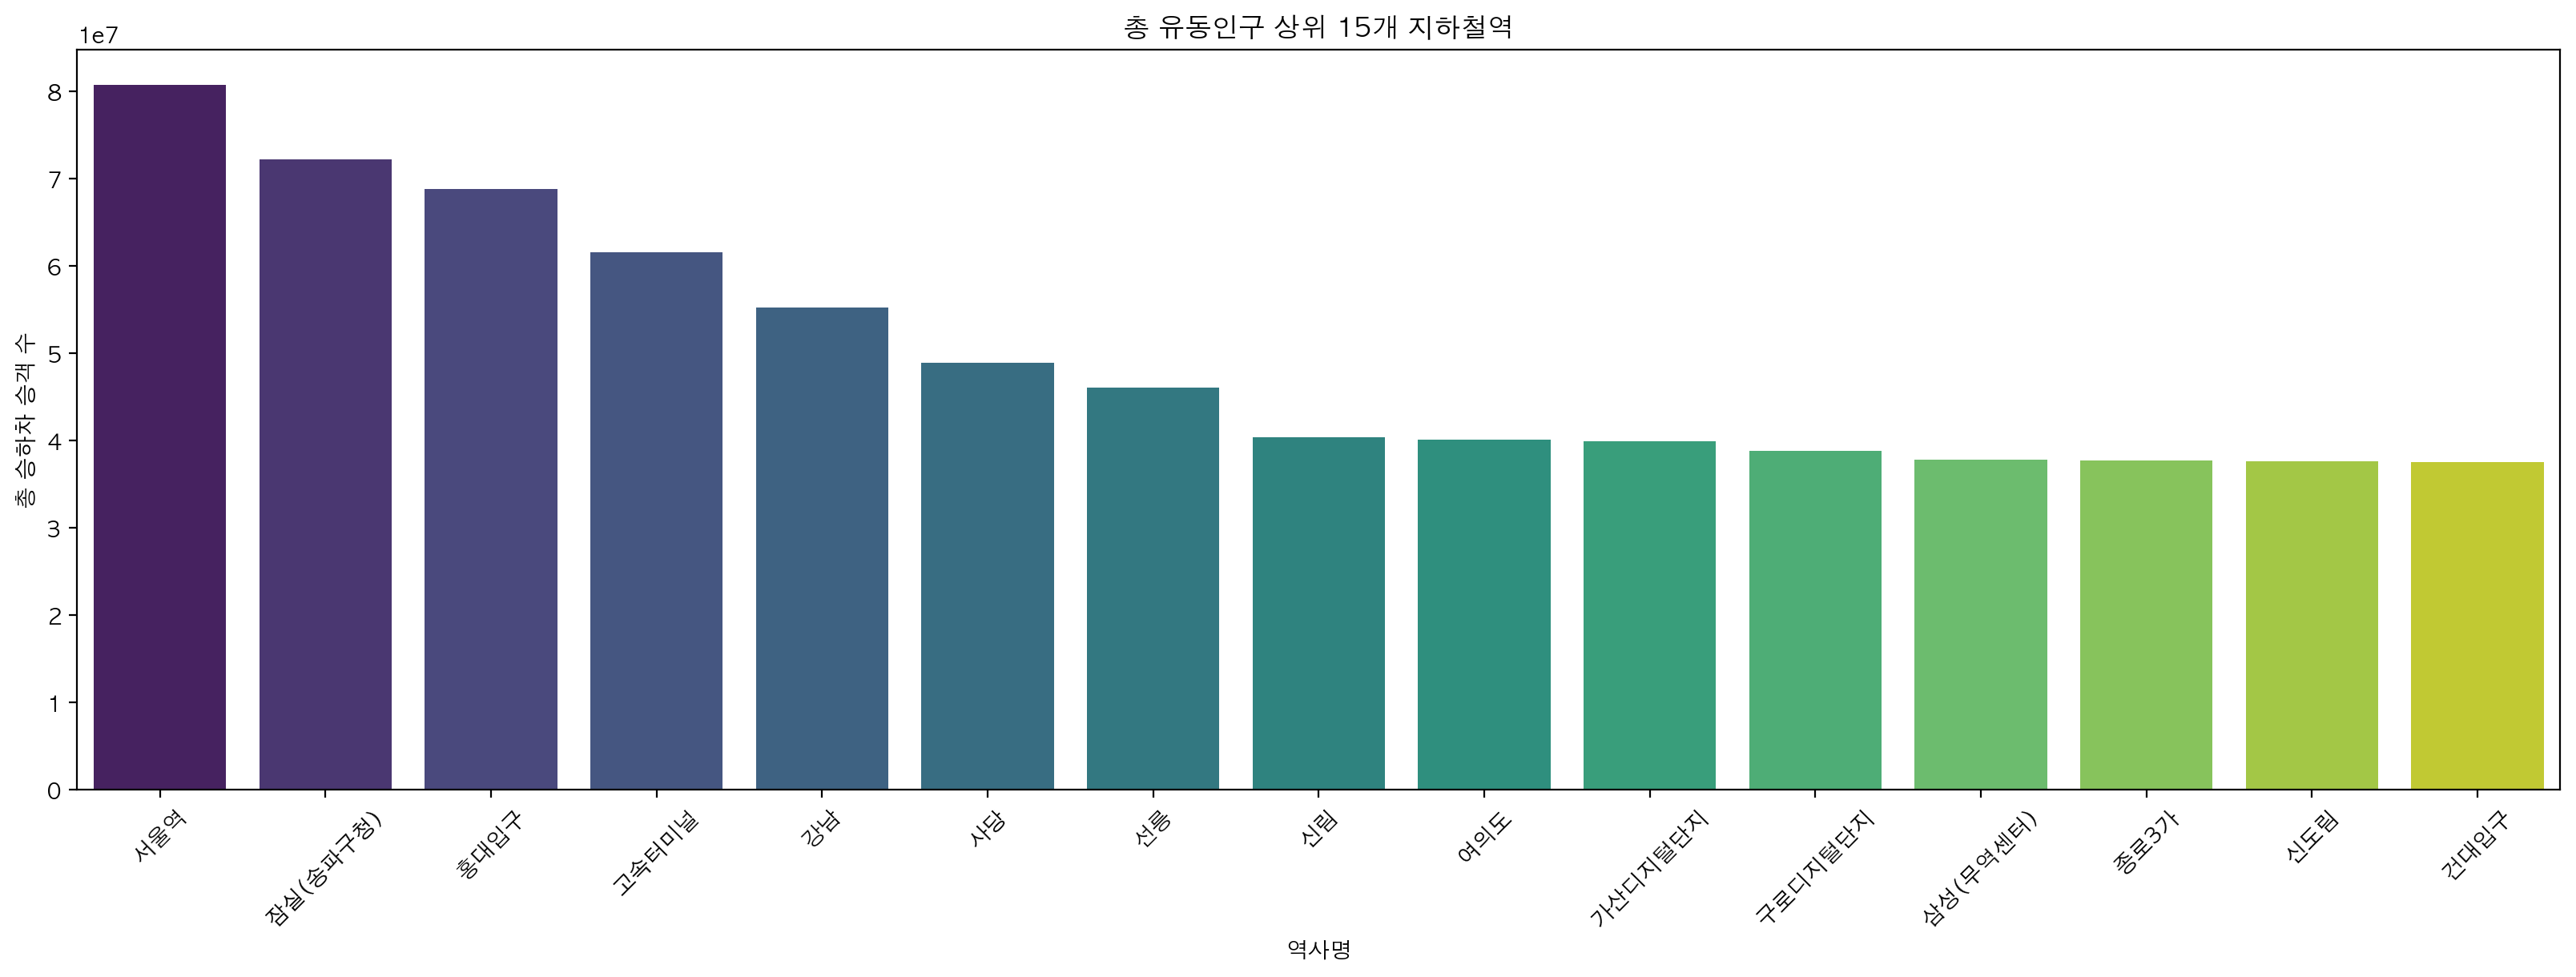

In [6]:
# 1. 역사명 기준으로 총승하차승객수를 먼저 다 합쳐줍니다 (월별/호선별 데이터 병합)
station_grouped = gdf_subway_final.groupby('역사명')['총승하차승객수'].sum().reset_index()

# 2. 합산된 데이터를 기준으로 다시 상위 15개 역을 추출합니다
top_stations = station_grouped.sort_values(by='총승하차승객수', ascending=False).head(15)

# 3. 그래프 그리기
plt.figure(figsize=(20, 6))
sns.barplot(data=top_stations, x='역사명', y='총승하차승객수', palette='viridis')
plt.title('총 유동인구 상위 15개 지하철역')
plt.ylabel('총 승하차 승객 수')
plt.xlabel('역사명')
plt.xticks(rotation=45)
plt.show()

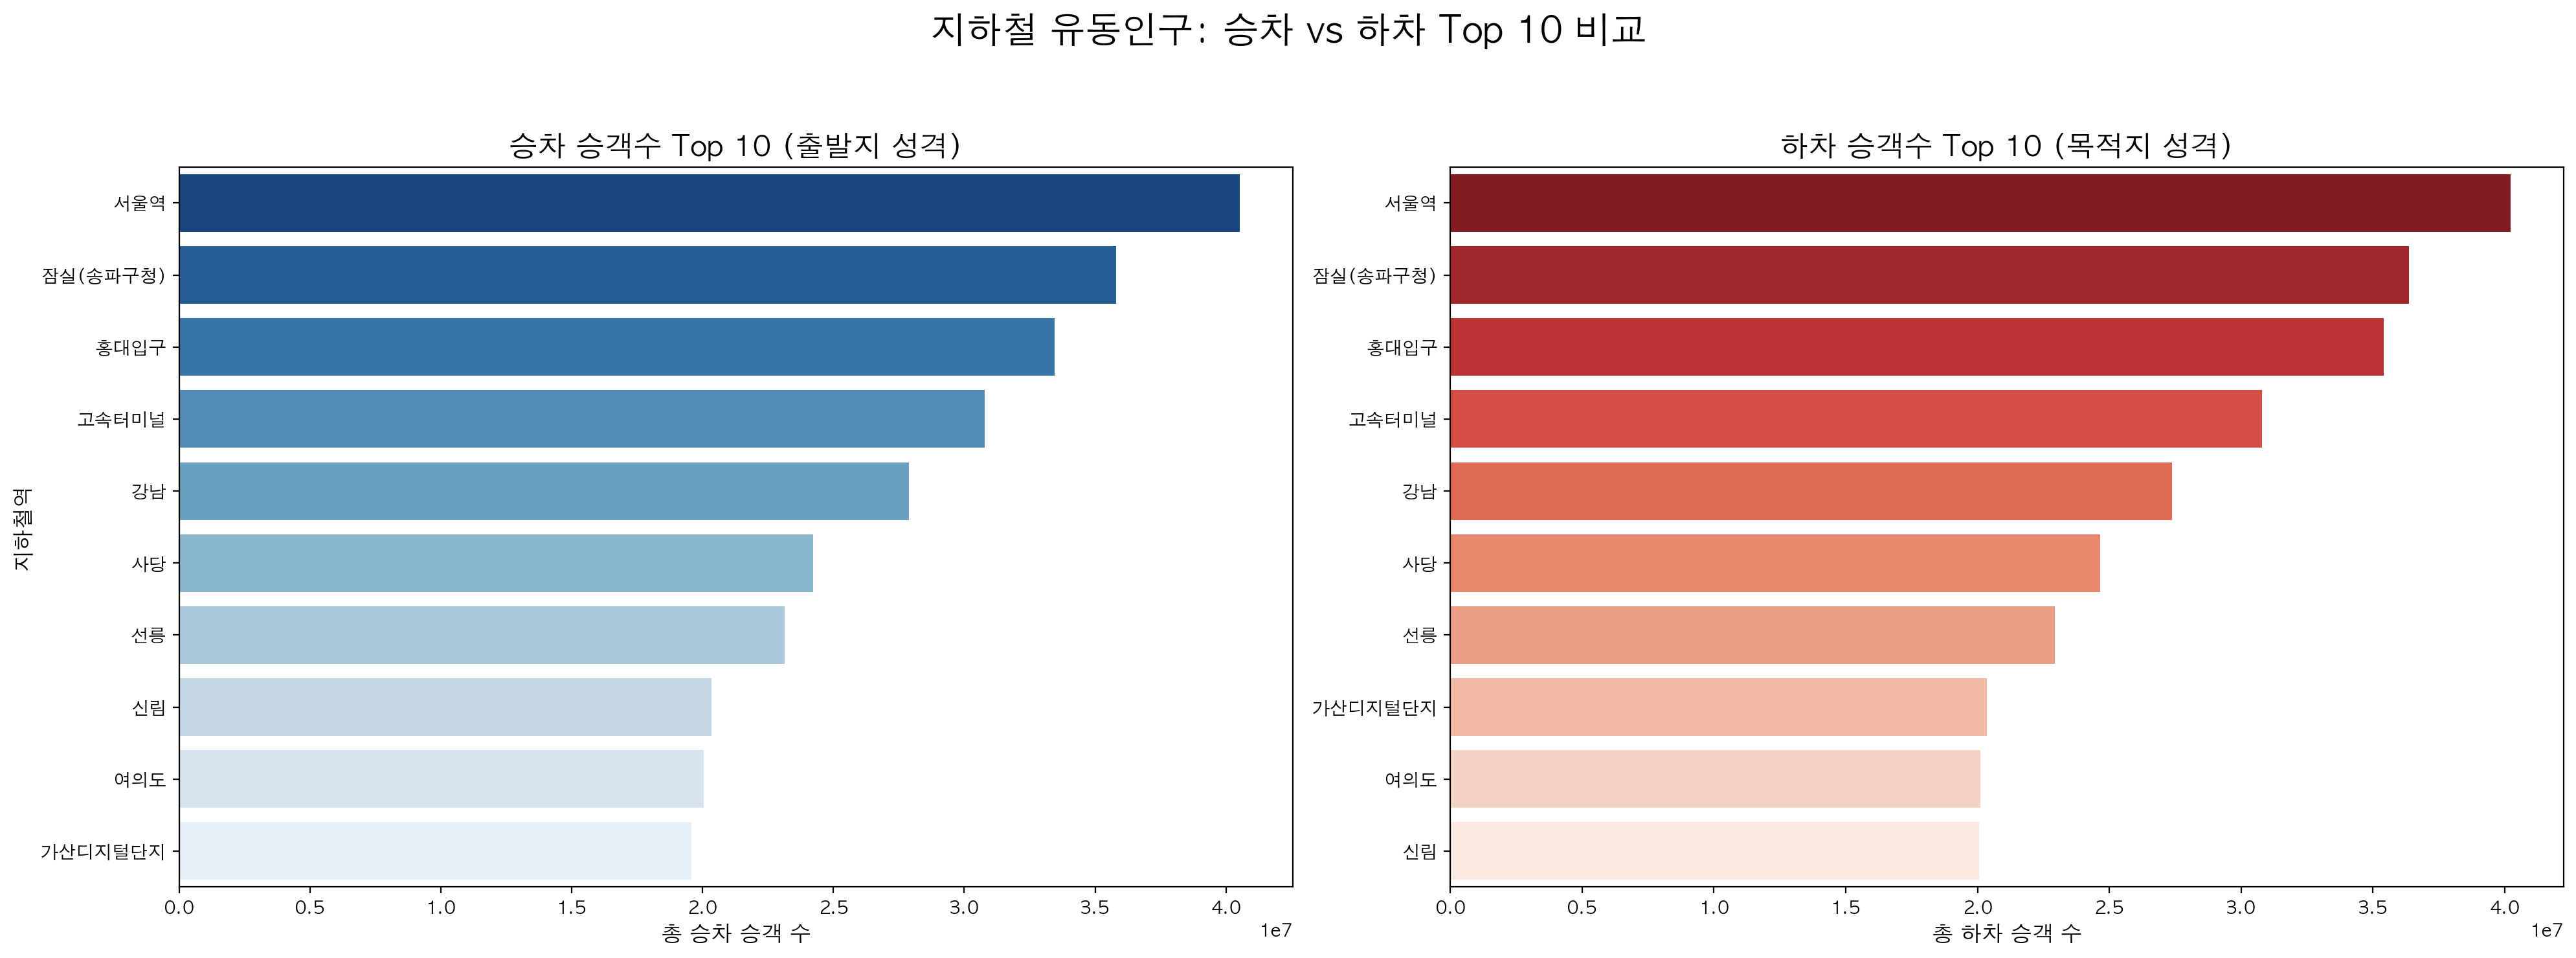

In [7]:
# 1. 역별로 승차, 하차 승객수 각각 합산
station_boarding_alighting = gdf_subway_final.groupby('역사명')[['승차총승객수', '하차총승객수']].sum().reset_index()

# 2. 승차 기준 Top 10 추출
top_10_boarding = station_boarding_alighting.sort_values(by='승차총승객수', ascending=False).head(10)

# 3. 하차 기준 Top 10 추출
top_10_alighting = station_boarding_alighting.sort_values(by='하차총승객수', ascending=False).head(10)

# 4. 그래프 그리기 (1행 2열로 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(20, 7)) # 가로 20, 세로 7 크기

# [왼쪽 그래프] 승차 승객수 Top 10
sns.barplot(
    data=top_10_boarding, 
    x='승차총승객수', 
    y='역사명', 
    ax=axes[0], 
    palette='Blues_r'
)
axes[0].set_title('승차 승객수 Top 10 (출발지 성격)', fontsize=16)
axes[0].set_xlabel('총 승차 승객 수', fontsize=12)
axes[0].set_ylabel('지하철역', fontsize=12)

# [오른쪽 그래프] 하차 승객수 Top 10
sns.barplot(
    data=top_10_alighting, 
    x='하차총승객수', 
    y='역사명', 
    ax=axes[1], 
    palette='Reds_r'
)
axes[1].set_title('하차 승객수 Top 10 (목적지 성격)', fontsize=16)
axes[1].set_xlabel('총 하차 승객 수', fontsize=12)
axes[1].set_ylabel('') # y축 라벨 생략 (왼쪽과 겹치므로)

# 5. 전체 타이틀 및 레이아웃 정리
plt.suptitle('지하철 유동인구: 승차 vs 하차 Top 10 비교', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

In [8]:
# 1. 월별, 역사명별 총승하차승객수 합산 (중복 데이터 방지)
monthly_station_traffic = gdf_subway_final.groupby(['월', '역사명'])['총승하차승객수'].sum().reset_index()

# 2. 월별로 그룹화한 뒤, 승객수 기준으로 내림차순 정렬하여 상위 10개씩만 추출
top_10_per_month = monthly_station_traffic.sort_values(['월', '총승하차승객수'], ascending=[True, False]).groupby('월').head(10)

# 3. 보기 쉽게 '순위' 컬럼 추가
top_10_per_month['순위'] = top_10_per_month.groupby('월').cumcount() + 1

# 4. 피벗 테이블을 활용해 가로축은 '월', 세로축은 '순위'인 깔끔한 표로 변환
ranking_table = top_10_per_month.pivot(index='순위', columns='월', values='역사명')

print("월별 유동인구 Top 10 지하철역 순위표")
display(ranking_table)

월별 유동인구 Top 10 지하철역 순위표


월,1,2,3,4,5,6,7,8,9,10,11,12
순위,,,,,,,,,,,,
1,서울역,서울역,서울역,서울역,서울역,서울역,서울역,서울역,서울역,서울역,서울역,서울역
2,잠실(송파구청),잠실(송파구청),홍대입구,잠실(송파구청),잠실(송파구청),잠실(송파구청),잠실(송파구청),잠실(송파구청),잠실(송파구청),잠실(송파구청),잠실(송파구청),잠실(송파구청)
3,홍대입구,홍대입구,잠실(송파구청),홍대입구,홍대입구,홍대입구,홍대입구,홍대입구,홍대입구,홍대입구,홍대입구,홍대입구
4,고속터미널,고속터미널,고속터미널,고속터미널,고속터미널,고속터미널,고속터미널,고속터미널,고속터미널,고속터미널,고속터미널,고속터미널
5,강남,강남,강남,강남,강남,강남,강남,강남,강남,강남,강남,강남
6,사당,사당,사당,사당,사당,사당,선릉,사당,사당,사당,사당,사당
7,선릉,선릉,선릉,선릉,선릉,선릉,사당,선릉,선릉,선릉,선릉,선릉
8,신림,가산디지털단지,신림,가산디지털단지,신림,신림,여의도,신림,여의도,신림,성수,성수
9,가산디지털단지,여의도,여의도,여의도,종로3가,가산디지털단지,가산디지털단지,여의도,가산디지털단지,종로3가,신림,삼성(무역센터)


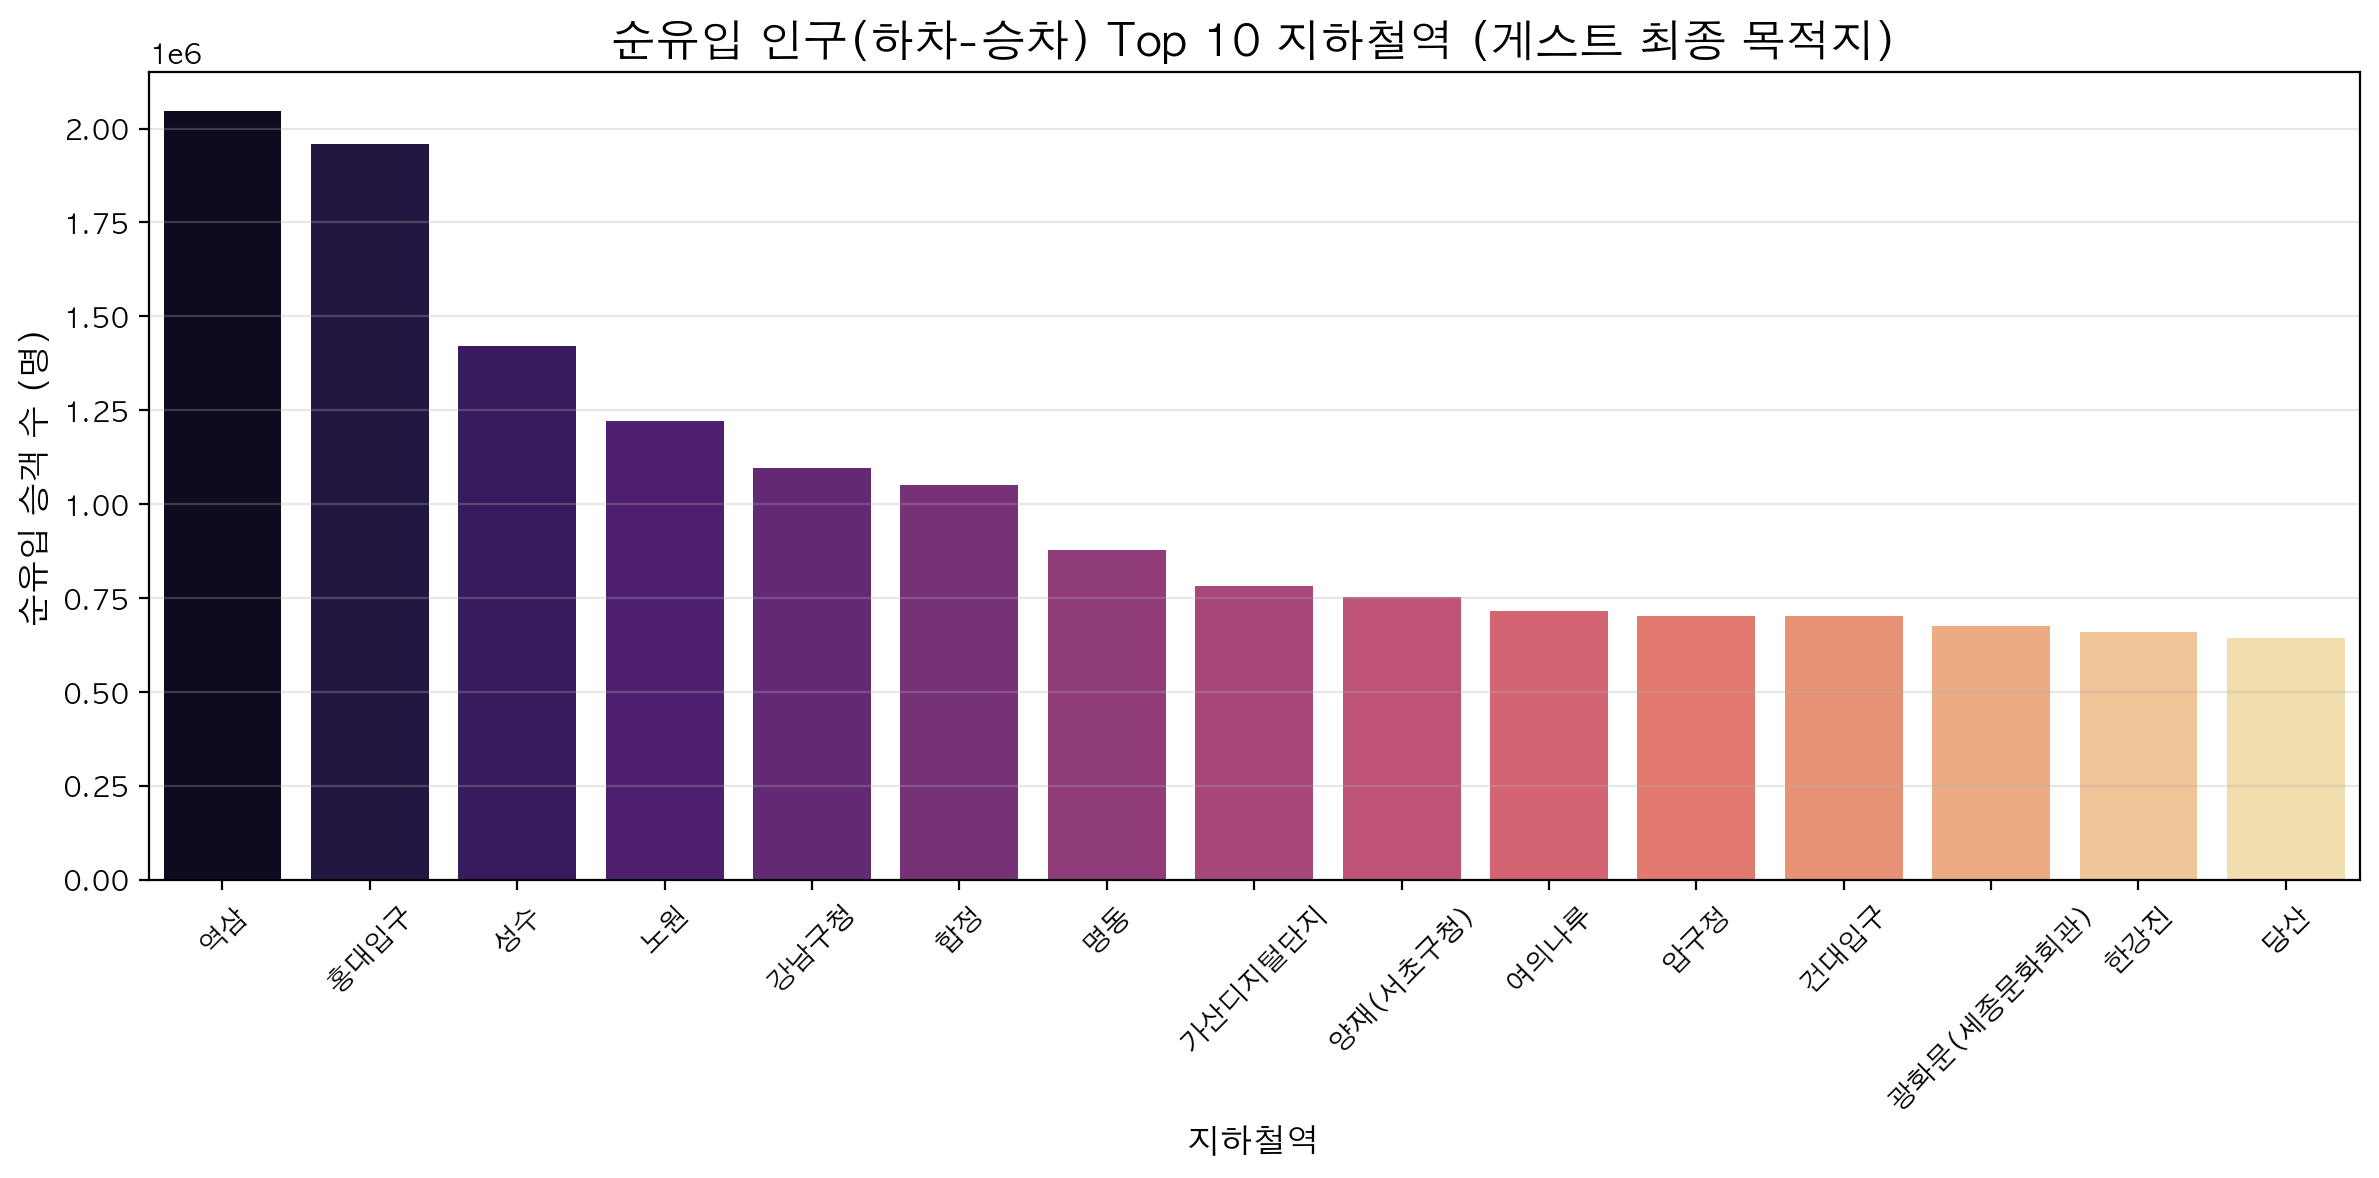

In [9]:
# 1. 역별 총 승차, 하차 승객수 합산
station_flow = gdf_subway_final.groupby('역사명')[['승차총승객수', '하차총승객수']].sum().reset_index()

# 2. '순유입 인구' 파생 변수 생성 (하차총승객수 - 승차총승객수)
station_flow['순유입인구'] = station_flow['하차총승객수'] - station_flow['승차총승객수']

# 3. 순유입 인구가 가장 많은 상위 10개 역 추출 (진짜 핫플레이스)
top_10_net_inflow = station_flow.sort_values(by='순유입인구', ascending=False).head(15)

# 4. 시각화 (바 차트)
plt.figure(figsize=(12, 6))

# 강렬한 색상 팔레트 사용하여 집중도 높이기
sns.barplot(
    data=top_10_net_inflow, 
    x='역사명', 
    y='순유입인구', 
    palette='magma'
)

plt.title('순유입 인구(하차-승차) Top 10 지하철역 (게스트 최종 목적지)', fontsize=16)
plt.ylabel('순유입 승객 수 (명)', fontsize=12)
plt.xlabel('지하철역', fontsize=12)
plt.xticks(rotation=45)

# 기준선 (0) 추가 및 그리드 설정
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

## 상권 유동인구

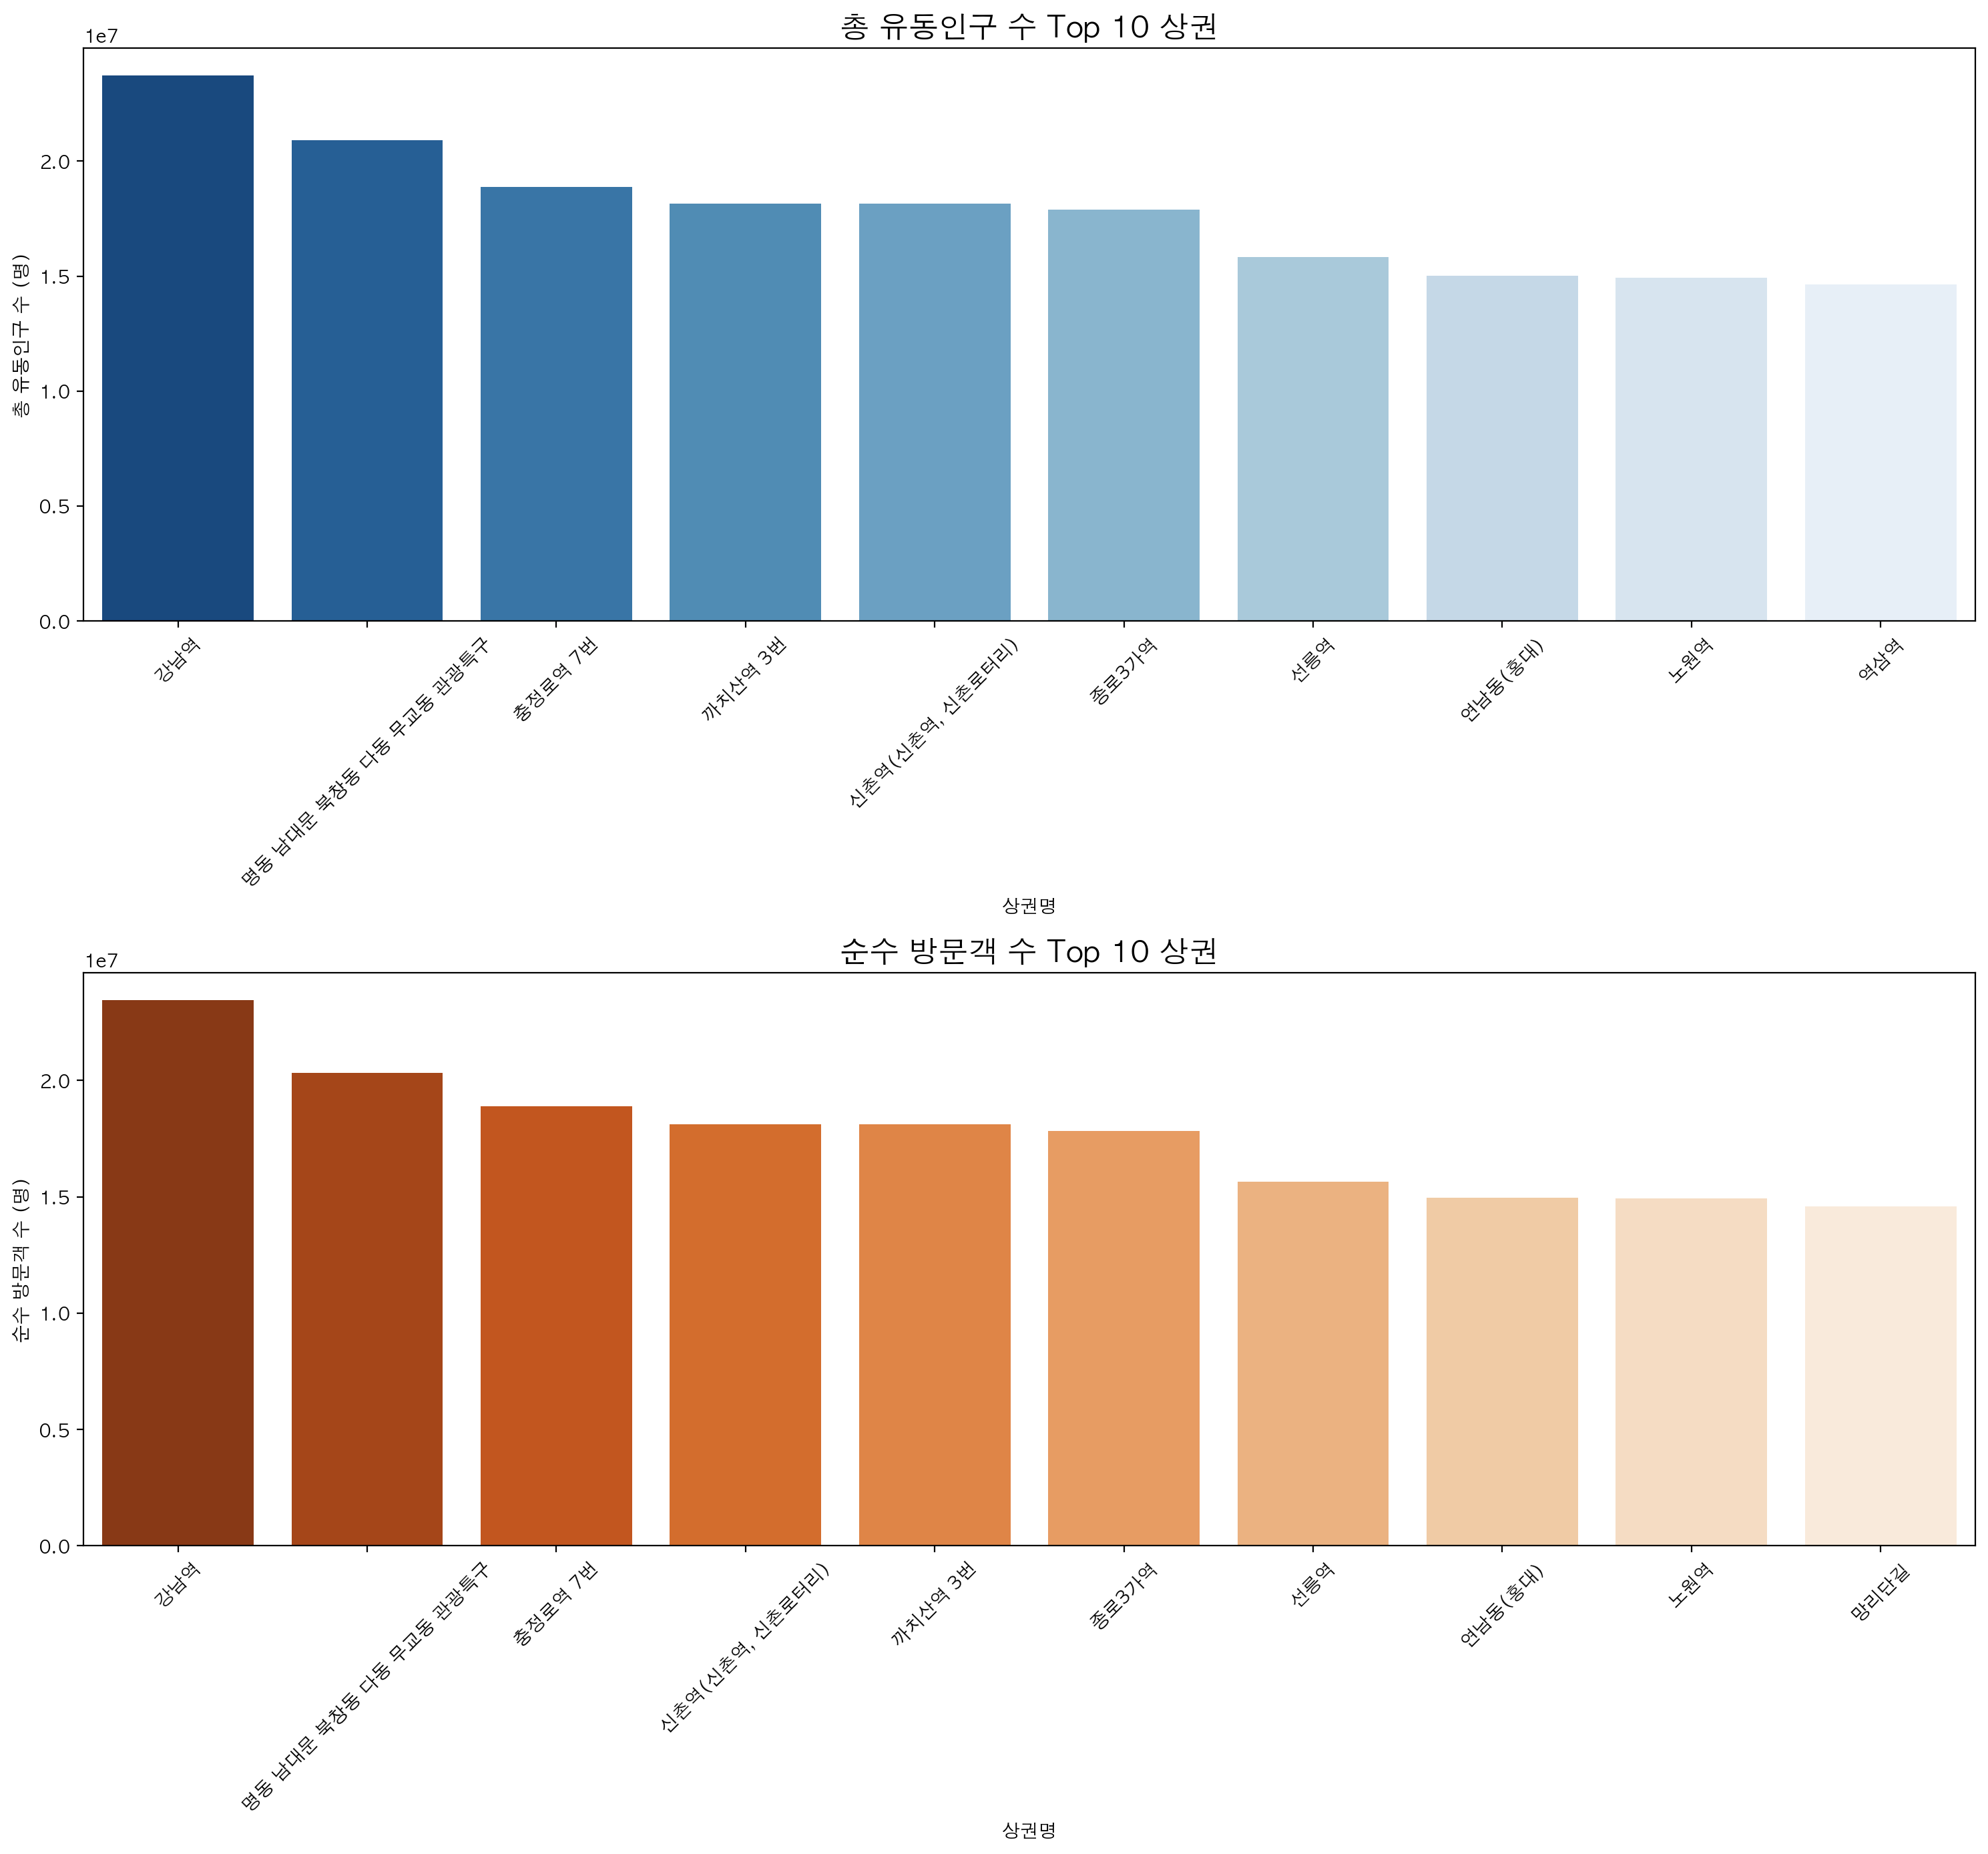

In [10]:
# 1. '총_순수방문객_수' 파생변수 생성 (총 유동인구 - (직장인구 + 상주인구))
df_commerce_final['총_순수방문객_수'] = df_commerce_final['총_유동인구_수'] - (df_commerce_final['총_직장_인구_수'] + df_commerce_final['총_상주인구_수'])

# ==============================================================

# 2. 상권명 기준으로 데이터 합산 (분기별 데이터 통합)
grouped_data = df_commerce_final.groupby('상권_코드_명')[['총_유동인구_수', '총_순수방문객_수']].sum().reset_index()

# 3. 각각의 Top 10 데이터 추출
# [1] 총 유동인구 기준 Top 10
top10_total = grouped_data.sort_values(by='총_유동인구_수', ascending=False).head(10)
# [2] 순수 방문객 수 기준 Top 10
top10_pure = grouped_data.sort_values(by='총_순수방문객_수', ascending=False).head(10)

# 4. 2행 1열 서브플롯으로 두 그래프를 위아래로 배치 (세로 길이를 14로 넉넉하게 설정)
fig, axes = plt.subplots(2, 1, figsize=(15, 14))

# [위쪽 그래프] 총 유동인구 Top 10
sns.barplot(data=top10_total, x='상권_코드_명', y='총_유동인구_수', ax=axes[0], palette='Blues_r')
axes[0].set_title('총 유동인구 수 Top 10 상권', fontsize=16)
axes[0].set_ylabel('총 유동인구 수 (명)')
axes[0].set_xlabel('상권명')
axes[0].tick_params(axis='x', rotation=45)

# [아래쪽 그래프] 순수 방문객 수 Top 10
sns.barplot(data=top10_pure, x='상권_코드_명', y='총_순수방문객_수', ax=axes[1], palette='Oranges_r')
axes[1].set_title('순수 방문객 수 Top 10 상권', fontsize=16)
axes[1].set_ylabel('순수 방문객 수 (명)')
axes[1].set_xlabel('상권명')
axes[1].tick_params(axis='x', rotation=45)

# 레이아웃 여백 자동 조정 및 출력
plt.tight_layout()
plt.show()

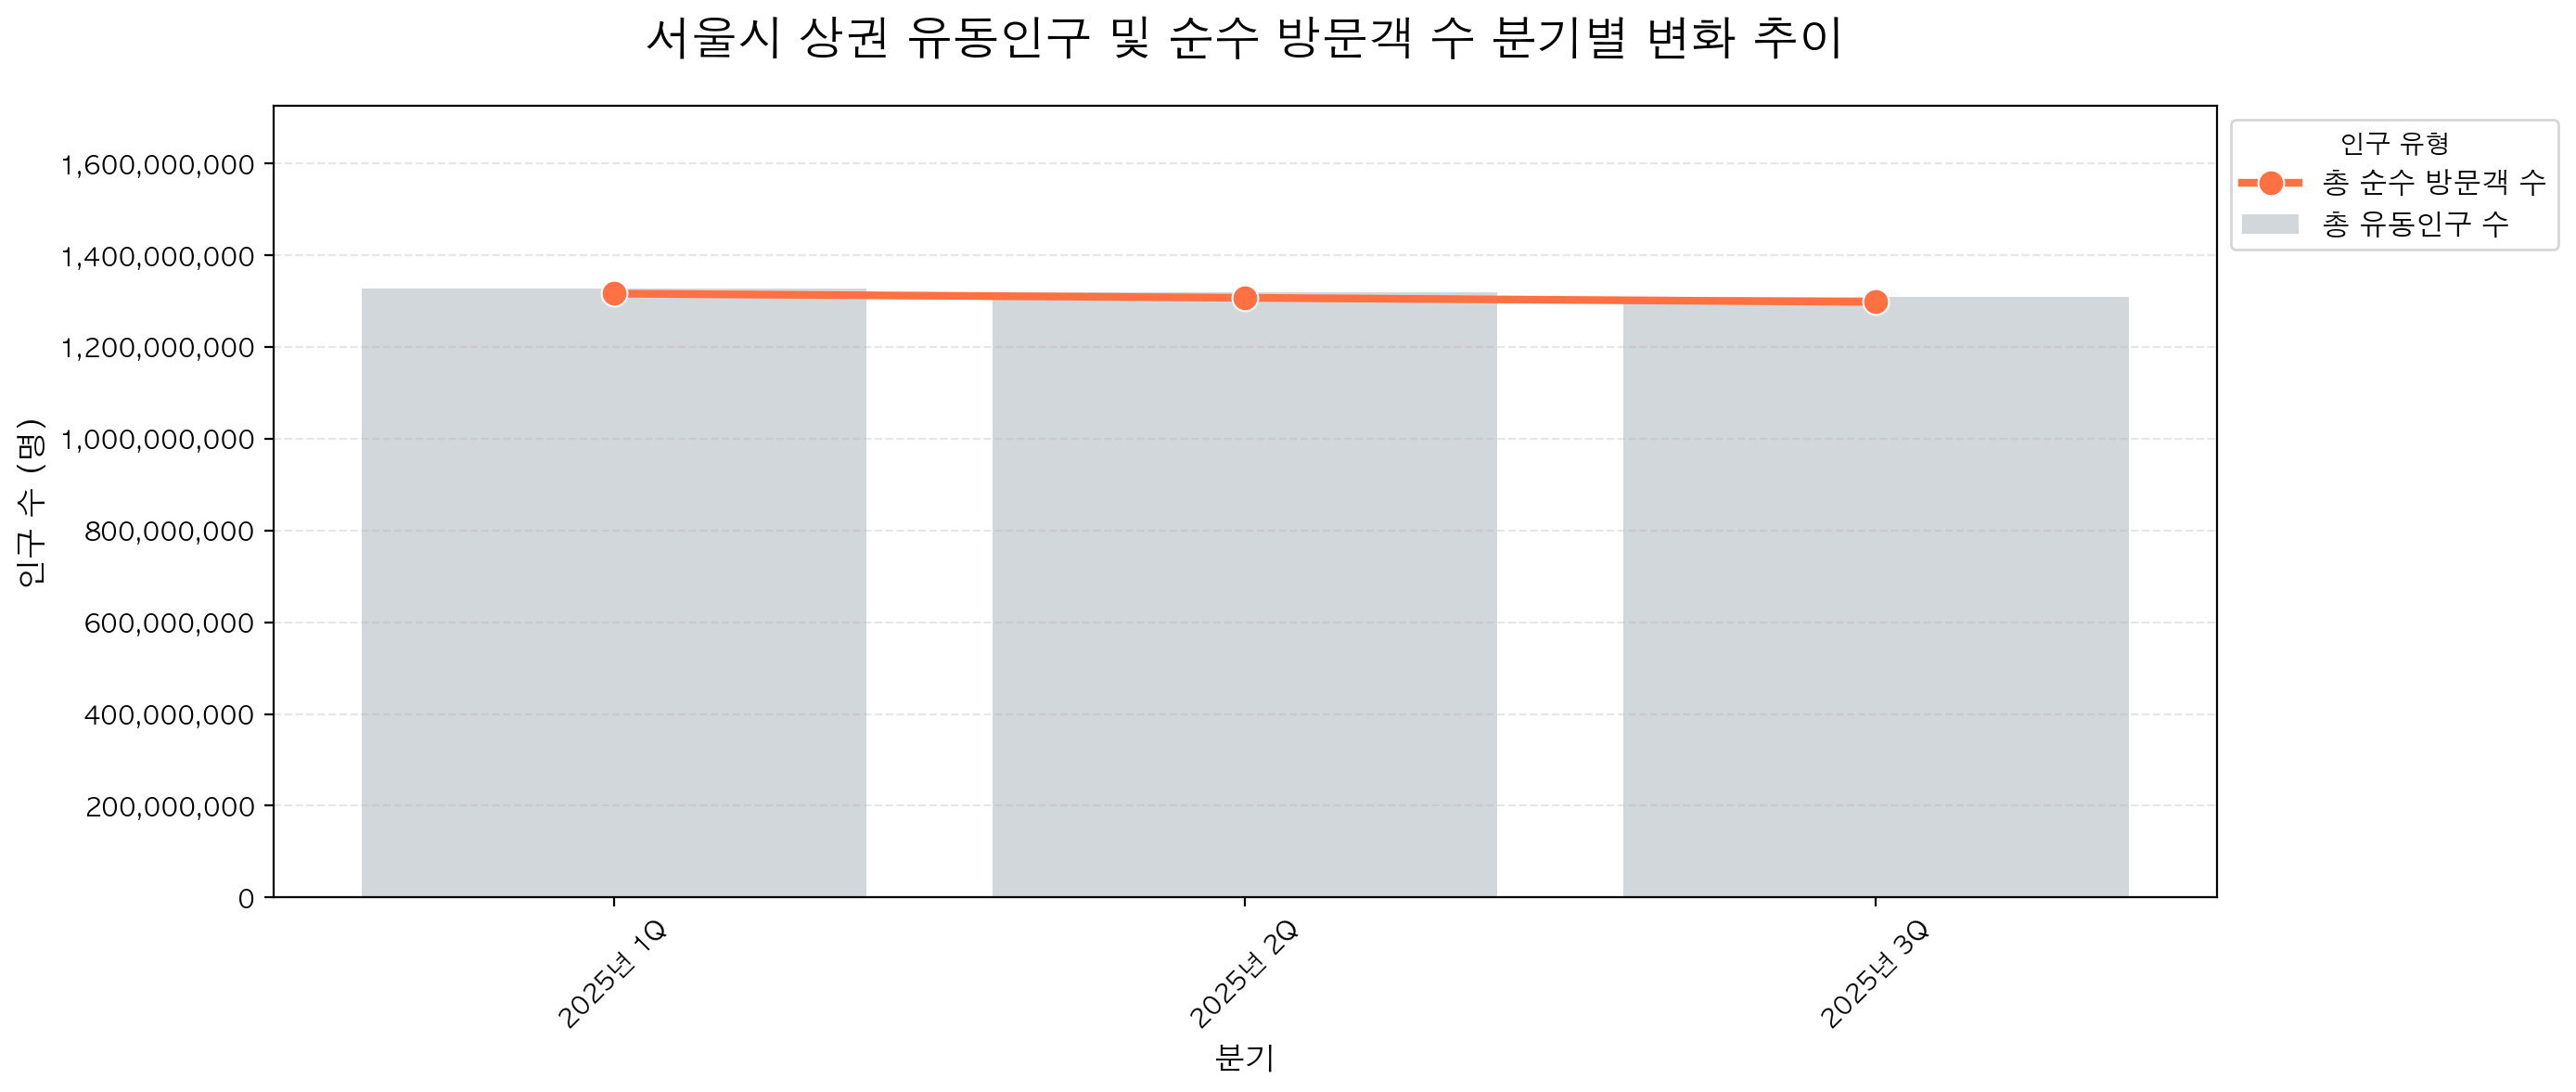

In [11]:
# ==========================================
# 1. 데이터 집계 및 포맷팅
# ==========================================
quarterly_trend = df_commerce_final.groupby('기준_년분기_코드')[['총_유동인구_수', '총_순수방문객_수']].sum().reset_index()
quarterly_trend['분기_포맷'] = quarterly_trend['기준_년분기_코드'].astype(str).str[:4] + '년 ' + quarterly_trend['기준_년분기_코드'].astype(str).str[4] + 'Q'

# ==========================================
# 2. 막대그래프 + 선 그래프 (콤보 차트) 시각화
# ==========================================
plt.figure(figsize=(14, 6))

# [1] 막대 그래프: 총 유동인구 수
sns.barplot(
    data=quarterly_trend, 
    x='분기_포맷', 
    y='총_유동인구_수', 
    color='#B0BEC5', 
    alpha=0.6, # 조금 더 투명하게 해서 선 그래프를 강조
    label='총 유동인구 수'
)

# [2] 선 그래프: 총 순수 방문객 수
sns.lineplot(
    data=quarterly_trend, 
    x='분기_포맷', 
    y='총_순수방문객_수', 
    marker='o', 
    color='#FF7043', 
    linewidth=3, # 선을 조금 더 굵고 선명하게
    markersize=10,
    label='총 순수 방문객 수'
)

# ==========================================
# 3. 🎨 Y축 여백(Headroom) 넉넉하게 주기
# ==========================================
# 유동인구 최댓값을 구한 뒤, 그 값의 1.3배(30% 여백)를 Y축의 끝으로 설정합니다.
max_y_value = quarterly_trend['총_유동인구_수'].max()
plt.ylim(0, max_y_value * 1.3) 

# ==========================================
# 4. 디자인 및 레이아웃 설정
# ==========================================
plt.title('서울시 상권 유동인구 및 순수 방문객 수 분기별 변화 추이', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('분기', fontsize=12)
plt.ylabel('인구 수 (명)', fontsize=12)
plt.xticks(rotation=45)

# Y축 그리드선 추가 (점선으로 은은하게)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

# 범례 위치를 그래프 오른쪽 상단 바깥으로 깔끔하게 이동
plt.legend(title='인구 유형', fontsize=11, loc='upper left', bbox_to_anchor=(1, 1))

# 숫자(Y축)가 지수형태(1e8 등)로 나오는 것을 방지하고 일반 숫자로 표시
plt.ticklabel_format(axis='y', style='plain')
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ','))) # 천 단위 콤마 추가

plt.tight_layout()
plt.show()

In [12]:
#야간 vs 주간 
# 1. 계산에 사용할 시간대별 컬럼 리스트 정의
daytime_cols = ['시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수']
nighttime_cols = ['시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수', '시간대_00_06_유동인구_수']

# 데이터 숫자형 변환 (오류 발생 시 NaN 처리 후 0으로 채움)
cols_to_convert = daytime_cols + nighttime_cols
df_commerce_final[cols_to_convert] = df_commerce_final[cols_to_convert].apply(pd.to_numeric, errors='coerce').fillna(0)

# 2. 로우(분기)별 주간/야간 유동인구 합계 및 비중 계산 (groupby 없이 바로 계산)
df_commerce_final['주간_유동인구_수'] = df_commerce_final[daytime_cols].sum(axis=1)
df_commerce_final['야간_유동인구_수'] = df_commerce_final[nighttime_cols].sum(axis=1)
df_commerce_final['총_유동인구_합계'] = df_commerce_final['주간_유동인구_수'] + df_commerce_final['야간_유동인구_수']

# 0으로 나누기 방지
df_commerce_final['주간_유동인구_비중'] = np.where(df_commerce_final['총_유동인구_합계'] == 0, 0, 
                                            (df_commerce_final['주간_유동인구_수'] / df_commerce_final['총_유동인구_합계']) * 100)
df_commerce_final['야간_유동인구_비중'] = np.where(df_commerce_final['총_유동인구_합계'] == 0, 0, 
                                            (df_commerce_final['야간_유동인구_수'] / df_commerce_final['총_유동인구_합계']) * 100)

# 3. 주간/야간/종일 활성화 유형 라벨링 적용 (비중 차이 10%p 이하 기준)
conditions = [
    abs(df_commerce_final['주간_유동인구_비중'] - df_commerce_final['야간_유동인구_비중']) <= 10,
    df_commerce_final['주간_유동인구_비중'] > df_commerce_final['야간_유동인구_비중']
]
choices = ['종일 활성화', '주간 활성화']

df_commerce_final['시간대별_활성화_유형'] = np.select(conditions, choices, default='야간 활성화')
df_commerce_final.loc[df_commerce_final['총_유동인구_합계'] == 0, '시간대별_활성화_유형'] = '데이터 없음'


# 4. 🌟 자치구별/상권별/분기별 피벗 테이블 생성 (시간대별 활성화 유형)
quarter_col = '기준_년분기_코드' 

try:
    # 1. 다른 피벗 테이블과 겹치지 않도록 'pivot_time_activation'으로 변수명 변경
    pivot_time_activation = df_commerce_final.pivot_table(
        index=['자치구', '상권_구분_코드_명', '상권_코드_명'], # 행: 자치구 > 상권구분 > 상권명
        columns=quarter_col,                 # 열: 202501, 202502, 202503 등
        values='시간대별_활성화_유형',          # 값: 활성화 유형 텍스트
        aggfunc='first'                      
    )

    # 2. 💡 핵심: .reset_index()를 지웠습니다! 
    # 그래야 '강남구'가 맨 위에 한 번만 표시되고, 그 아래 상권들이 예쁘게 그룹화되어 묶여 보입니다.

    print("📊 자치구 내 상권별 분기 변화 요약:")
    display(pivot_time_activation.head())
    
except KeyError as e:
    print(f"오류: 데이터프레임에 필요한 컬럼이 없습니다. {e}")

📊 자치구 내 상권별 분기 변화 요약:


기준_년분기_코드                         20251   20252   20253
자치구 상권_구분_코드_명 상권_코드_명                                 
강남구 골목상권       강남구보훈회관           종일 활성화  종일 활성화  종일 활성화
               강남구청역 2번          주간 활성화  종일 활성화  주간 활성화
               강남구청역 4번          종일 활성화  종일 활성화  종일 활성화
               강남세브란스병원미래의학연구센터  야간 활성화  종일 활성화  종일 활성화
               개포고등학교            종일 활성화  종일 활성화  종일 활성화

In [13]:
pivot_time_activation.head(20)

기준_년분기_코드                          20251   20252   20253
자치구 상권_구분_코드_명 상권_코드_명                                  
강남구 골목상권       강남구보훈회관            종일 활성화  종일 활성화  종일 활성화
               강남구청역 2번           주간 활성화  종일 활성화  주간 활성화
               강남구청역 4번           종일 활성화  종일 활성화  종일 활성화
               강남세브란스병원미래의학연구센터   야간 활성화  종일 활성화  종일 활성화
               개포고등학교             종일 활성화  종일 활성화  종일 활성화
               개포지구대옆             야간 활성화  야간 활성화  야간 활성화
               개포지하차도 북측          야간 활성화  야간 활성화  야간 활성화
               국기원                종일 활성화  종일 활성화  종일 활성화
               국립국악고등학교           야간 활성화  야간 활성화  야간 활성화
               국악고교사거리            야간 활성화  야간 활성화  야간 활성화
               논현2동주민센터           주간 활성화  종일 활성화  주간 활성화
               논현로18길             종일 활성화  종일 활성화  종일 활성화
               논현목련공원             야간 활성화  야간 활성화  야간 활성화
               논현역 7번             주간 활성화  주간 활성화  주간 활성화
               논현초등학교             종일 활성화  종일 활성화  종일 활성화
               대왕초등학교(세곡동사거리서남측)  종일 활성화  종일 활성화  종일 활성화
               대청초등학교             야간 활성화  야간 활성화  야간 활성화
               대치2동주민센터           야간 활성화  야간 활성화  야간 활성화
               대치동아우편취급국          종일 활성화  종일 활성화  종일 활성화
               도곡2동주민센터(대치중학교)    종일 활성화  종일 활성화  종일 활성화

NameError: name 'PercentFormatter' is not defined

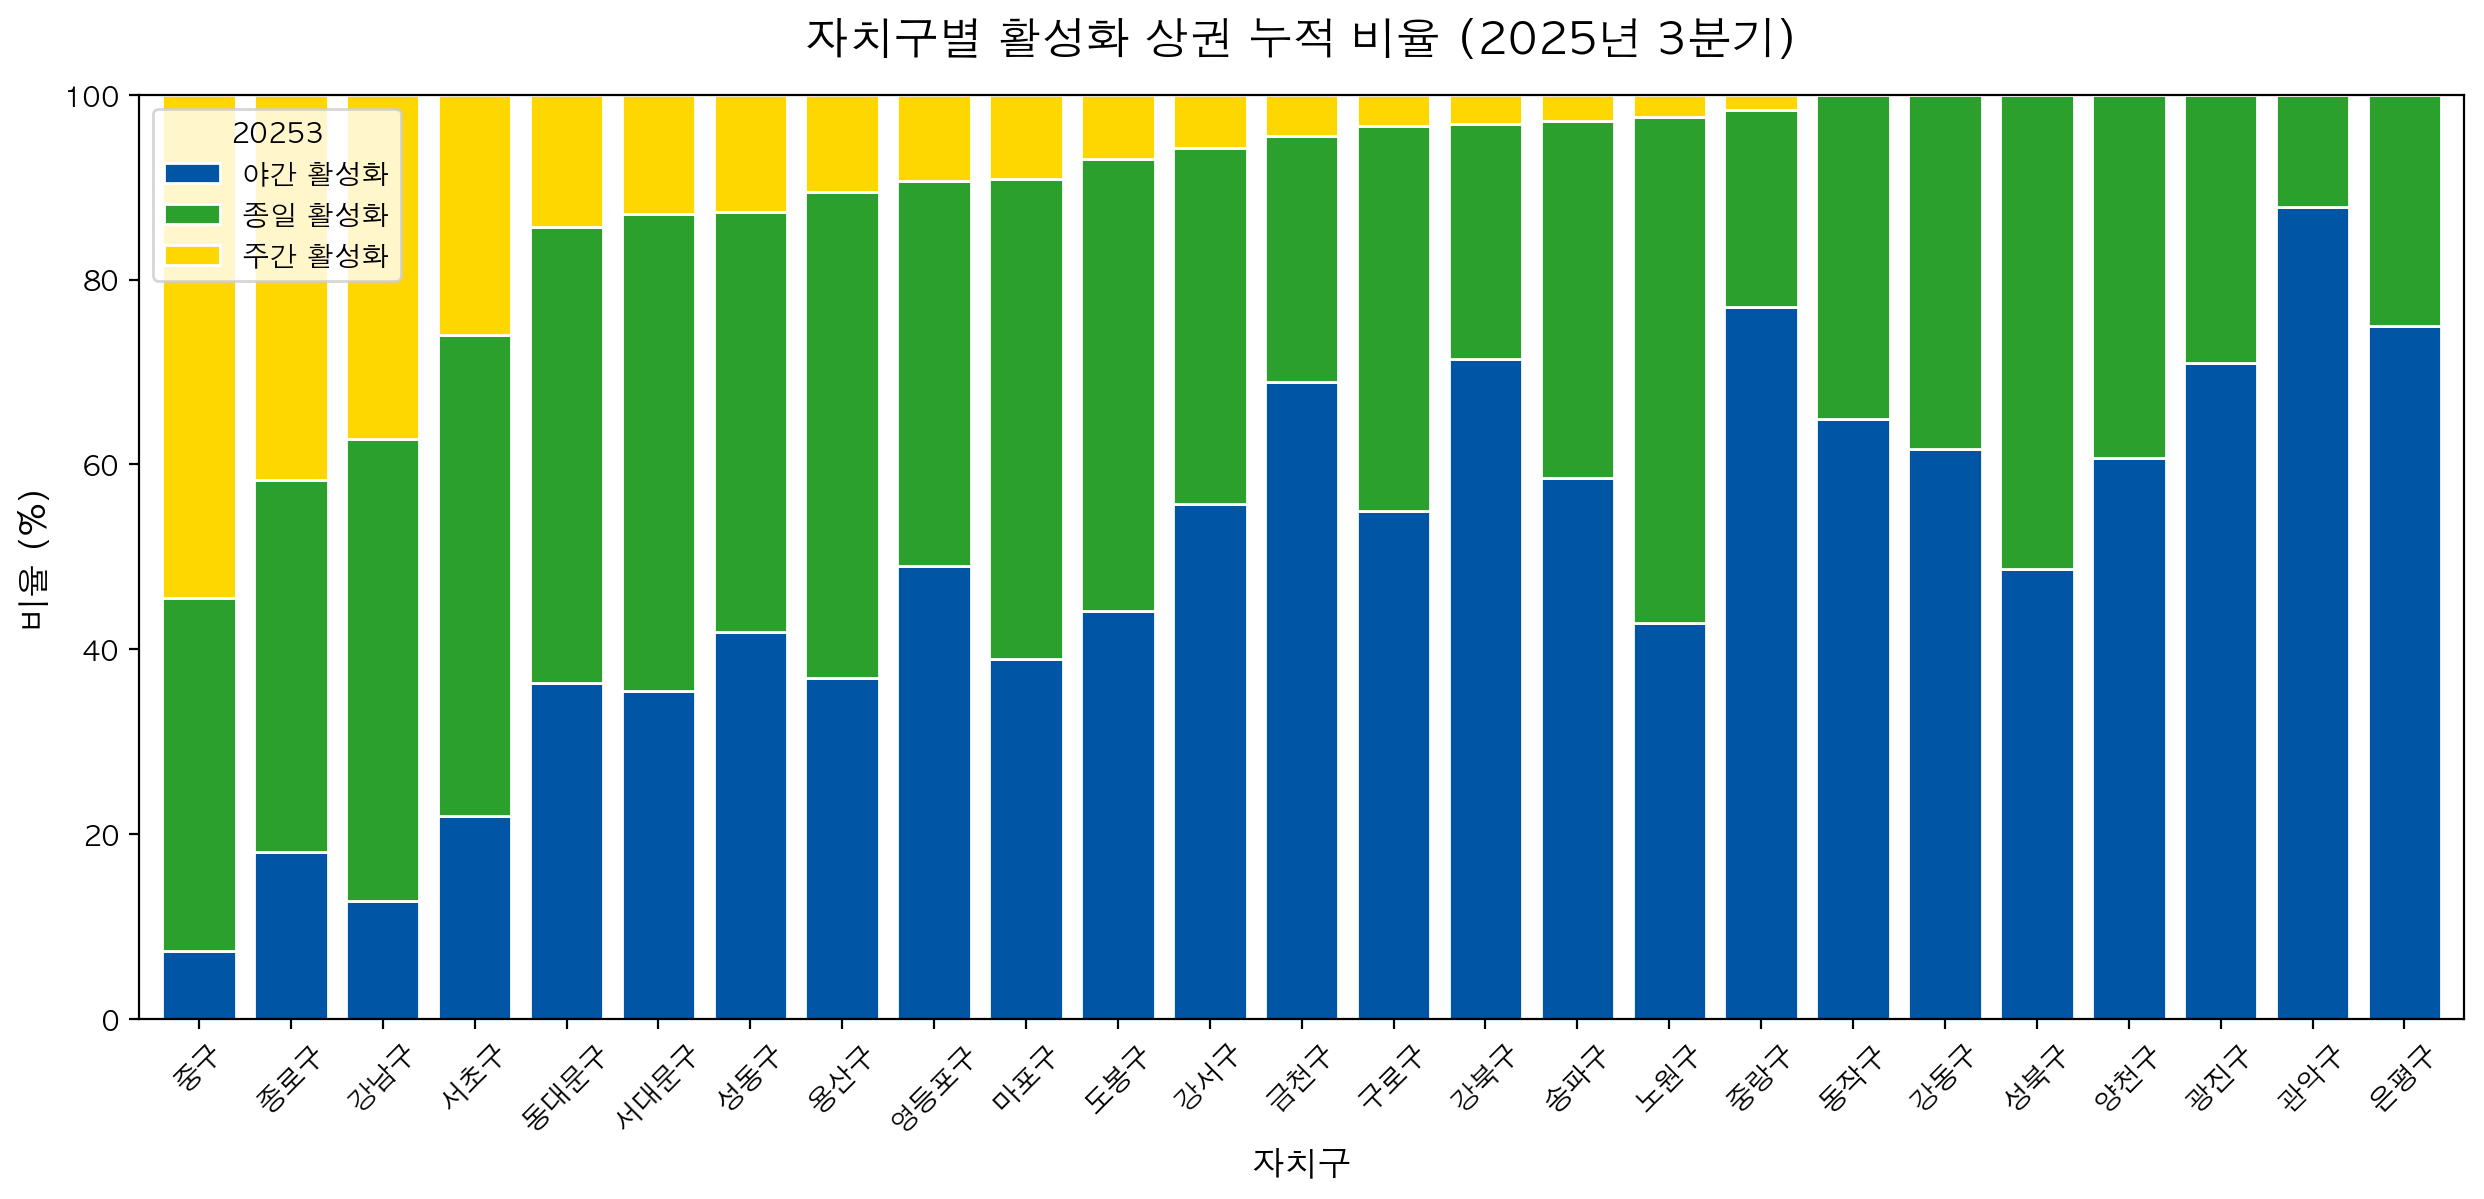

In [14]:
# 1. 인덱스 초기화 (자치구별 그룹화를 위해)
df_reset = pivot_time_activation.reset_index()

# 2. 기준 분기 컬럼 자동 탐색 (KeyError 방지)
if 20253 in df_reset.columns:
    target_col = 20253
elif '20253' in df_reset.columns:
    target_col = '20253'
# 피벗테이블 멀티인덱스 컬럼 구조일 경우를 대비
elif ('기준_년분기_코드', 20253) in df_reset.columns:
    target_col = ('기준_년분기_코드', 20253)
elif ('기준_년분기_코드', '20253') in df_reset.columns:
    target_col = ('기준_년분기_코드', '20253')
else:
    target_col = df_reset.columns[-1] # 못 찾으면 가장 마지막 컬럼 사용

# 3. 자치구 및 상권 유형별 개수 집계
count_df = df_reset.groupby(['자치구', target_col]).size().unstack(fill_value=0)

# 4. 백분율(%) 비율 계산 (각 행의 합으로 나누기)
ratio_df = count_df.div(count_df.sum(axis=1), axis=0) * 100

# 5. ⭐ '주간 활성화' 비율이 높은 순(내림차순)으로 정렬되도록 수정 ⭐
if '주간 활성화' in ratio_df.columns:
    ratio_df = ratio_df.sort_values(by='주간 활성화', ascending=False)

# 6. 대비 및 혼합 색상 지정
color_mapping = {
    '주간 활성화': '#FFD700',  # 노랑 (주간)
    '야간 활성화': '#0055A4',  # 파랑 (야간)
    '종일 활성화': '#2CA02C'   # 초록 (종일)
}

# 데이터프레임의 컬럼(활성화 유형) 순서에 맞춰 색상 리스트 생성
plot_colors = [color_mapping.get(col, '#CCCCCC') for col in ratio_df.columns]

# 7. 누적 비율 막대 그래프 그리기 (stacked=True)
ax = ratio_df.plot(kind='bar', stacked=True, figsize=(15, 6), color=plot_colors, width=0.8, edgecolor='white')

# 그래프 꾸미기
plt.title('자치구별 활성화 상권 누적 비율 (2025년 3분기)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('자치구', fontsize=12)
plt.ylabel('비율 (%)', fontsize=12)
plt.xticks(rotation=45)

# y축을 퍼센트(%) 형식으로 표시
ax.yaxis.set_major_formatter(PercentFormatter())

# 범례를 그래프 우측 바깥으로 이동
plt.legend(title='활성화 상권 유형', bbox_to_anchor=(1.01, 1), loc='upper left') 

plt.tight_layout()
plt.show()

In [15]:
#평일 vs 주말 
# 1. 요일별 유동인구 컬럼 리스트
days = [
    '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', 
    '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수'
]

# 2. 데이터 타입이 문자열(str)일 수 있으므로 안전하게 숫자형(float/int)으로 변환
# errors='coerce'를 통해 숫자로 바꿀 수 없는 값은 NaN으로 만들고, fillna(0)으로 0 처리합니다.
for day in days:
    df_commerce_final[day] = pd.to_numeric(df_commerce_final[day], errors='coerce').fillna(0)

# 3. 평일 유동인구 일평균 계산 (5일)
df_commerce_final['평일_일평균_유동인구'] = (
    df_commerce_final['월요일_유동인구_수'] + 
    df_commerce_final['화요일_유동인구_수'] + 
    df_commerce_final['수요일_유동인구_수'] + 
    df_commerce_final['목요일_유동인구_수'] + 
    df_commerce_final['금요일_유동인구_수']
) / 5

# 4. 주말 유동인구 일평균 계산 (2일)
df_commerce_final['주말_일평균_유동인구'] = (
    df_commerce_final['토요일_유동인구_수'] + 
    df_commerce_final['일요일_유동인구_수']
) / 2

# 5. 주말 일평균이 평일 일평균보다 크면 '주말 상권', 아니면 '평일 상권'으로 분류
df_commerce_final['상권_유형'] = np.where(
    df_commerce_final['주말_일평균_유동인구'] > df_commerce_final['평일_일평균_유동인구'], 
    '주말 상권', 
    '평일 상권'
)

# 6. 결과 확인 (분기, 상권코드, 상권명, 평일/주말 일평균, 상권유형)
# 가지고 계신 데이터에 '기준_년분기_코드' 컬럼이 있다면 포함해서 확인하세요!
result_cols = ['상권_코드', '상권_코드_명', '평일_일평균_유동인구', '주말_일평균_유동인구', '상권_유형']

# 데이터에 '기준_년분기_코드'가 있다면 리스트 맨 앞에 추가
if '기준_년분기_코드' in df_commerce_final.columns:
    result_cols.insert(0, '기준_년분기_코드')

In [16]:
# 피벗 테이블 생성
pivot_df = df_commerce_final.pivot_table(
    index=['자치구', '상권_구분_코드_명', '상권_코드_명'], # 행으로 들어갈 기준들
    columns='기준_년분기_코드',                        # 열로 들어갈 기준 (분기)
    values='상권_유형',                                 # 표 안에 채워넣을 값 (텍스트 컬럼 이름 입력)
    aggfunc='first'                                     # 텍스트 데이터이므로 첫 번째 값을 그대로 가져옴
)

# 데이터가 없는 분기(NaN)가 있을 경우 보기 좋게 '-' 등으로 채워주기 (선택 사항)
pivot_df = pivot_df.fillna('-')

# 결과 확인
pivot_df.head(20)

기준_년분기_코드                         20251  20252  20253
자치구 상권_구분_코드_명 상권_코드_명                               
강남구 골목상권       강남구보훈회관            주말 상권  주말 상권  주말 상권
               강남구청역 2번           평일 상권  평일 상권  평일 상권
               강남구청역 4번           평일 상권  평일 상권  평일 상권
               강남세브란스병원미래의학연구센터   평일 상권  평일 상권  평일 상권
               개포고등학교             평일 상권  평일 상권  평일 상권
               개포지구대옆             평일 상권  평일 상권  평일 상권
               개포지하차도 북측          주말 상권  주말 상권  주말 상권
               국기원                주말 상권  평일 상권  평일 상권
               국립국악고등학교           평일 상권  평일 상권  평일 상권
               국악고교사거리            평일 상권  평일 상권  평일 상권
               논현2동주민센터           평일 상권  평일 상권  평일 상권
               논현로18길             평일 상권  평일 상권  평일 상권
               논현목련공원             평일 상권  평일 상권  평일 상권
               논현역 7번             평일 상권  평일 상권  평일 상권
               논현초등학교             평일 상권  평일 상권  평일 상권
               대왕초등학교(세곡동사거리서남측)  평일 상권  평일 상권  평일 상권
               대청초등학교             평일 상권  평일 상권  평일 상권
               대치2동주민센터           주말 상권  주말 상권  주말 상권
               대치동아우편취급국          평일 상권  평일 상권  평일 상권
               도곡2동주민센터(대치중학교)    평일 상권  평일 상권  평일 상권

NameError: name 'PercentFormatter' is not defined

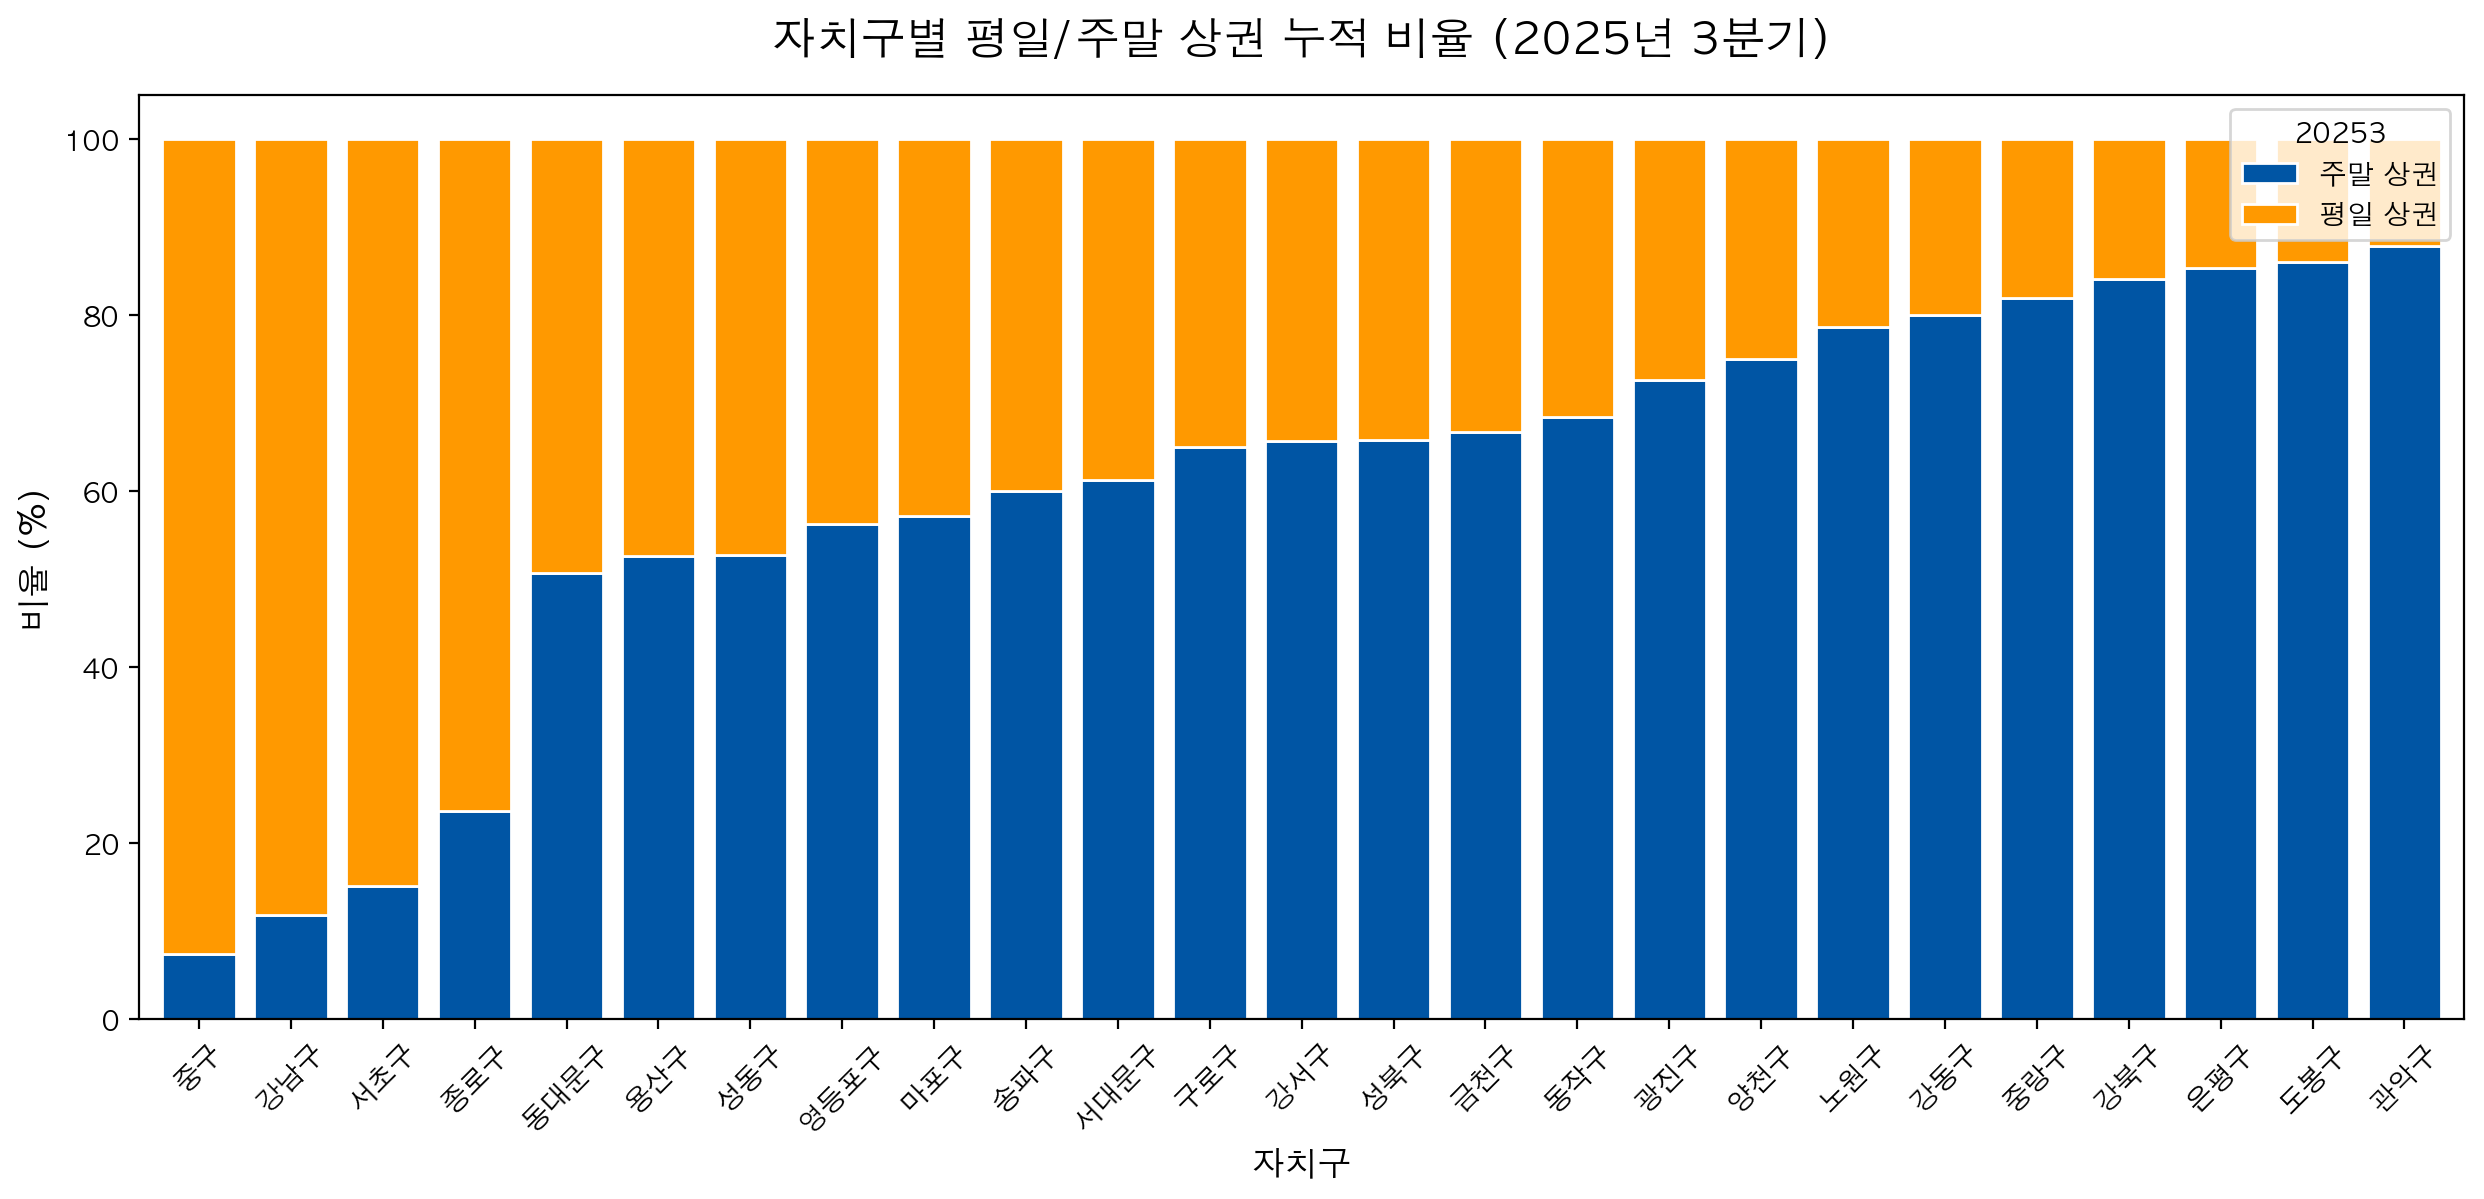

In [17]:
# 1. 인덱스 초기화 (요청하신 pivot_df 사용)
df_reset = pivot_df.reset_index()

# 2. 기준 분기 컬럼 자동 탐색
if 20253 in df_reset.columns:
    target_col = 20253
elif '20253' in df_reset.columns:
    target_col = '20253'
# 피벗테이블 멀티인덱스 컬럼 구조일 경우를 대비
elif ('기준_년분기_코드', 20253) in df_reset.columns:
    target_col = ('기준_년분기_코드', 20253)
elif ('기준_년분기_코드', '20253') in df_reset.columns:
    target_col = ('기준_년분기_코드', '20253')
else:
    target_col = df_reset.columns[-1]

# ⭐ 3. '-' (결측/미분류) 데이터 제외하기 ⭐
df_filtered = df_reset[df_reset[target_col] != '-']

# 4. 자치구 및 상권 유형별 개수 집계 (필터링된 데이터 사용)
count_df = df_filtered.groupby(['자치구', target_col]).size().unstack(fill_value=0)

# 5. 백분율(%) 비율 계산 (각 행의 합으로 나누기)
ratio_df = count_df.div(count_df.sum(axis=1), axis=0) * 100

# 6. '평일 상권' 비율이 높은 순(내림차순)으로 정렬
if '평일 상권' in ratio_df.columns:
    ratio_df = ratio_df.sort_values(by='평일 상권', ascending=False)

# 7. 대비되는 색상 지정
color_mapping = {
    '평일 상권': '#FF9900',  # 오렌지 (평일)
    '주말 상권': '#0055A4'   # 파랑 (주말)
}

# 데이터프레임의 컬럼 순서에 맞춰 색상 리스트 생성
plot_colors = [color_mapping.get(col, '#CCCCCC') for col in ratio_df.columns]

# 8. 누적 비율 막대 그래프 그리기
ax = ratio_df.plot(kind='bar', stacked=True, figsize=(15, 6), color=plot_colors, width=0.8, edgecolor='white')

# 그래프 꾸미기
plt.title('자치구별 평일/주말 상권 누적 비율 (2025년 3분기)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('자치구', fontsize=12)
plt.ylabel('비율 (%)', fontsize=12)
plt.xticks(rotation=45)

# y축을 퍼센트(%) 형식으로 표시
ax.yaxis.set_major_formatter(PercentFormatter())

# 범례를 그래프 우측 바깥으로 이동
plt.legend(title='상권 유형', bbox_to_anchor=(1.01, 1), loc='upper left') 

plt.tight_layout()
plt.show()

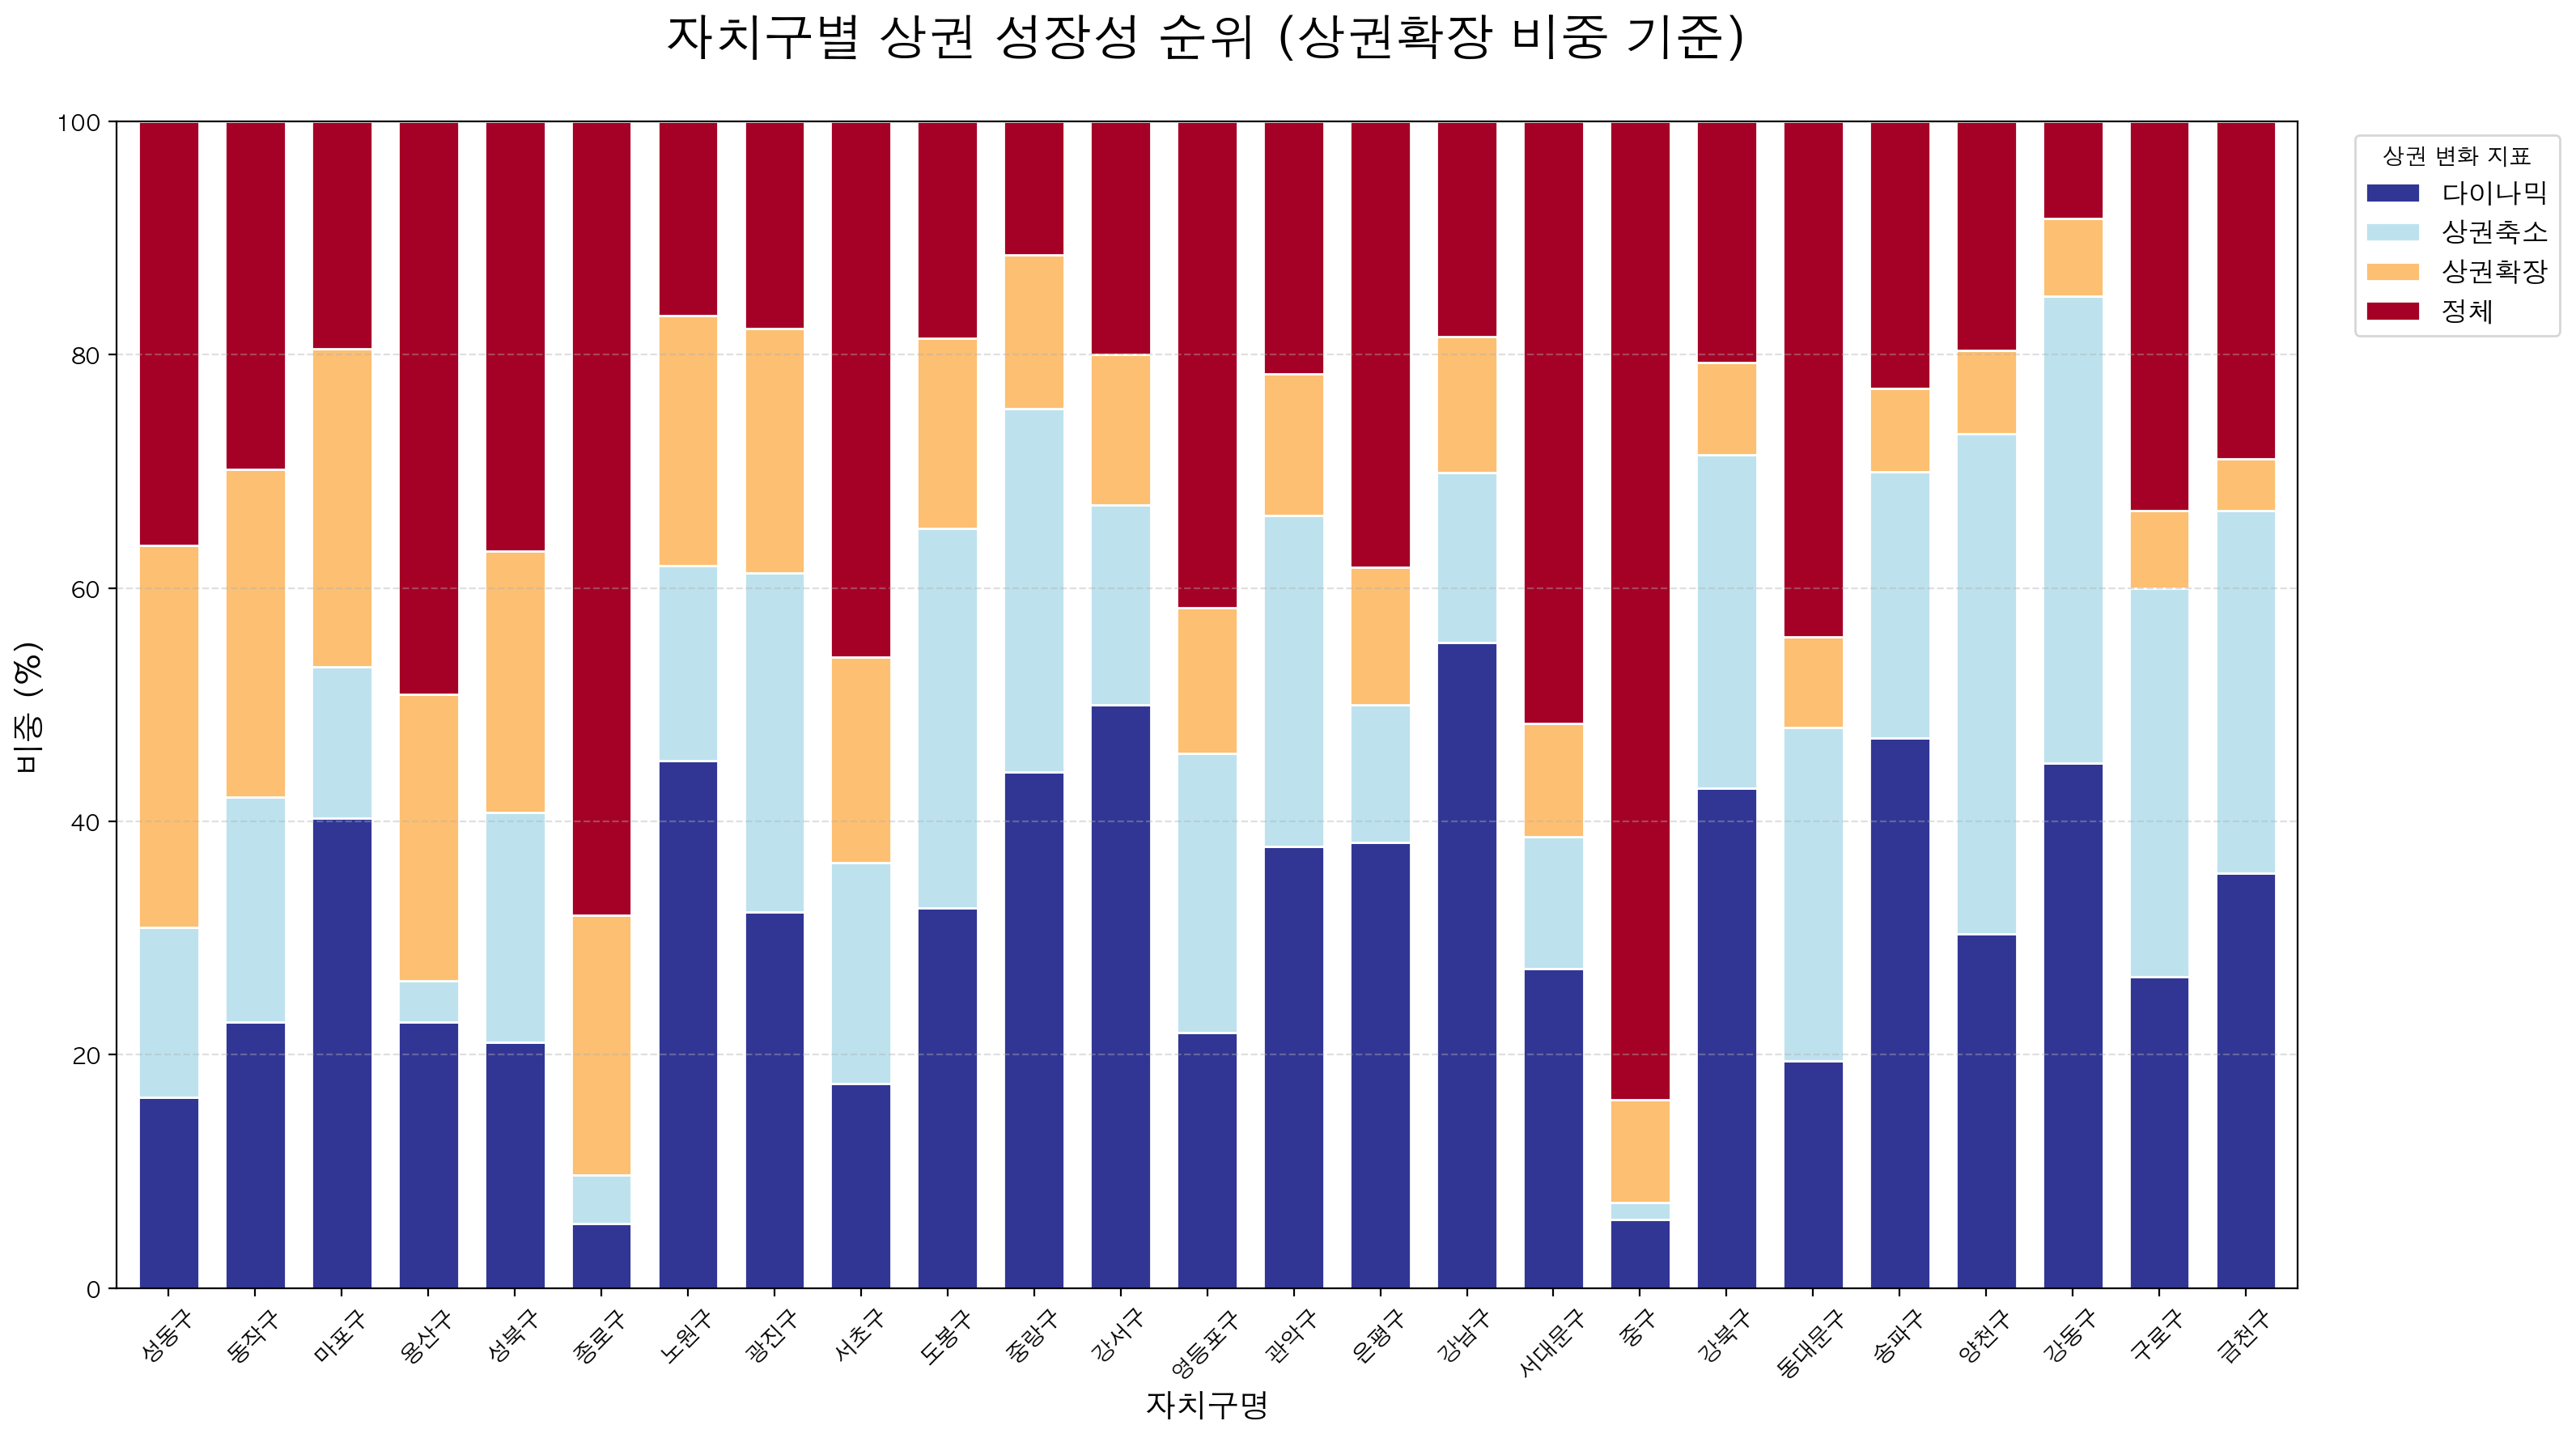

In [18]:
# 2. 최신 분기 데이터 추출 (상권코드별 중복 제거)
df_latest = df_commerce_final.sort_values(by='기준_년분기_코드', ascending=False) \
                             .drop_duplicates(subset='상권_코드')

# 3. 자치구별 상권 변화 지표 비율 계산
cross_tab_ratio = pd.crosstab(df_latest['자치구'], 
                              df_latest['상권_변화_지표_명'], 
                              normalize='index') * 100

# 4. ★ '상권확장' 비중이 높은 순서대로 자치구 정렬 ★
# 내림차순(ascending=False)으로 정렬하여 왼쪽일수록 좋은 상권 비중이 높게 표시됩니다.
cross_tab_ratio = cross_tab_ratio.sort_values(by='상권확장', ascending=False)

# 5. 시각화
fig, ax = plt.subplots(figsize=(16, 9))

# 색상 조합 (상권확장과 다이나믹이 잘 보이도록 설정)
cross_tab_ratio.plot(kind='bar', 
                     stacked=True, 
                     ax=ax, 
                     colormap='RdYlBu_r', # 성장(청색계열)과 정체(적색계열) 대비가 좋은 컬러맵
                     edgecolor='white',
                     width=0.7)

# 그래프 꾸미기
plt.title('자치구별 상권 성장성 순위 (상권확장 비중 기준)', fontsize=22, pad=30, fontweight='bold')
plt.xlabel('자치구명', fontsize=14)
plt.ylabel('비중 (%)', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 범례 설정
plt.legend(title='상권 변화 지표', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

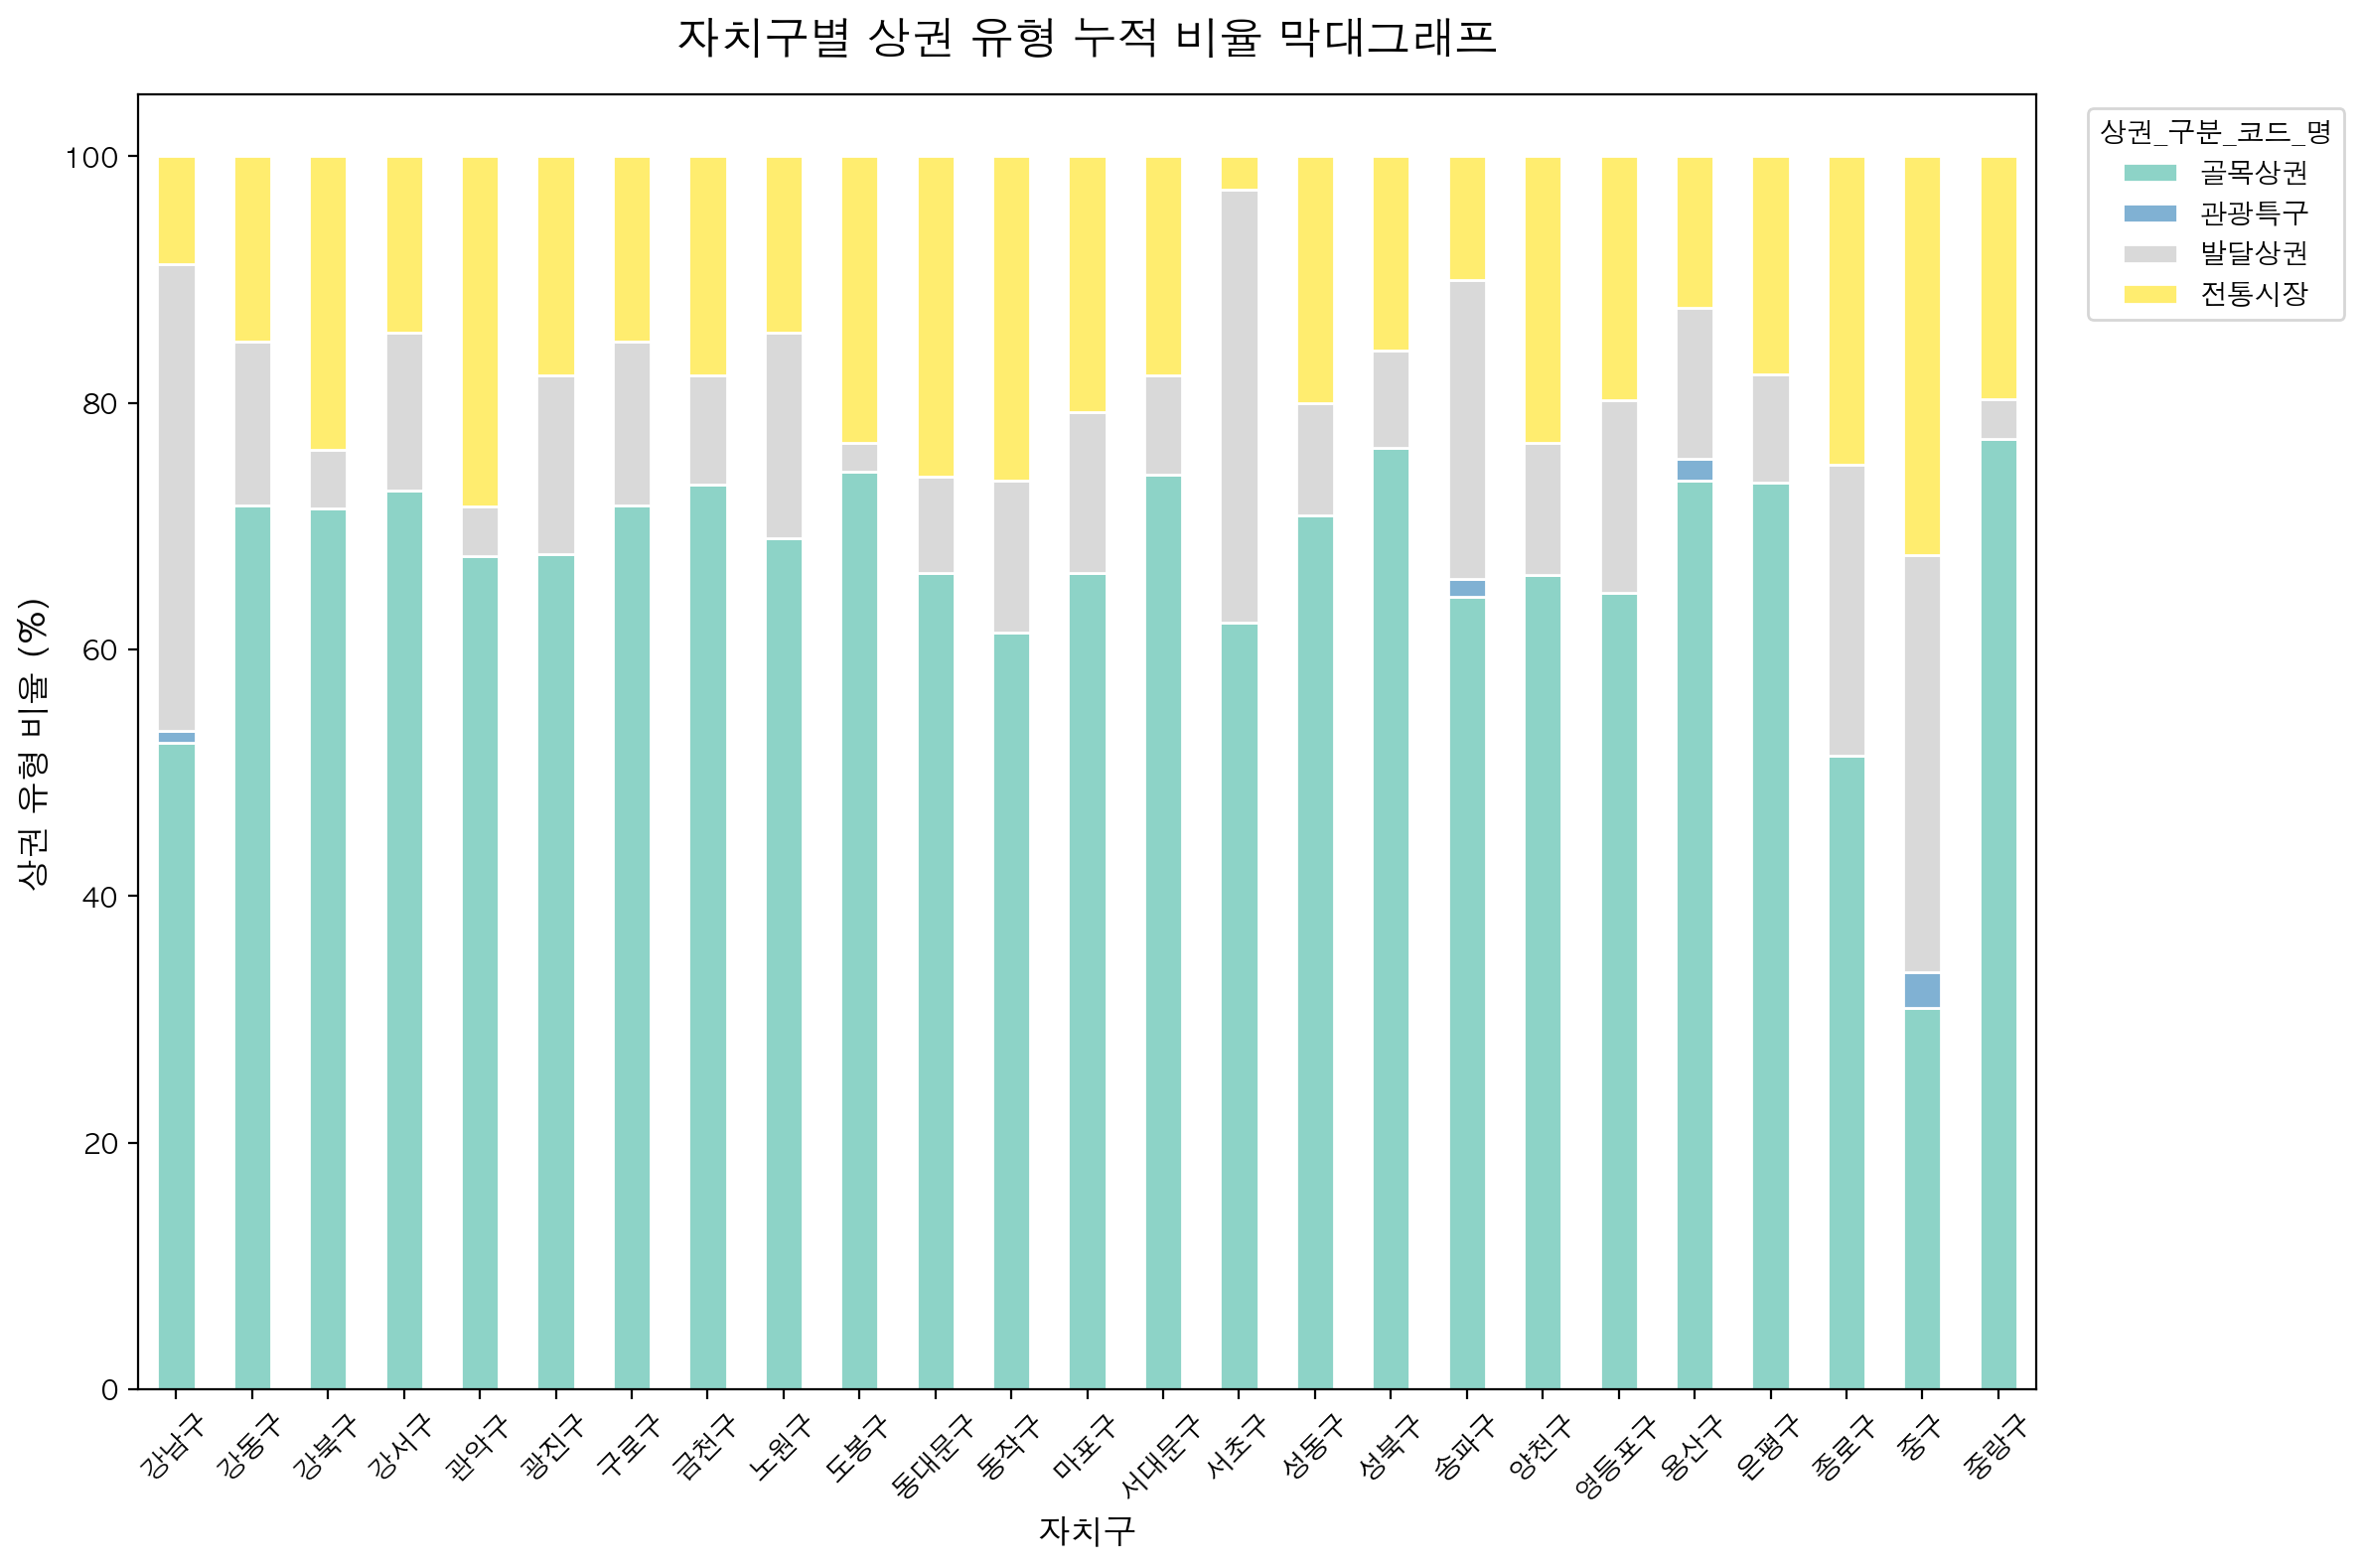

In [19]:
# -------------------------------------------------------------------
# 데이터 전처리
# -------------------------------------------------------------------

# 2. 중복 데이터 처리
# 기준_년분기_코드를 내림차순 정렬하여 가장 최근 분기 데이터가 위로 오게 한 뒤,
# 상권 고유 식별자(상권_코드) 기준으로 중복을 제거하여 최신 데이터만 남깁니다.
df_unique = df_commerce_final.sort_values(by='기준_년분기_코드', ascending=False)
df_unique = df_unique.drop_duplicates(subset=['상권_코드']) # 실제 상권 식별 컬럼명에 맞게 확인

# 3. 자치구별 상권 유형 빈도수 계산 (교차표 생성)
# 알려주신 대로 '자치구' 컬럼을 사용합니다.
cross_tab = pd.crosstab(df_unique['자치구'], df_unique['상권_구분_코드_명'])

# 4. 누적 비율(%)로 변환
# 각 자치구(행)의 총합으로 나누어 비율을 구하고 100을 곱합니다.
cross_tab_prop = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

# -------------------------------------------------------------------
# 시각화 (누적 비율 막대 그래프)
# -------------------------------------------------------------------

# 5. 그래프 그리기
fig, ax = plt.subplots(figsize=(12, 8))
cross_tab_prop.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', edgecolor='white')

# 6. 그래프 꾸미기
plt.title('자치구별 상권 유형 누적 비율 막대그래프', fontsize=16, pad=15)
plt.xlabel('자치구', fontsize=12)
plt.ylabel('상권 유형 비율 (%)', fontsize=12)

# 범례 위치 조정 (그래프 밖으로 빼기)
plt.legend(title='상권_구분_코드_명', bbox_to_anchor=(1.02, 1), loc='upper left')

# X축 라벨 회전 (자치구 이름이 겹치지 않게)
plt.xticks(rotation=45)

# 레이아웃 여백 자동 조정 (범례나 라벨이 잘리지 않게 함)
plt.tight_layout()

# 그래프 출력
plt.show()

In [20]:
df_commerce_final.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '총_상주인구_수', '남성_상주인구_수',
       '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
       '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수', '은행_수', '약국_수',
       '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '공항_수', '철도_역_수', '버스_터미널_수',
       '지하철_역_수', '버스_정거장_수', '상권_변화_지표', '상권_변화_지표_명', '시군구코드', '자치구', '면적',
       'geometry', '총_순수방문객_수', '주간_유동인

In [21]:
# 1. 기본 경로 설정
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

# -----------------------------------------------------------------
# 2. 상권 데이터 3종 경로 설정 및 불러오기 (cp949 인코딩 반영)
# -----------------------------------------------------------------
# 직장인구
DATA_DIR_A = os.path.join(FOLDER_DIR, "서울시 상권분석서비스(직장인구-상권배후지).csv")
df_a = pd.read_csv(DATA_DIR_A, encoding='cp949')

# 상주인구
DATA_DIR_B = os.path.join(FOLDER_DIR, "서울시 상권분석서비스(상주인구-상권배후지).csv")
df_b = pd.read_csv(DATA_DIR_B, encoding='cp949')

# 길단위 유동인구
DATA_DIR_C = os.path.join(FOLDER_DIR, "서울시 상권분석서비스(길단위인구-상권배후지).csv")
df_c = pd.read_csv(DATA_DIR_C, encoding='cp949')

In [22]:
df_a.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권배후지_코드', '상권배후지_코드_명',
       '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수', '연령대_10_직장_인구_수',
       '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수', '연령대_50_직장_인구_수',
       '연령대_60_이상_직장_인구_수', '남성연령대_10_직장_인구_수', '남성연령대_20_직장_인구_수',
       '남성연령대_30_직장_인구_수', '남성연령대_40_직장_인구_수', '남성연령대_50_직장_인구_수',
       '남성연령대_60_이상_직장_인구_수', '여성연령대_10_직장_인구_수', '여성연령대_20_직장_인구_수',
       '여성연령대_30_직장_인구_수', '여성연령대_40_직장_인구_수', '여성연령대_50_직장_인구_수',
       '여성연령대_60_이상_직장_인구_수'],
      dtype='str')

In [23]:
# 1. 남길 공통 컬럼과 총 직장인구수 컬럼 지정
target_columns = [
    '기준_년분기_코드', 
    '상권_구분_코드', 
    '상권_구분_코드_명', 
    '상권배후지_코드', 
    '상권배후지_코드_명', 
    '총_직장_인구_수'
]

# 2. 기존 데이터프레임에 덮어쓰기 (새 변수 생성 X)
df_a = df_a[target_columns]

In [24]:
# 1. 남길 공통 컬럼과 '총_상주인구_수'만 지정 (가구 수 제외)
target_columns_b = [
    '기준_년분기_코드', 
    '상권_구분_코드', 
    '상권_구분_코드_명', 
    '상권배후지_코드', 
    '상권배후지_코드_명', 
    '총_상주인구_수'
]

# 2. 기존 데이터프레임(df_b)에 덮어쓰기
df_b = df_b[target_columns_b]

In [25]:
# 1. 남길 공통 컬럼과 '총_유동인구_수'만 지정
target_columns_c = [
    '기준_년분기_코드', 
    '상권_구분_코드', 
    '상권_구분_코드_명', 
    '상권배후지_코드', 
    '상권배후지_코드_명', 
    '총_유동인구_수'
]

# 2. 기존 데이터프레임(예: df_c)에 덮어쓰기
# (만약 변수명이 df_commerce 라면 df_commerce = df_commerce[target_columns_c] 로 수정해주세요)
df_c = df_c[target_columns_c]

In [26]:
from functools import reduce

# 1. 병합의 기준이 되는 공통 컬럼 리스트
common_cols = [
    '기준_년분기_코드', 
    '상권_구분_코드', 
    '상권_구분_코드_명', 
    '상권배후지_코드', 
    '상권배후지_코드_명'
]


# 합칠 데이터프레임들을 리스트로 묶어줍니다.
dataframes = [df_a, df_b, df_c]

# reduce를 사용해 순차적으로 모두 병합
df_final = reduce(lambda left, right: pd.merge(left, right, on=common_cols, how='inner'), dataframes).fillna(0)

In [27]:
# 1. 계산을 위해 숫자형으로 안전하게 변환 (결측치는 0으로)
numeric_cols = ['총_직장_인구_수', '총_상주인구_수', '총_유동인구_수']
for col in numeric_cols:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)

# 2. 총 유동인구수에서 상주인구와 직장인구를 뺀 '순수_유동인구_수' 계산
# (단, 빼기 결과가 음수가 나오면 0으로 처리하도록 clip(lower=0) 적용)
df_final['순수_유동인구_수'] = (
    df_final['총_유동인구_수'] - df_final['총_상주인구_수'] - df_final['총_직장_인구_수']
).clip(lower=0)

# 3. 3가지 지표(직장, 상주, 순수 유동)의 전체 상권 대비 백분위 랭킹(0~1) 계산
df_final['직장_랭킹'] = df_final['총_직장_인구_수'].rank(pct=True)
df_final['상주_랭킹'] = df_final['총_상주인구_수'].rank(pct=True)
df_final['유동_랭킹'] = df_final['순수_유동인구_수'].rank(pct=True) # 총 유동인구가 아닌 순수 유동인구로 랭킹 계산

# 4. 세 가지 랭킹 중 가장 수치가 높은 항목을 추출하기 위해 랭킹 데이터만 분리
rank_df = df_final[['직장_랭킹', '상주_랭킹', '유동_랭킹']]

# 각 랭킹 컬럼명에 따른 최종 상권 유형 라벨링
type_mapping = {
    '직장_랭킹': '오피스/직장형',
    '상주_랭킹': '주거지/동네형',
    '유동_랭킹': '발달/번화가형 (순수 유동인구 중심)'
}

# 행별로 랭킹이 가장 높은(idxmax) 컬럼을 찾아서 매핑 딕셔너리로 유형 부여
df_final['상권배후지_유형'] = rank_df.idxmax(axis=1).map(type_mapping)

# 5. 불필요한 랭킹 컬럼 삭제 및 결과 확인
df_result = df_final.drop(columns=['직장_랭킹', '상주_랭킹', '유동_랭킹'])

df_result.head(10)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권배후지_코드,상권배후지_코드_명,총_직장_인구_수,총_상주인구_수,총_유동인구_수,순수_유동인구_수,상권배후지_유형
0,20253,A,골목상권,3111090,강일동주민센터,143,4677,548169,543349,주거지/동네형
1,20253,A,골목상권,3111089,상일여고(상일초등학교),1291,14226,1483855,1468338,주거지/동네형
2,20253,A,골목상권,3111088,고덕동성당,828,10602,980971,969541,주거지/동네형
3,20253,A,골목상권,3111087,고덕중학교(고덕2동주민센터),348,6577,836558,829633,주거지/동네형
4,20253,A,골목상권,3111086,한영중고,523,8239,726995,718233,주거지/동네형
5,20253,A,골목상권,3111085,묘곡초등학교(고덕아이파크아파트),845,14338,1502465,1487282,주거지/동네형
6,20253,A,골목상권,3111084,길동신동아아파트,731,8631,3694704,3685342,발달/번화가형 (순수 유동인구 중심)
7,20253,A,골목상권,3111083,GS강동자이아파트,2061,19729,6190541,6168751,발달/번화가형 (순수 유동인구 중심)
8,20253,A,골목상권,3111082,중앙보훈병원,327,7312,1489925,1482286,주거지/동네형
9,20253,A,골목상권,3111081,둔촌푸르지오아파트,1370,9804,2124033,2112859,오피스/직장형


In [28]:
# 1. 저장할 폴더 및 파일 경로 설정
folder_path = '병합완료'
file_path = f'{folder_path}/상권배후지_유동인구.csv'

df_result.to_csv(file_path, index=False, encoding='utf-8-sig')

In [29]:
folder_path = '병합완료'
file_path = f'{folder_path}/상권_유동인구_직장인구_상주인구_상권변화지표_추가.csv'

df_commerce_final.to_csv(file_path, index=False, encoding='utf-8-sig')

In [30]:
df_commerce_final.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '총_상주인구_수', '남성_상주인구_수',
       '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
       '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수', '은행_수', '약국_수',
       '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '공항_수', '철도_역_수', '버스_터미널_수',
       '지하철_역_수', '버스_정거장_수', '상권_변화_지표', '상권_변화_지표_명', '시군구코드', '자치구', '면적',
       'geometry', '총_순수방문객_수', '주간_유동인

In [31]:
df_commerce_final.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '총_상주인구_수', '남성_상주인구_수',
       '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
       '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수', '은행_수', '약국_수',
       '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '공항_수', '철도_역_수', '버스_터미널_수',
       '지하철_역_수', '버스_정거장_수', '상권_변화_지표', '상권_변화_지표_명', '시군구코드', '자치구', '면적',
       'geometry', '총_순수방문객_수', '주간_유동인

In [32]:
# 1. 현재 실행 중인 파이썬 스크립트(또는 주피터 노트북)의 위치를 가져옵니다.
current_dir = os.getcwd()

# 2. os.path.join을 사용하여 운영체제에 맞는 파일 경로를 동적으로 생성합니다.
# (Mac의 '/'와 Windows의 '\' 차이를 자동으로 처리해 줍니다.)
file_path = os.path.join(current_dir, '병합완료', '서울시 상권분석서비스(영역-상권)', '서울시 상권분석서비스(영역-상권).shp')

# 3. 설정한 변수명(df_h)으로 데이터를 불러옵니다.
df_h = gpd.read_file(file_path)

# df_h의 'TRDAR_CD'와 'TRDAR_CD_N' 컬럼명을 각각 '상권_코드', '상권_코드_명'으로 변경합니다.
df_h.rename(columns={
    'TRDAR_CD': '상권_코드', 
    'TRDAR_CD_N': '상권_코드_명'
}, inplace=True)

In [33]:
# 1. '상권_코드' 컬럼의 데이터 타입을 문자열(str)로 통일합니다.
df_commerce_final['상권_코드'] = df_commerce_final['상권_코드'].astype(str)
df_h['상권_코드'] = df_h['상권_코드'].astype(str)

# 2. 가져올 컬럼 지정
columns_to_merge = ['상권_코드', '상권_코드_명', 'ADSTRD_CD', 'ADSTRD_CD_']

# 3. 데이터 병합 다시 실행
df_commerce_final = pd.merge(
    df_commerce_final,
    df_h[columns_to_merge],
    on=['상권_코드', '상권_코드_명'],  
    how='left'  
)

In [41]:
# 'ADSTRD_CD'와 'ADSTRD_CD_' 컬럼명을 각각 '행정구_코드', '행정구'로 변경합니다.
df_commerce_final.rename(columns={
    'ADSTRD_CD': '행정동_코드', 
    'ADSTRD_CD_': '행정동'
}, inplace=True)

In [43]:
df_commerce_final.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '총_상주인구_수', '남성_상주인구_수',
       '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
       '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수', '은행_수', '약국_수',
       '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '공항_수', '철도_역_수', '버스_터미널_수',
       '지하철_역_수', '버스_정거장_수', '상권_변화_지표', '상권_변화_지표_명', '시군구코드', '자치구', '면적',
       'geometry', '총_순수방문객_수', '주간_유동인

## 방문자수

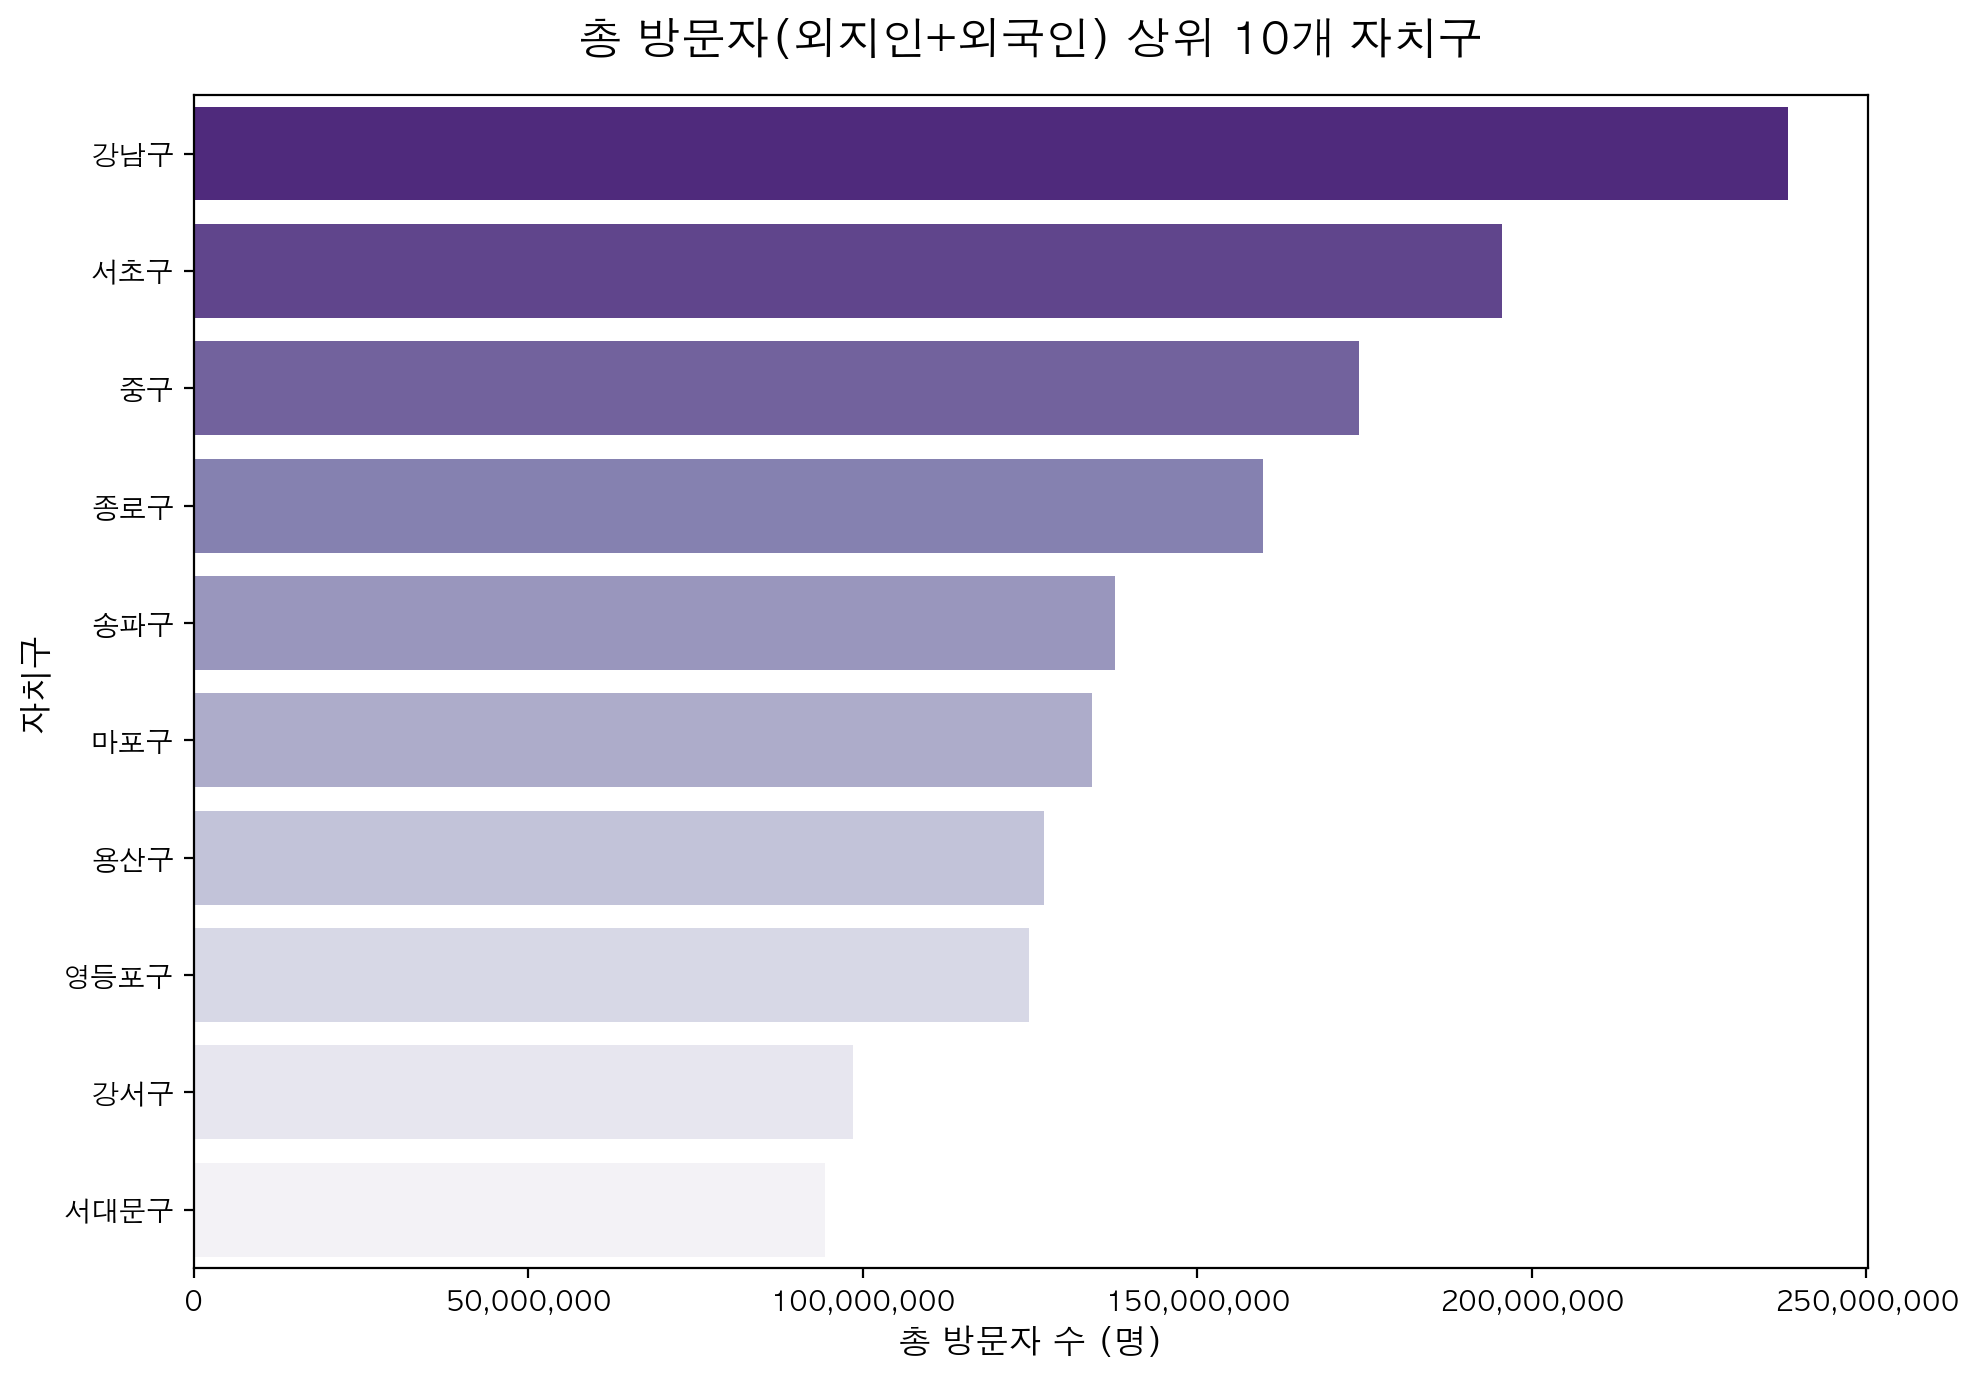

In [22]:
# 데이터프레임의 실제 컬럼명('외지인방문자수', '외국인방문자수')에 맞게 이름은 살짝 수정해 주세요.
native_foreigner['게스트수요'] = native_foreigner['외지인방문자수'] + native_foreigner['외국인방문자수']


# ==========================================
# 주제 1: 게스트 수요 규모 Top 10 시각화
# ==========================================
# 자치구별 게스트 수요 합계 계산
guest_volume = native_foreigner.groupby('자치구')['게스트수요'].sum().reset_index()

# 게스트 수요가 가장 많은 상위 10개 자치구 추출
top10_volume = guest_volume.sort_values(by='게스트수요', ascending=False).head(10)

# 시각화 (도화지 생성)
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

sns.barplot(
    data=top10_volume,
    x='게스트수요',
    y='자치구',
    ax=ax,
    palette='Purples_r'
)

# 그래프 제목 및 축 이름 설정
ax.set_title('총 방문자(외지인+외국인) 상위 10개 자치구', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('총 방문자 수 (명)', fontsize=12)
ax.set_ylabel('자치구', fontsize=12)

# X축 숫자 단위 포맷팅 (예: 1000000 -> 1,000,000)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x):,}'))

plt.tight_layout()
plt.show()

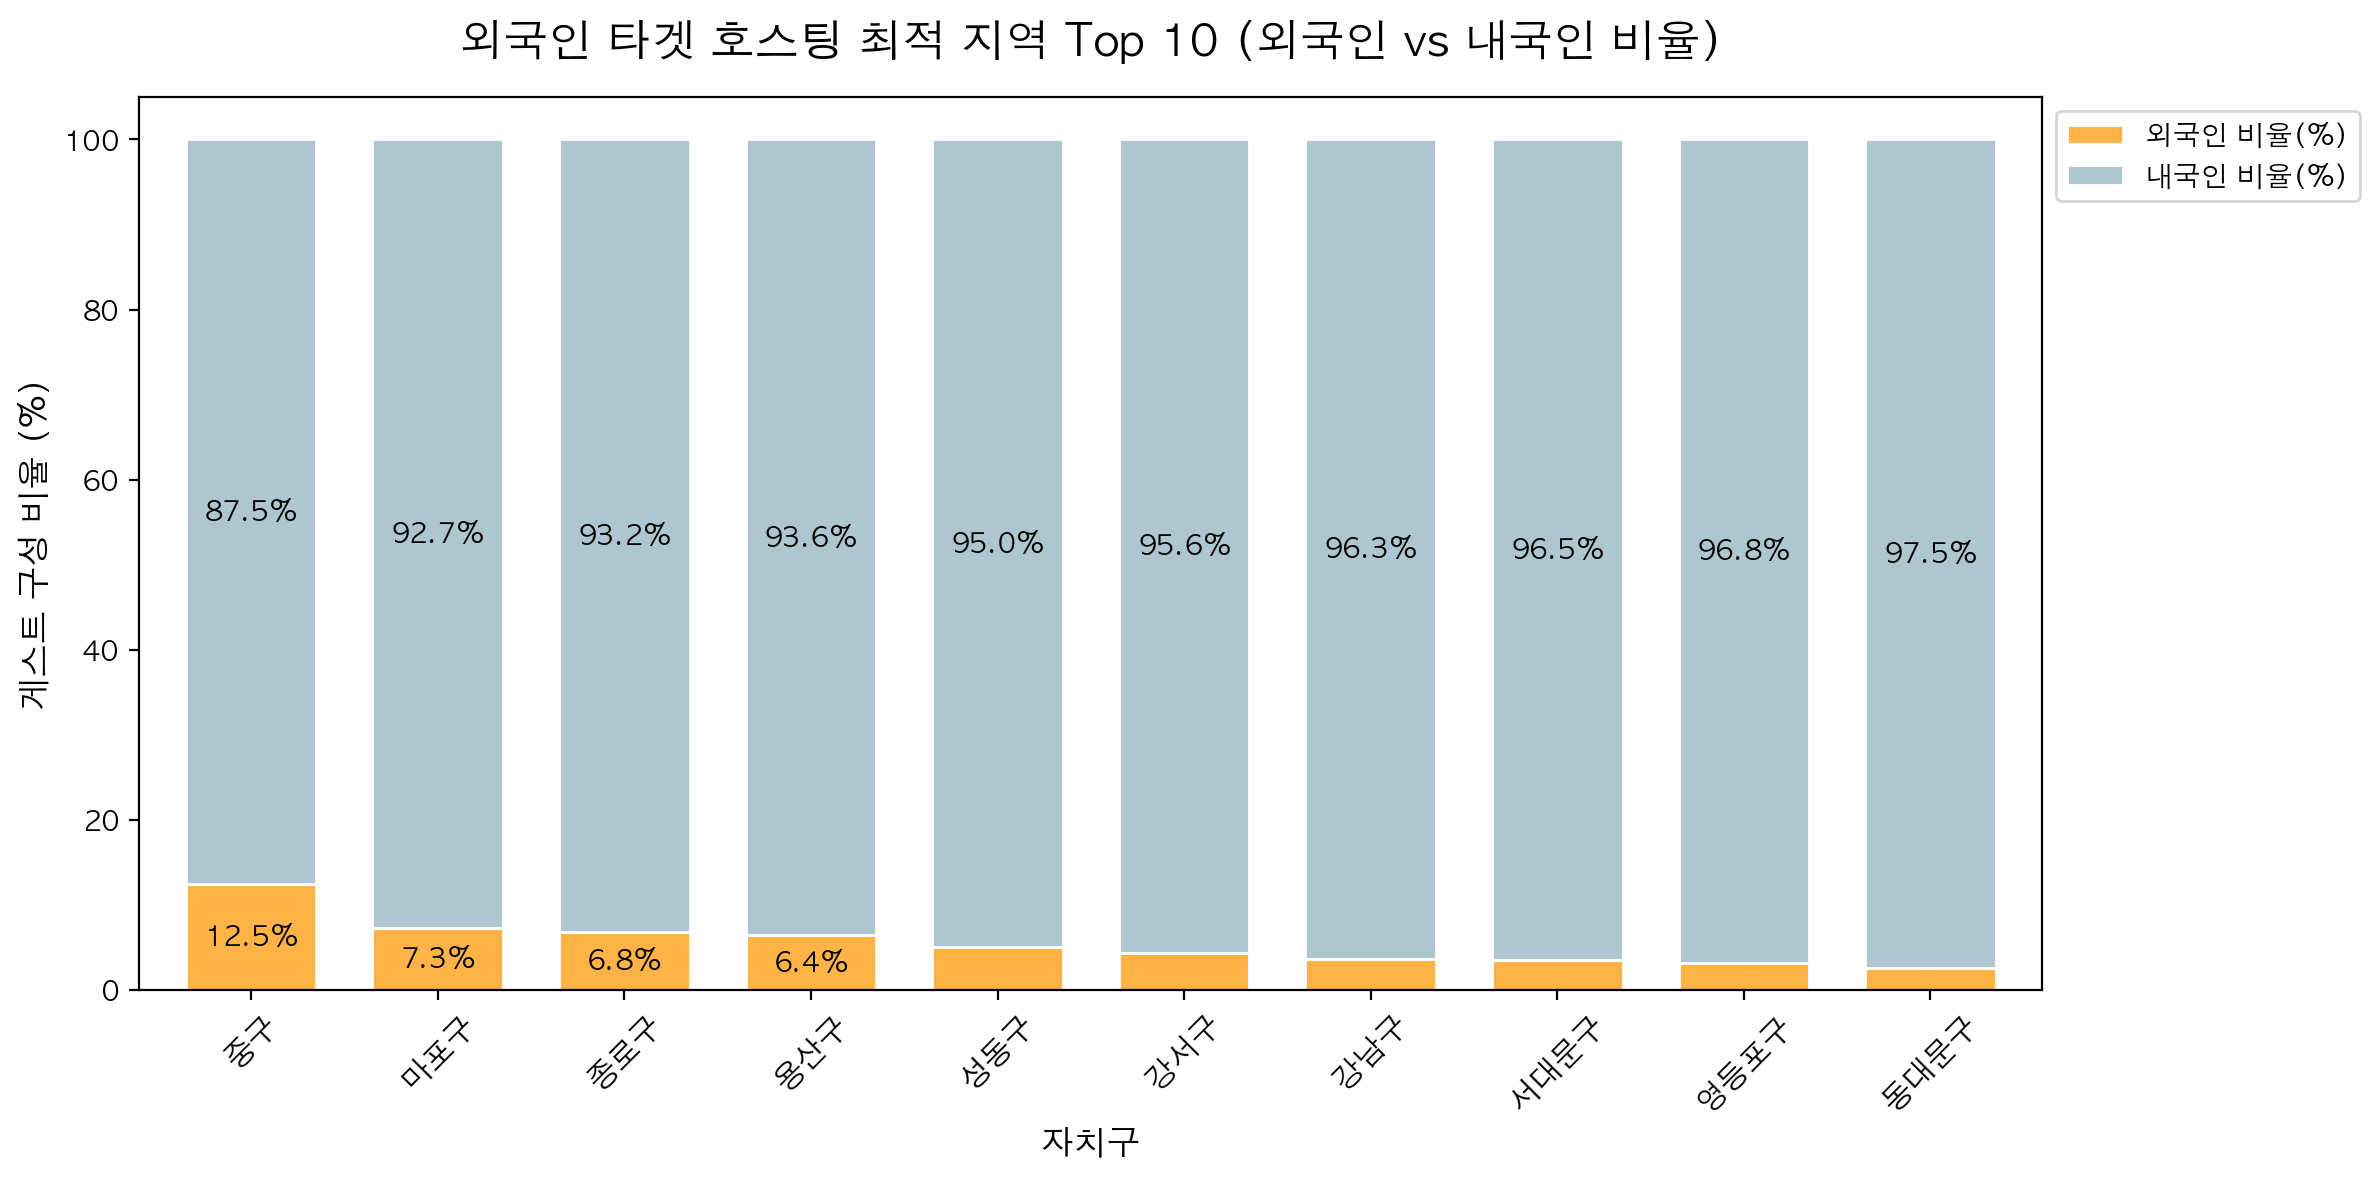

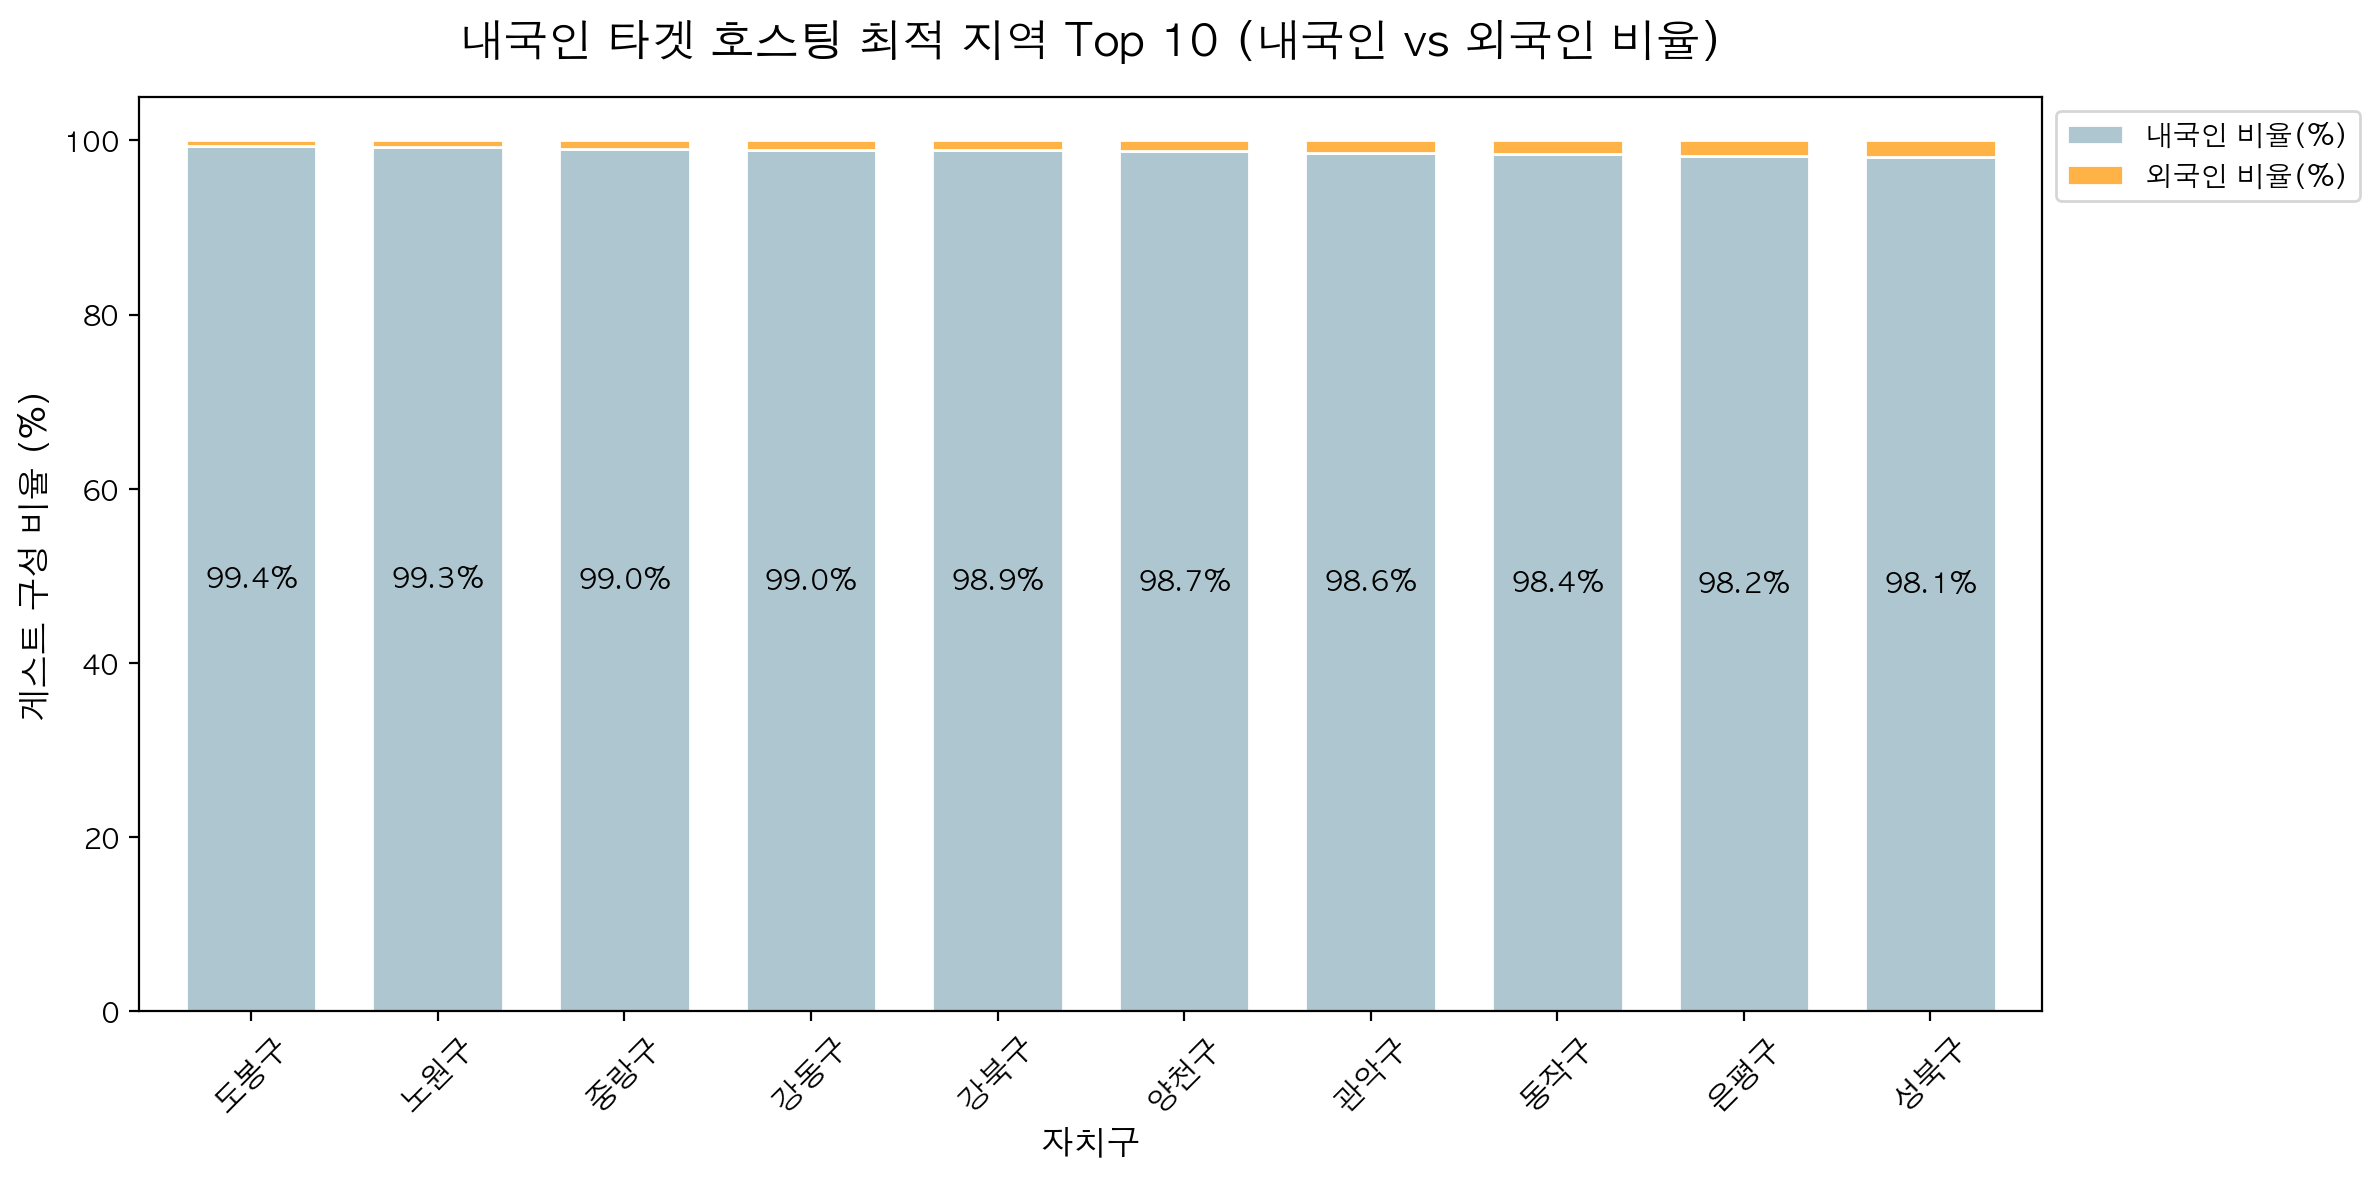

In [23]:
# ==========================================
# 주제 3: 타겟 고객층 성향 (외국인 타겟 비중이 높은 자치구 Top 10)
# ==========================================

# 1. 외국인 및 내국인 비중 계산
native_foreigner['외국인타겟비중(%)'] = (native_foreigner['외국인방문자수'] / native_foreigner['게스트수요']) * 100
native_foreigner['내국인타겟비중(%)'] = 100 - native_foreigner['외국인타겟비중(%)']

# 2. 자치구별로 외국인/내국인 비중 평균 계산
target_mean = native_foreigner.groupby('자치구')[['외국인타겟비중(%)', '내국인타겟비중(%)']].mean().reset_index()

# 3. 외국인 비중이 '높은' 순으로 정렬하여 상위 10개 추출
top10_foreign_target = target_mean.sort_values(by='외국인타겟비중(%)', ascending=False).head(10)

# 4. 시각화를 위해 인덱스를 '자치구'로 설정
top10_foreign_target.set_index('자치구', inplace=True)

# 시각화 (Stacked Bar Chart)
# 외국인(#FFB347)을 아래에, 내국인(#AEC6CF)을 위에 쌓음
ax = top10_foreign_target[['외국인타겟비중(%)', '내국인타겟비중(%)']].plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 6), 
    color=['#FFB347', '#AEC6CF'], 
    width=0.7,
    edgecolor='white'
)

plt.title('외국인 타겟 호스팅 최적 지역 Top 10 (외국인 vs 내국인 비율)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('게스트 구성 비율 (%)', fontsize=12)
plt.xlabel('자치구', fontsize=12)
plt.xticks(rotation=45, fontsize=11)
plt.legend(['외국인 비율(%)', '내국인 비율(%)'], loc='upper left', bbox_to_anchor=(1, 1))

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# ==========================================
# 주제 4: 내국인 타겟 비중이 높은 자치구 Top 10
# ==========================================

# 1. 자치구별로 내/외국인 비중 평균 계산 (기존 계산된 데이터 활용)
target_mean_native = native_foreigner.groupby('자치구')[['내국인타겟비중(%)', '외국인타겟비중(%)']].mean().reset_index()

# 2. 내국인 비중이 '높은' 순으로 정렬하여 상위 10개 추출
top10_native_target = target_mean_native.sort_values(by='내국인타겟비중(%)', ascending=False).head(10)

# 3. 시각화를 위해 인덱스를 '자치구'로 설정
top10_native_target.set_index('자치구', inplace=True)

# 시각화 (Stacked Bar Chart)
# 내국인(#AEC6CF)을 아래에, 외국인(#FFB347)을 위에 쌓음
# 리스트 순서를 ['내국인', '외국인']으로 잡았으므로 색상도 [#AEC6CF, #FFB347] 순서로 적용
ax = top10_native_target[['내국인타겟비중(%)', '외국인타겟비중(%)']].plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 6), 
    color=['#AEC6CF', '#FFB347'], # 👈 색상 순서를 내국인(파랑), 외국인(주황)으로 매칭
    width=0.7,
    edgecolor='white'
)

plt.title('내국인 타겟 호스팅 최적 지역 Top 10 (내국인 vs 외국인 비율)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('게스트 구성 비율 (%)', fontsize=12)
plt.xlabel('자치구', fontsize=12)
plt.xticks(rotation=45, fontsize=11)
plt.legend(['내국인 비율(%)', '외국인 비율(%)'], loc='upper left', bbox_to_anchor=(1, 1))

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
display(df_search_rank.head(5))
display(df_keyword.head(5))


,광역시/도,자치구,관광지명,중분류 카테고리,소분류 카테고리,검색건수,월,연도
순위,,,,,,,,
1,서울특별시,강서구,김포국제공항국내선,기타관광,교통시설,118704,1,2025
2,서울특별시,용산구,서울역,기타관광,교통시설,70332,1,2025
3,서울특별시,강남구,수서역,기타관광,교통시설,65673,1,2025
4,서울특별시,서초구,서울고속버스터미널경부영동선,기타관광,교통시설,39502,1,2025
5,서울특별시,용산구,용산역,기타관광,교통시설,30740,1,2025


,연도,월,키워드,언급량,월별순위
기준년월,,,,,
202501,2025,1,K-Culture 관련 거리,881,6
202501,2025,1,K-공연관람,39519,1
202501,2025,1,K-굿즈,128,8
202501,2025,1,K-댄스 배우기,4135,5
202501,2025,1,K-덕질,8211,2


In [25]:
display(gdf_landmark.head(5))
display(gdf_120_place.head(5))
display(gdf_park.head(5))
display(gdf_festival.head(5))

,상호명,자치구,신주소,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,1898 명동성당,중구,"서울 중구 명동길 74 (명동2가, 명동성당)",126.99,37.56,954674.47,1951714.49,POINT (954674.47 1951714.489)
1,SeMA 벙커,영등포구,서울 영등포구 의사당대로 지하 101 (여의도역),126.92,37.52,949099.22,1947112.58,POINT (949099.223 1947112.583)
2,삼우치킨센타,영등포구,서울 영등포구 시흥대로 671 (대림동),126.91,37.49,947680.93,1943763.69,POINT (947680.935 1943763.687)
3,63스퀘어,영등포구,"서울 영등포구 63로 50 (여의도동, 63한화생명빌딩)",126.94,37.52,950506.32,1946855.25,POINT (950506.325 1946855.253)
4,PKM갤러리,종로구,"서울 종로구 삼청로7길 40 (삼청동, 피케이엠 갤러리)",126.98,37.58,954095.86,1953982.77,POINT (954095.863 1953982.772)


,CATEGORY,AREA_CD,AREA_NM,geometry
0,관광특구,POI001,강남 MICE 관광특구,"POLYGON ((961139.825 1946159.605, 961150.455 1..."
1,관광특구,POI002,동대문 관광특구,"POLYGON ((957399.19 1952346.004, 957410.244 19..."
2,관광특구,POI003,명동 관광특구,"POLYGON ((953721.466 1951385.771, 953722.391 1..."
3,관광특구,POI004,이태원 관광특구,"POLYGON ((955049.19 1948009.97, 955045.709 194..."
4,관광특구,POI005,잠실 관광특구,"POLYGON ((964036.702 1945770.373, 964006.031 1..."


,공원명,자치구,공원주소,X좌표(GRS80TM),Y좌표(GRS80TM),X좌표(WGS84),Y좌표(WGS84),geometry
0,남산공원,중구,서울특별시 중구 삼일대로 231(예장동),954984.40,1950211.05,126.99,37.55,POINT (954984.395 1950211.045)
1,길동생태공원,강동구,서울특별시 강동구 천호대로 1291(길동생태공원),969502.30,1949063.68,127.15,37.54,POINT (969502.296 1949063.682)
2,서울대공원,과천시,경기도 과천시 대공원광장로 102,957517.47,1936474.66,127.02,37.43,POINT (957517.472 1936474.659)
3,서울숲,성동구,서울특별시 성동구 뚝섬로 273 (성수동1가),959522.67,1949403.45,127.04,37.54,POINT (959522.672 1949403.454)
4,월드컵공원,마포구,서울특별시 마포구 하늘공원로 84(월드컵공원),945153.88,1952673.87,126.88,37.57,POINT (945153.878 1952673.872)


,분류,자치구,공연/행사명,날짜,장소,기관명,시작일,종료일,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,기타,광진구,[미래한강본부] 2025 한강공원 눈썰매장 개장,2025-12-31~2026-02-28,"뚝섬, 잠원, 여의도",미래한강본부,2025.12.31 0:00,2026.2.28 0:00,127.07,37.53,962358.56,1947869.36,POINT (962358.562 1947869.361)
1,연극,종로구,연극 [잔류자들],2025-12-31~2026-01-04,선돌극장,기타,2025.12.31 0:00,2026.1.4 0:00,127.00,37.59,955835.30,1954275.21,POINT (955835.304 1954275.214)
2,축제-시민화합,종로구,2025 제야의 종 타종행사,2025-12-31~2026-01-01,보신각 일대,서울시청,2025.12.31 0:00,2026.1.1 0:00,126.98,37.57,954404.56,1952391.81,POINT (954404.561 1952391.812)
3,축제-시민화합,중구,서울라이트 DDP : 새해맞이 카운트다운,2025-12-31~2026-01-01,DDP 전면(어울림광장 및 디자인거리 관람가능),동대문디자인플라자(DDP),2025.12.31 0:00,2026.1.1 0:00,127.01,37.57,956708.21,1952112.08,POINT (956708.207 1952112.081)
4,축제-문화/예술,서대문구,[서대문구] 2026 신촌카운트다운콘서트,2025-12-31~2026-01-01,신촌 스타광장,서대문구청,2025.12.31 0:00,2026.1.1 0:00,126.94,37.56,950234.97,1950970.15,POINT (950234.969 1950970.152)


In [26]:
df_search_rank.columns 

Index(['광역시/도', '자치구', '관광지명', '중분류 카테고리', '소분류 카테고리', '검색건수', '월', '연도'], dtype='str')

In [27]:
gdf_landmark.columns

Index(['상호명', '자치구', '신주소', 'X좌표(WGS84)', 'Y좌표(WGS84)', 'X좌표(GRS80TM)',
       'Y좌표(GRS80TM)', 'geometry'],
      dtype='str')

In [28]:
gdf_120_place.columns

Index(['CATEGORY', 'AREA_CD', 'AREA_NM', 'geometry'], dtype='str')

In [29]:
gdf_120_place['CATEGORY'].unique()

<StringArray>
['관광특구', '고궁·문화유산', '인구밀집지역', '발달상권', '공원']
Length: 5, dtype: str

# 카테고리 검색

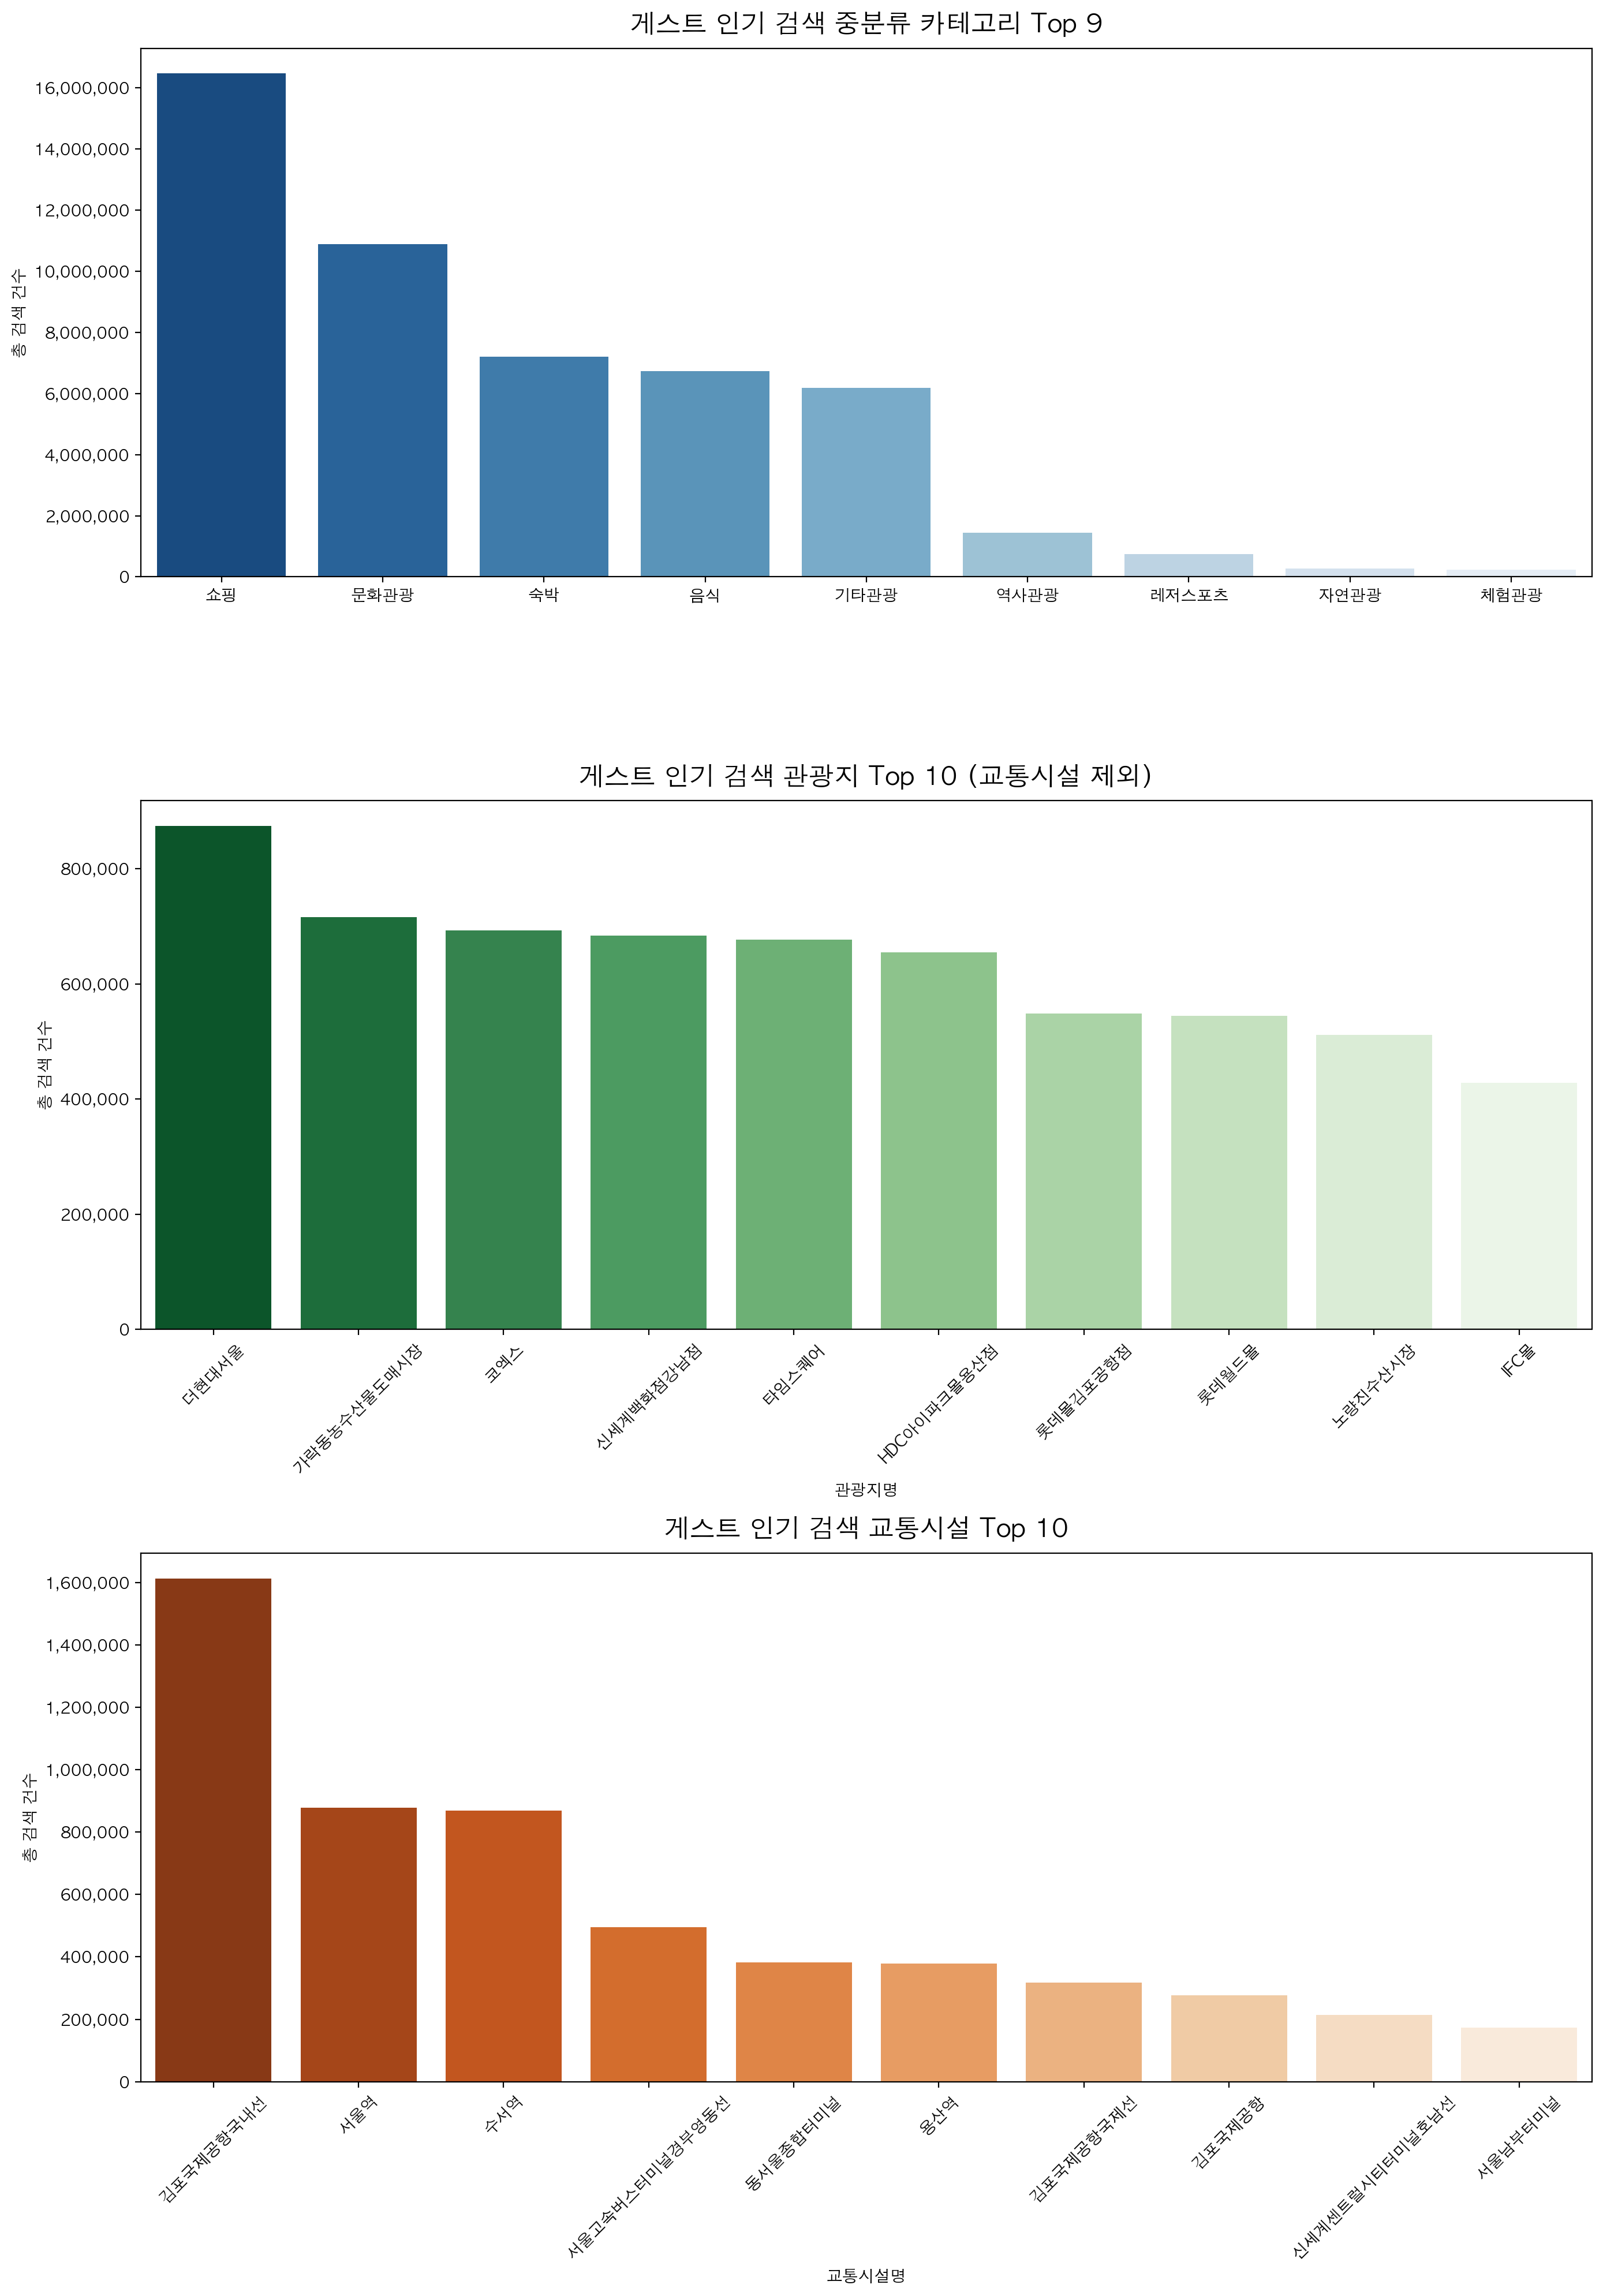

In [30]:
# [1] 인기 검색 '중분류 카테고리' (전체 데이터)
top_mid_categories = df_search_rank.groupby('중분류 카테고리')['검색건수'].sum().reset_index()
top_mid_categories = top_mid_categories.sort_values(by='검색건수', ascending=False).head(10)

# [2] 인기 검색 개별 '관광지명' (교통시설 제외)
df_filtered_places = df_search_rank[df_search_rank['소분류 카테고리'] != '교통시설']
top_places = df_filtered_places.groupby('관광지명')['검색건수'].sum().reset_index()
top_places = top_places.sort_values(by='검색건수', ascending=False).head(10)

# [3] 인기 검색 '교통시설' (교통시설만 포함)
df_transport = df_search_rank[df_search_rank['소분류 카테고리'] == '교통시설']
top_transport = df_transport.groupby('관광지명')['검색건수'].sum().reset_index()
top_transport = top_transport.sort_values(by='검색건수', ascending=False).head(10)
# 축 이름을 '교통시설명'으로 변경
top_transport.rename(columns={'관광지명': '교통시설명'}, inplace=True)

# ==============================================================
# 시각화: 3행 1열로 세로 배치
fig, axes = plt.subplots(3, 1, figsize=(14, 20))

# 첫 번째 그래프: 중분류 카테고리
sns.barplot(data=top_mid_categories, x='중분류 카테고리', y='검색건수', ax=axes[0], palette='Blues_r')
axes[0].set_title('게스트 인기 검색 중분류 카테고리 Top 9', fontsize=16, pad=10)
axes[0].set_ylabel('총 검색 건수')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# 두 번째 그래프: 개별 관광지명 (교통시설 제외)
sns.barplot(data=top_places, x='관광지명', y='검색건수', ax=axes[1], palette='Greens_r')
axes[1].set_title('게스트 인기 검색 관광지 Top 10 (교통시설 제외)', fontsize=16, pad=10)
axes[1].set_ylabel('총 검색 건수')
axes[1].set_xlabel('관광지명')
axes[1].tick_params(axis='x', rotation=45)

# 세 번째 그래프: 교통시설명
sns.barplot(data=top_transport, x='교통시설명', y='검색건수', ax=axes[2], palette='Oranges_r')
axes[2].set_title('게스트 인기 검색 교통시설 Top 10', fontsize=16, pad=10)
axes[2].set_ylabel('총 검색 건수')
axes[2].set_xlabel('교통시설명')
axes[2].tick_params(axis='x', rotation=45)

# Y축 지수표현 방지 및 천 단위 콤마 포맷 적용
import matplotlib.ticker as ticker
for ax in axes:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

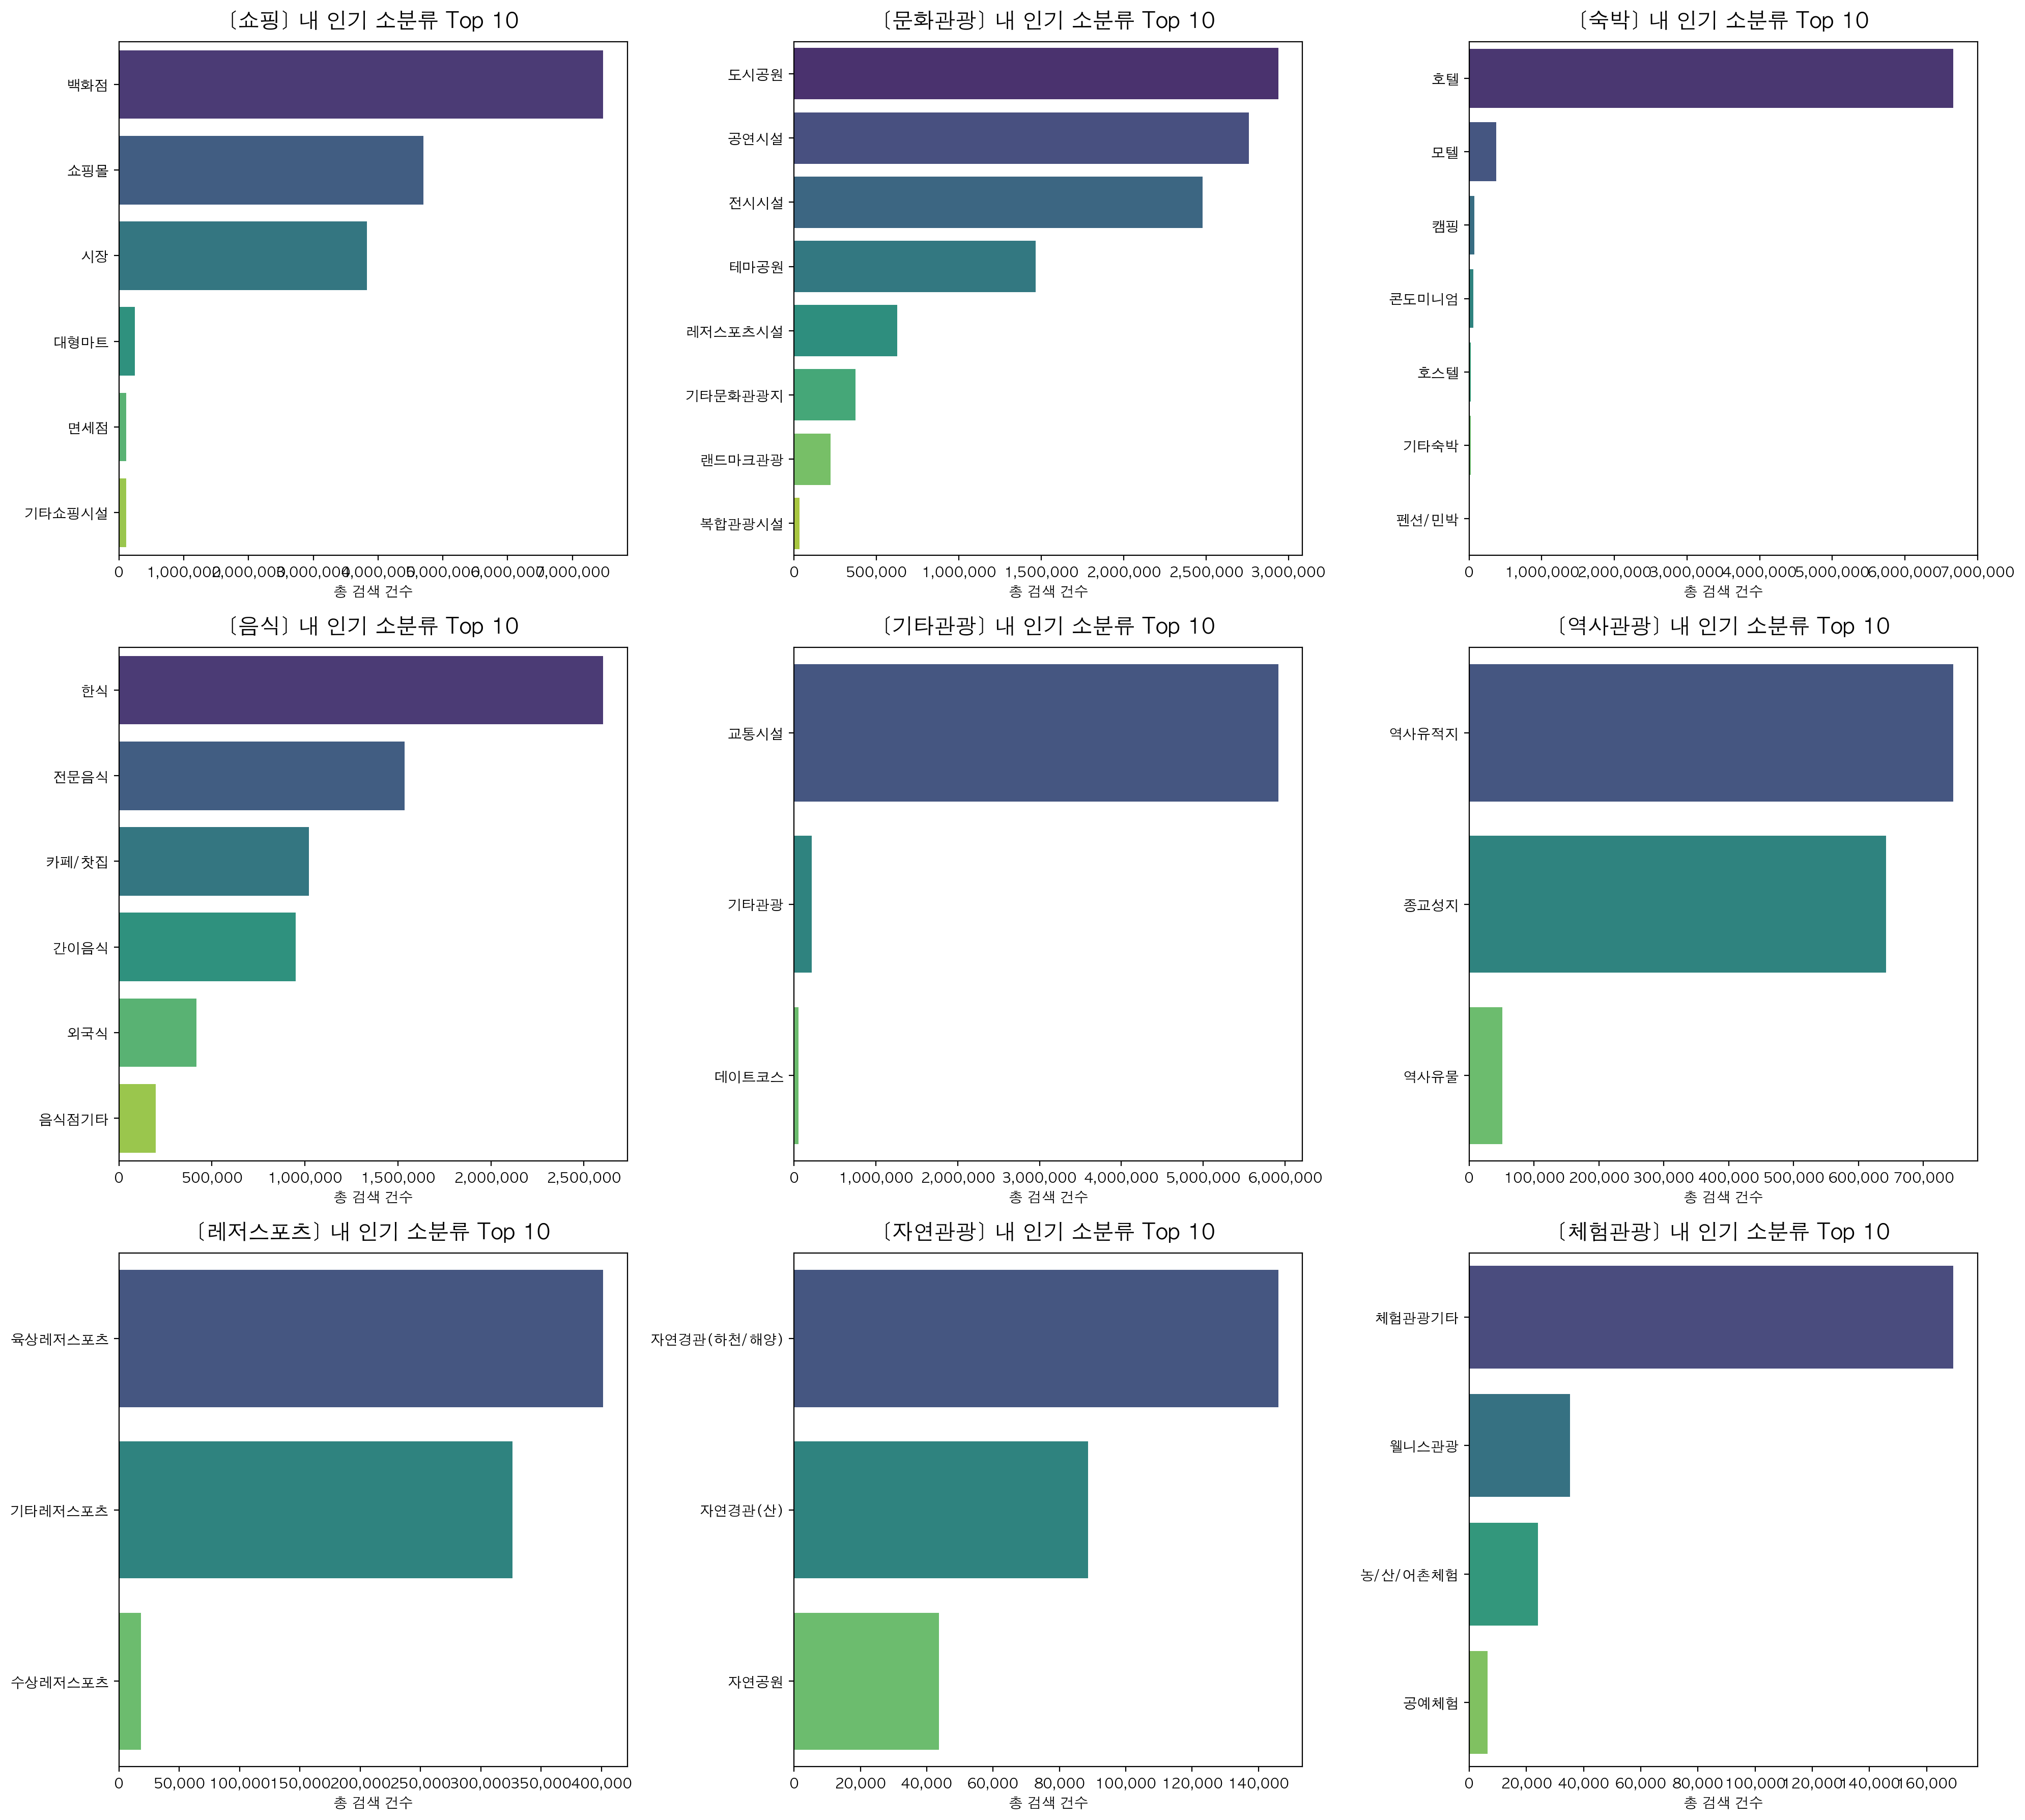

In [31]:
# 1. 인기 중분류 카테고리 추출 (상위 9개)
top9_mid_list = df_search_rank.groupby('중분류 카테고리')['검색건수'].sum().sort_values(ascending=False).head(9).index

# 2. 3행 3열의 서브플롯 생성 (총 9개 그래프에 딱 맞춤)
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

# 3. 각 중분류 카테고리별로 반복하며 그래프 그리기
for i, mid_cat in enumerate(top9_mid_list):
    # 해당 중분류 데이터만 필터링
    df_subset = df_search_rank[df_search_rank['중분류 카테고리'] == mid_cat]
    
    # 소분류 카테고리별 검색건수 합산 및 Top 10 추출
    top_sub = df_subset.groupby('소분류 카테고리')['검색건수'].sum().reset_index()
    top_sub = top_sub.sort_values(by='검색건수', ascending=False).head(10)
    
    # 막대 그래프 그리기
    sns.barplot(data=top_sub, x='검색건수', y='소분류 카테고리', ax=axes[i], palette='viridis')
    
    # 그래프 디자인 설정
    axes[i].set_title(f"[{mid_cat}] 내 인기 소분류 Top 10", fontsize=15, pad=10)
    axes[i].set_xlabel('총 검색 건수')
    axes[i].set_ylabel('')
    
    # X축 천 단위 콤마 포맷 적용
    axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

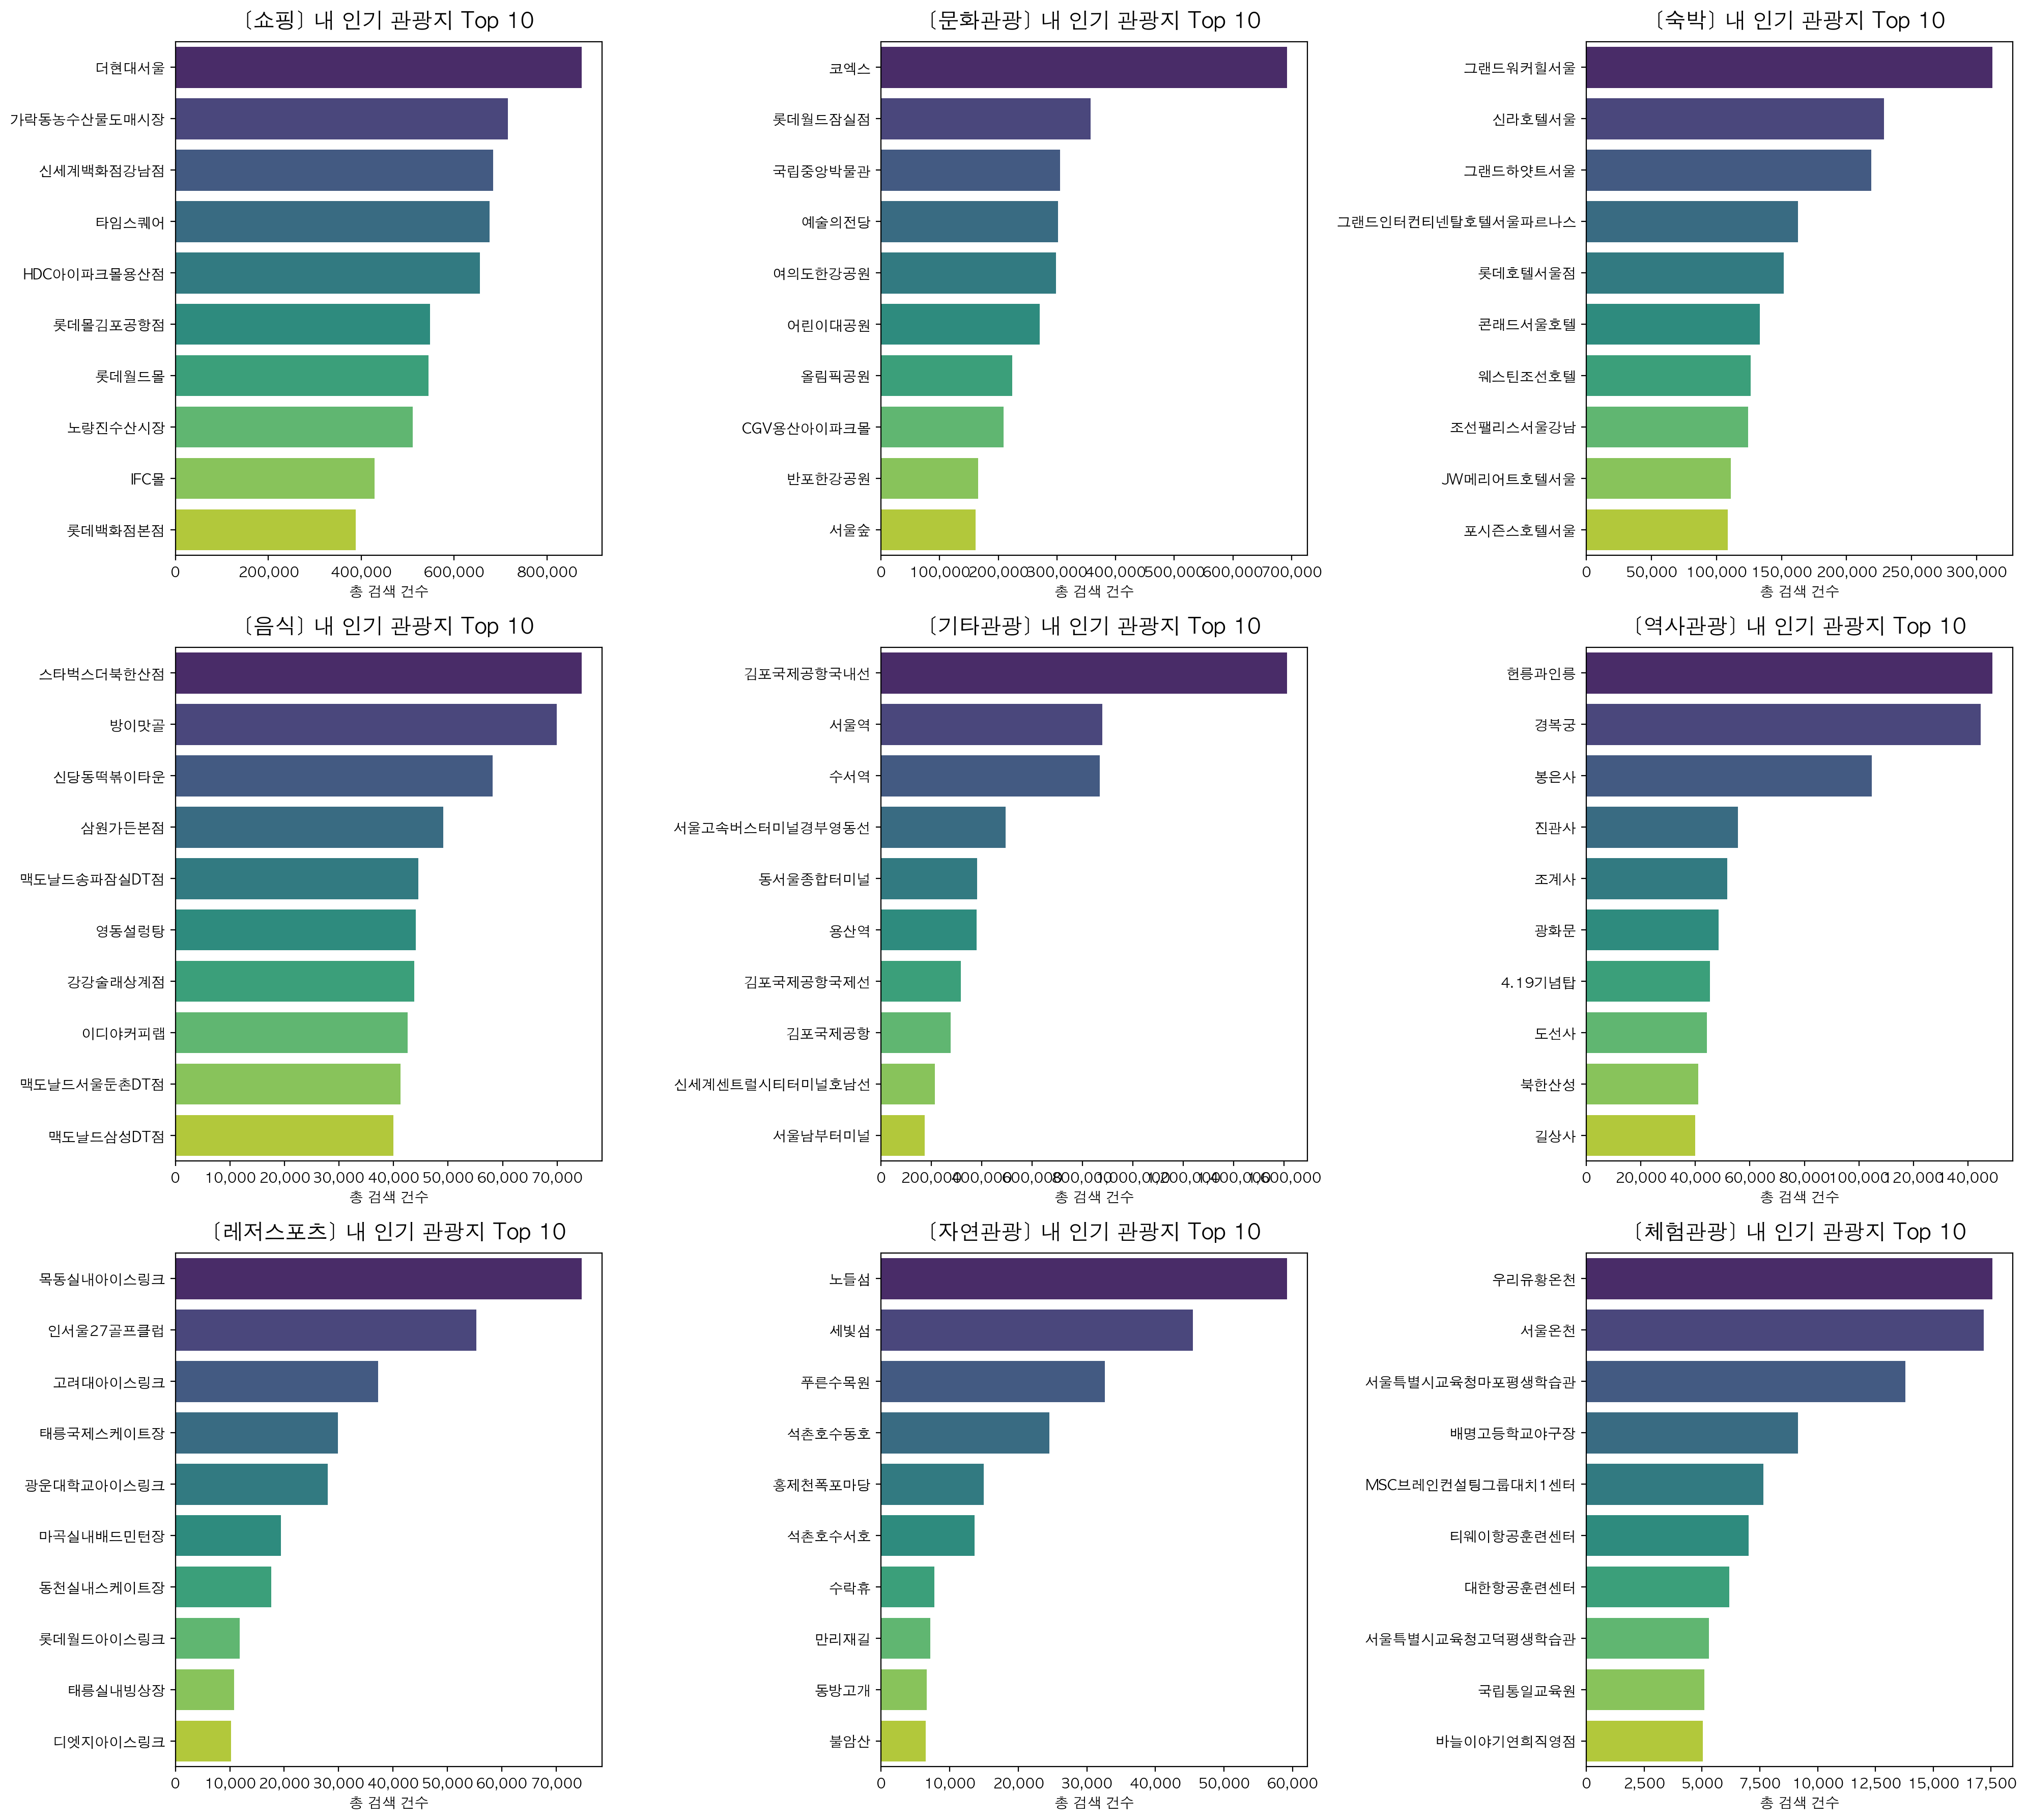

In [32]:
# 1. 인기 중분류 카테고리 추출 (상위 9개)
top9_mid_list = df_search_rank.groupby('중분류 카테고리')['검색건수'].sum().sort_values(ascending=False).head(9).index

# 2. 3행 3열의 서브플롯 생성 (총 9칸)
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

# 3. 각 중분류 카테고리별로 반복하며 그래프 그리기
for i, mid_cat in enumerate(top9_mid_list):
    # 해당 중분류 데이터만 필터링
    df_subset = df_search_rank[df_search_rank['중분류 카테고리'] == mid_cat]
    
    # 관광지명별 검색건수 합산 및 Top 10 추출
    top_places = df_subset.groupby('관광지명')['검색건수'].sum().reset_index()
    top_places = top_places.sort_values(by='검색건수', ascending=False).head(10)
    
    # 막대 그래프 그리기 (y축을 관광지명으로 설정)
    sns.barplot(data=top_places, x='검색건수', y='관광지명', ax=axes[i], palette='viridis')
    
    # 그래프 디자인 설정
    axes[i].set_title(f"[{mid_cat}] 내 인기 관광지 Top 10", fontsize=15, pad=10)
    axes[i].set_xlabel('총 검색 건수')
    axes[i].set_ylabel('')
    
    # X축 천 단위 콤마 포맷 적용
    axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

# 좌표추가

In [ ]:
import pandas as pd
import requests
import time
import geopandas as gpd

BASE_DIR = os.getcwd()                                   # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")          # 가공 데이터 저장 폴더
file_path = os.path.join(FOLDER_DIR, "카테고리별_검색순위.csv")
try:
    df_search = pd.read_csv(file_path, encoding='utf-8')
except UnicodeDecodeError:
    df_search = pd.read_csv(file_path, encoding='cp949')

unique_places = df_search['관광지명'].dropna().unique()

KAKAO_API_KEY = "730b9ca38455d1c6d213945b0a29e015" 
headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}

address_dict = {}
x_dict = {} 
y_dict = {} 

for idx, place in enumerate(unique_places):
    url = f"https://dapi.kakao.com/v2/local/search/keyword.json?query={place}"
    
    try:
        response = requests.get(url, headers=headers)
        result = response.json()
        
        if result.get('documents'):
            address = result['documents'][0].get('address_name', '')
            road_address = result['documents'][0].get('road_address_name', '')
            final_address = road_address if road_address else address
            
            x = result['documents'][0].get('x', '')
            y = result['documents'][0].get('y', '')
            
            address_dict[place] = final_address
            x_dict[place] = x
            y_dict[place] = y
        else:
            address_dict[place] = "검색 결과 없음"
            x_dict[place] = None
            y_dict[place] = None
            
    except Exception as e:
        address_dict[place] = "에러"
        x_dict[place] = None
        y_dict[place] = None
    
    time.sleep(0.1) 
    
    if (idx + 1) % 100 == 0:
        print(f"{idx + 1}개 장소 검색 완료...")

df_search['주소'] = df_search['관광지명'].map(address_dict)
df_search['X좌표 (WGS84)'] = pd.to_numeric(df_search['관광지명'].map(x_dict), errors='coerce')
df_search['Y좌표 (WGS84)'] = pd.to_numeric(df_search['관광지명'].map(y_dict), errors='coerce')

df_valid = df_search.dropna(subset=['X좌표 (WGS84)', 'Y좌표 (WGS84)']).copy()
df_invalid = df_search[df_search['X좌표 (WGS84)'].isna()].copy()

print(f"\n✅ 좌표 검색 성공 데이터 개수: {len(df_valid)}개")
if len(df_valid) > 0:
    print("   [성공 데이터 예시]:", df_valid['관광지명'].unique()[:5])

print(f"\n❌ 좌표 검색 실패 데이터 개수: {len(df_invalid)}개")
if len(df_invalid) > 0:
    print("   [실패 데이터 예시]:", df_invalid['관광지명'].unique()[:10])
print("==========================================\n")

gdf_valid = gpd.GeoDataFrame(
    df_valid, 
    geometry=gpd.points_from_xy(df_valid['X좌표 (WGS84)'], df_valid['Y좌표 (WGS84)']),
    crs='EPSG:4326'
)

gdf_5179 = gdf_valid.to_crs(epsg=5179)
gdf_5179['X좌표 (GRS80TM)'] = gdf_5179.geometry.x
gdf_5179['Y좌표 (GRS80TM)'] = gdf_5179.geometry.y

df_invalid['geometry'] = None
gdf_invalid = gpd.GeoDataFrame(df_invalid, geometry='geometry', crs='EPSG:5179')

gdf_search_final = pd.concat([gdf_5179, gdf_invalid], ignore_index=True)

csv_output_filepath = '/Users/yjh/병합완료/카테고리별_검색순위_5179.csv'
gpkg_output_filepath = '/Users/yjh/병합완료/카테고리별_검색순위_5179.gpkg'

pd.DataFrame(gdf_search_final).to_csv(csv_output_filepath, index=False, encoding='utf-8-sig')
gdf_search_final.to_file(gpkg_output_filepath, driver='GPKG', encoding='utf-8')

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import requests
import time
import geopandas as gpd


# 2. 변경할 이름 딕셔너리 (논의된 내용 완벽 반영)
rename_dict = {
    # 터미널/교통시설
    '김포국제공항국내선': '김포공항 국내선',
    '서울고속버스터미널경부영동선': '서울고속버스터미널',
    '동서울종합터미널': '동서울터미널',
    '신세계센트럴시티터미널호남선': '센트럴시티터미널',
    '이랜드크루즈양화선착장': '양화선착장',
    '동력수상레저기구조정면허서울pc시험장': '조종면허 서울시험장', 
    '서울마리나클럽앤요트': '서울마리나',
    '서울마리나계류장': '서울마리나',
    '더리버마리나': '더리버 마리나',
    '한강아라호': '아라호',

    # 청와대 관련 시설 (모두 '청와대'로 대통합)
    '청와대연풍문': '청와대',
    '청와대춘추관': '청와대',
    '청와대시화문': '청와대',
    '청와대대통령관저': '청와대',
    '청와대연무관': '청와대', 
    '청와대춘추문': '청와대',
    '청와대영빈관': '청와대',
    '청와대대통령비서실여민2관': '청와대',
    '청와대앞길': '청와대',

    # 공원/둘레길/꽃길
    '불광천벚꽃길': '불광천',
    '방화근린공원벚꽃길': '방화근린공원',
    '매헌시민의숲벚꽃길': '매헌시민의숲',
    '양재천변': '양재천',
    '장지천벚꽃길': '장지천',
    '북한산국립공원정릉탐방안내소 공사중(2026년08월 완공예정)': '북한산국립공원 정릉탐방지원센터',
    '난지테마관광숲길': '난지한강공원',
    '당현천바닥분수대': '당현천 바닥분수',
    '남산산책로B코스': '남산공원 남산산책로',
    '남산둘레길남측순환로': '남산공원 남측순환로',
    '강서한강공원가족피크닉장': '강서한강공원 피크닉장',
    '청계산원터골입구코스': '원터골 입구',
    '수락산동막골자연휴양림건축중(2025년05월 완공예정)': '수락산자연휴양림',
    '수락산동막골자연휴양림건축중(2025년07월 완공예정)': '수락산자연휴양림',
    '올림픽공원9경스탬프투어': '올림픽공원',
    '선바위(선암)': '선바위', 
    '만리재길': '만리재로',
    '흥인지문성곽공원': '흥인지문공원',

    # 체육/스포츠 시설
    '목동실내아이스링크': '목동아이스링크',
    '도봉윈터스노우랜드': '도봉 윈터스노우랜드',
    '렛츠런CCC영등포지점': '한국마사회 영등포지사',
    '렛츠런CCC도봉지점': '한국마사회 도봉지사',
    '동대문구중랑천눈썰매장': '중랑천 눈썰매장',
    '서울광장스케이트장(2024년12월20일~2025년02월09일)': '서울광장 스케이트장',
    '서울광장스케이트장(운영종료)': '서울광장 스케이트장',
    '무지개어린이눈썰매장': '어린이대공원 눈썰매장',
    '하하호호올림픽눈썰매장': '올림픽공원 눈썰매장',
    '양재천수영장겨울눈놀이터': '양재천 수영장',
    '다락원체육공원실내배드민턴장': '다락원체육공원 배드민턴장',
    '탄천파크골프장A코스': '탄천파크골프장',
    '탄천파크골프장C코스': '탄천파크골프장',
    '강남탄천파크골프장관리실': '탄천파크골프장',
    '강남탄천파크골프장A코스': '탄천파크골프장',
    '강남탄천파크골프장C코스': '탄천파크골프장',
    '한내파크골프장': '한내천 파크골프장',
    '우장산인조잔디구장': '우장산축구장',
    '안양천야구장1구장': '안양천야구장',
    '양평누리체육공원야구장': '양평유수지야구장',
    '스페셜스포츠센터': '스페셜올림픽코리아',
    '한강시민공원잠원지구수영장': '잠원한강공원 수영장',

    # 박물관/미술관/공연장
    '서울아레나건축중(2027년03월 준공예정)': '서울아레나',
    '서울혁신파크(폐쇄)': '서울혁신파크',
    '국립한글박물관휴관중(2025년10월 개관예정)': '국립한글박물관',
    '서서울미술관건축중(2025년11월 개관예정)': '서서울미술관',
    '당인리문화창작발전소건축중(2026년 개관예정)': '당인리문화창작발전소',
    '민주화운동기념관휴관중(2025년06월 개관예정)': '민주화운동기념관',
    '국립한글박물관휴관중(2025년10월09일 개관예정)': '국립한글박물관',
    '국립한글박물관휴관중(2028년10월 개관예정)': '국립한글박물관',
    '화정박물관휴업중(2026년상반기오픈예정)': '화정박물관',
    'GS아트센터(2025년04월24일 개관예정)': 'GS아트센터',
    '서울극장폐점': '서울극장',

    # 쇼핑/시장
    '서울경동약령시장': '서울약령시장',
    '강동아이파크더리버공사중(2025년04월17일오픈)': '고덕아이파크디어반',
    '롯데영플라자명동점 공사중(2026년오픈예정)': '롯데영플라자 본점',
    '양곡도매시장신시장 건축중(2025년12월 완공예정)': '양재동 양곡도매시장',
    '가락동농수산물도매시장직판시장': '가락시장',
    '뽀로로파크롯데마트맥스금천점': '롯데마트맥스 금천점 뽀로로파크',

    # 식당/카페
    '긴자올림픽점 [일식]': '긴자 올림픽점',
    '해목논현점 [일식]': '해목 논현점',
    '홍성원마곡점 [중식]': '홍성원 마곡점',
    '만복기사식당[한식]': '만복기사식당',
    '오미가압구정점 [한식]': '오미가 압구정점',
    '진진본관 [중식]': '진진 본관',
    '서라벌한정식서초점 [한식]': '서라벌한정식 서초점',
    '마코토청담점 [일식]': '마코토 청담점',
    '우래옥본점 공사중(2025년09월오픈예정)': '우래옥 본점',
    '또순이네공사중(2025년08월24일오픈예정)': '또순이네',
    '만애옥한정식송파가락시장본점 [한식]': '만애옥',
    '한국의집휴업중(2026년01월오픈예정) [한식]': '한국의집',
    '더라운드한남점 [중식]': '더라운드 한남점',

    # 호텔/숙박
    '웨스틴서울파르나스호텔공사중(2025년09월오픈예정)': '웨스틴 서울 파르나스',
    '웨스틴서울파르나스호텔공사중(2025년09월15일오픈예정)': '웨스틴 서울 파르나스',
    '밀레니엄서울힐튼호텔폐업': '밀레니엄힐튼서울',
    '카파스호텔공사중(2025년03월 오픈예정)': '카파스호텔',
    '나이아가라호텔공사중(2025년03월04일 오픈예정)': '나이아가라호텔',
    '레이크호텔공사중(2025년08월10일오픈예정)': '레이크호텔',
    '론스타호텔공사중(2025년09월 오픈예정)': '론스타호텔',
    'VL르웨스트건축중(2025년10월 준공예정)': 'VL르웨스트',
    '시그니엘서울호텔연회.메인': '시그니엘 서울',

    # 기타
    '토모gym': '토모짐',
    '바디사이언스베이스볼퍼포먼스': '바디사이언스 베이스볼',
    '당고개실내배드민턴장': '당고개 배드민턴장',
    '롤러클럽은평충암점': '롤러클럽 충암점',
    '서울볼더스선유점': '서울볼더스',
    '아이스온발산센터': '아이스온',
    '클라임잇 클라이밍구로점': '클라임잇 구로',
    '온플릭클라이밍짐천호점': '온플릭 클라이밍',
    '존프랭클 샤카주짓수압구정아카데미': '샤카주짓수',
    '히트배팅존&레전드야구존강서화곡점': '레전드야구존 화곡점',
    '프라우드바디자이로토닉여의도점': '프라우드바디',
    '헬로방방마포아현점': '헬로방방 아현점',
    '챔피언1250XHDC아이파크몰용산점': '챔피언1250 아이파크몰용산점',
    '챔피언1250강동아이파크더리버몰점': '챔피언1250 강동',
    '현인릉관리사무소': '헌인릉', 
    '양도공묘역': '양도공 이첩 묘역',
    '노원구 중계동 104번지마을': '백사마을',
    '대한불교천태관문사': '관문사'
}

# 3. 딕셔너리에 작성한 이름으로 임시 검색용 컬럼 생성
gdf_search_final['검색용_관광지명'] = gdf_search_final['관광지명'].replace(rename_dict)

# 4. 좌표가 비어있는 데이터 중 검색용 이름이 바뀐 항목만 재검색 대상으로 추출
retry_places = gdf_search_final[gdf_search_final['X좌표 (WGS84)'].isna()]['검색용_관광지명'].dropna().unique()
print(f"🔄 총 {len(retry_places)}개의 장소 재검색을 시작합니다...\n")

KAKAO_API_KEY = "730b9ca38455d1c6d213945b0a29e015" 
headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}

retry_x_dict = {}
retry_y_dict = {}
retry_addr_dict = {}

for idx, place in enumerate(retry_places):
    url = f"https://dapi.kakao.com/v2/local/search/keyword.json?query={place}"
    try:
        response = requests.get(url, headers=headers)
        result = response.json()
        
        if result.get('documents'):
            retry_x_dict[place] = float(result['documents'][0].get('x', 0))
            retry_y_dict[place] = float(result['documents'][0].get('y', 0))
            addr = result['documents'][0].get('road_address_name', '')
            if not addr:
                addr = result['documents'][0].get('address_name', '')
            retry_addr_dict[place] = addr
        else:
            retry_x_dict[place] = None
            retry_y_dict[place] = None
            retry_addr_dict[place] = None
    except Exception:
        retry_x_dict[place] = None
        retry_y_dict[place] = None
        retry_addr_dict[place] = None
        
    time.sleep(0.1)
    if (idx + 1) % 20 == 0:
        print(f"{idx + 1}개 재검색 완료...")

# 5. 재검색에 성공한 좌표와 주소를 기존 데이터의 빈칸에 채워넣기
for place in retry_places:
    if retry_x_dict.get(place):
        mask = (gdf_search_final['검색용_관광지명'] == place) & (gdf_search_final['X좌표 (WGS84)'].isna())
        gdf_search_final.loc[mask, 'X좌표 (WGS84)'] = retry_x_dict[place]
        gdf_search_final.loc[mask, 'Y좌표 (WGS84)'] = retry_y_dict[place]
        gdf_search_final.loc[mask, '주소'] = retry_addr_dict[place]

# 6. 좌표가 모두 업데이트된 상태에서 WGS84 -> 5179 변환 진행
df_valid = gdf_search_final.dropna(subset=['X좌표 (WGS84)', 'Y좌표 (WGS84)']).copy()
df_invalid = gdf_search_final[gdf_search_final['X좌표 (WGS84)'].isna()].copy()

print(f"\n✅ 재검색 완료! 전체 성공 데이터 개수: {len(df_valid)}개")
print(f"❌ 여전히 실패한 데이터 개수: {len(df_invalid)}개")

# (1) WGS84 기준 GeoDataFrame 생성
gdf_valid = gpd.GeoDataFrame(
    df_valid, 
    geometry=gpd.points_from_xy(df_valid['X좌표 (WGS84)'], df_valid['Y좌표 (WGS84)']),
    crs='EPSG:4326'
)

# (2) 5179로 좌표 변환
gdf_5179 = gdf_valid.to_crs(epsg=5179)
gdf_5179['X좌표 (GRS80TM)'] = gdf_5179.geometry.x
gdf_5179['Y좌표 (GRS80TM)'] = gdf_5179.geometry.y

# (3) 실패 데이터 빈 geometry로 맞추기
df_invalid['geometry'] = None
gdf_invalid = gpd.GeoDataFrame(df_invalid, geometry='geometry', crs='EPSG:5179')

# (4) 성공/실패 다시 하나로 병합 후 임시 컬럼 삭제
gdf_search_final = pd.concat([gdf_5179, gdf_invalid], ignore_index=True)
gdf_search_final = gdf_search_final.drop(columns=['검색용_관광지명'], errors='ignore')


🔄 총 289개의 장소 재검색을 시작합니다...

20개 재검색 완료...
40개 재검색 완료...
60개 재검색 완료...
80개 재검색 완료...
100개 재검색 완료...
120개 재검색 완료...
140개 재검색 완료...
160개 재검색 완료...
180개 재검색 완료...
200개 재검색 완료...
220개 재검색 완료...
240개 재검색 완료...
260개 재검색 완료...
280개 재검색 완료...

✅ 재검색 완료! 전체 성공 데이터 개수: 30432개
❌ 여전히 실패한 데이터 개수: 1191개

✨ 작업 완료! 성공률이 대폭 올라간 최종 파일이 저장되었습니다.
CSV 저장: /Users/yjh/병합완료/카테고리별_검색순위_5179_재검색.csv
GPKG 저장: /Users/yjh/병합완료/카테고리별_검색순위_5179_재검색.gpkg


In [ ]:
# X좌표가 여전히 NaN인 데이터만 필터링
still_failed = gdf_search_final[gdf_search_final['X좌표 (WGS84)'].isna()]

# 고유 관광지명을 가나다순으로 정렬해서 추출
failed_list = sorted(still_failed['관광지명'].unique())

print(f"❌ 여전히 검색에 실패한 고유 관광지 수: {len(failed_list)}개")
print("-" * 50)

# 리스트 형태로 출력 (복사해서 확인하기 좋게)
for place in failed_list:
    print(f"'{place}',")

❌ 여전히 검색에 실패한 고유 관광지 수: 208개
--------------------------------------------------
'100마일베이스볼',
'10M사격장',
'63뷔페파빌리온HDC아이파크몰용산점',
'BLVD오라호텔',
'CGV명동역씨네라이브러리',
'CIZN',
'CS프리미어호텔서울',
'CT LEX',
'HOTEL2.4',
'JT야구레슨장',
'KGFA서울크리스챤스쿨',
'LIFE FC 축구교실',
'MSC브레인컨설팅그룹PCB브레인코칭센터',
'RBT베이스볼아카데미',
'RM숲 1호',
'SAC아트홀',
'SEA LIFE 코엑스아쿠아리움',
'UHFLAT더서초',
'VIPS프리미어목동41타워점',
'VIPS프리미어미아점',
'VIPS프리미어반포역점',
'VIPS프리미어현대백화점미아점',
'VIPS현대시티아울렛가든파이브점',
'VIPS현대아울렛가든파이브점',
'WTC PT&선수트레이닝센터',
'flectostudio',
'강서인터내셔널스쿨',
'고메스퀘어신대방직영점',
'공생선원',
'과일은김수환본점',
'구몬학습신목지국',
'국제복싱클럽교대강남점',
'궁동주말농장2구역',
'기원정사홍제사',
'김범우의집터',
'김지훈탁구클럽',
'남도쌀직판장',
'남산산책로B코스',
'남현희인터내셔널펜싱아카데미',
'넘버25호텔독산사거리점',
'넘버25호텔방이점',
'넘버25호텔사당역점',
'넘버25호텔신도림점',
'넷길이콩나물국밥은평본점',
'누베르서울호텔by아늑이태원점',
'능동미나리신용산점',
'다나호텔',
'대도식당삼성직영점',
'대학로뮤지컬센터',
'댄스박스스튜디오',
'더그라운드베이스볼아카데미',
'더리버마리나',
'더리센츠호텔동대문',
'더볼파크TBP',
'더샵갤러리2.0',
'더엘케이컴퍼니',
'더코노셔레지던스',
'덕후선생청담점',
'데오럭스교육그룹강남대치센터',
'도봉윈터스노우랜드',
'도수향신사본점',
'동방종합시장',
'또순이네집마곡동점',
'또순이네집양평동점',
'락스타클라이밍',
'레벨업베이스볼시스템',
'렛츠붐스피닝',

In [ ]:
import pandas as pd
import requests
import time
import geopandas as gpd
from shapely.geometry import Point


# 2. 카카오맵 검색 최적화 딕셔너리
rename_dict = {
    # [교통 및 선착장]
    '김포국제공항국내선': '김포공항 국내선', '서울고속버스터미널경부영동선': '서울고속버스터미널',
    '동서울종합터미널': '동서울터미널', '신세계센트럴시티터미널호남선': '센트럴시티터미널',
    '이랜드크루즈양화선착장': '양화선착장', '동력수상레저기구조정면허서울pc시험장': '조종면허 서울시험장', 
    '서울마리나클럽앤요트': '서울마리나', '서울마리나계류장': '서울마리나', '더리버마리나': '더리버 마리나',
    '한강아라호': '아라호', '한국윈드서핑교육원': '한국윈드서핑교육원',

    # [청와대 대통합]
    '청와대연풍문': '청와대', '청와대춘추관': '청와대', '청와대시화문': '청와대',
    '청와대대통령관저': '청와대', '청와대연무관': '청와대', '청와대춘추문': '청와대',
    '청와대영빈관': '청와대', '청와대대통령비서실여민2관': '청와대', '청와대앞길': '청와대',

    # [공원/둘레길/명소]
    '서울빛초롱축제(청계천)': '청계광장', '불광천벚꽃길': '불광천', '방화근린공원벚꽃길': '방화근린공원',
    '매헌시민의숲벚꽃길': '매헌시민의숲', '양재천변': '양재천', '장지천벚꽃길': '장지천',
    '난지테마관광숲길': '난지한강공원', '남산산책로B코스': '남산공원 남산산책로',
    '남산둘레길남측순환로': '남산공원 남측순환로', '흥인지문성곽공원': '흥인지문공원',
    '석촌고분공원': '서울 석촌동 고분군', '백제초기적석총': '석촌동 고분군',
    '불암산철쭉제': '불암산 나비정원', '성수대교사고희생자위령비': '성수대교 희생자 위령비',
    '만리재길': '만리재로', '선바위(선암)': '선바위', '방이맛골': '방이맛골',

    # [스포츠/레저/체육]
    '목동실내아이스링크': '목동아이스링크', '도봉윈터스노우랜드': '도봉 윈터스노우랜드',
    '렛츠런CCC영등포지점': '한국마사회 영등포지사', '렛츠런CCC도봉지점': '한국마사회 도봉지사',
    '양신스포츠아카데미': '양준혁 야구재단', '남현희인터내셔널펜싱아카데미': '남현희 인터내셔널 펜싱아카데미',
    '100마일베이스볼': '100마일 야구아카데미', 'JT야구레슨장': 'JT 야구레슨장',
    'RBT베이스볼아카데미': 'RBT 베이스볼 아카데미', '탄천파크골프장A코스': '탄천파크골프장',
    '양평누리체육공원야구장': '양평유수지야구장', '챔피언1250XHDC아이파크몰용산점': '챔피언1250X 아이파크몰 용산점',

    # [프랜차이즈/식당/카페 정제]
    'VIPS프리미어목동41타워점': '빕스 목동41타워점', 'VIPS프리미어미아점': '빕스 미아점',
    'VIPS프리미어반포역점': '빕스 반포역점', 'VIPS현대시티아울렛가든파이브점': '빕스 가든파이브점',
    '63뷔페파빌리온HDC아이파크몰용산점': '63뷔페 파빌리온', 'SEA LIFE 코엑스아쿠아리움': '코엑스 아쿠아리움',
    '하이디라오현대시티아울렛가산점': '하이디라오 가산점', '청와옥사당직영점': '청와옥 사당점',
    '또순이네집마곡동점': '또순이네 마곡점', '또순이네공사중(2025년08월24일오픈예정)': '또순이네',
    '대도식당삼성직영점': '대도식당 삼성점', '덕후선생청담점': '덕후선생 청담점',

    # [호텔/숙박]
    '로사나부띠끄호텔': '로사나 호텔', '호텔스카이파크동대문1호점': '호텔 스카이파크 동대문 1호점',
    '카파쓰관광호텔': '카파스호텔', '카파스호텔공사중(2025년03월 오픈예정)': '카파스호텔',
    '밀레니엄서울힐튼호텔폐업': '밀레니엄 힐튼 서울', '브라운도트호텔신촌점': '브라운도트 신촌점'}

# 3. 딕셔너리 적용 및 재검색 대상 추출
gdf_search_final ['검색용_관광지명'] = gdf_search_final ['관광지명'].replace(rename_dict)
mask_retry = gdf_search_final ['X좌표 (WGS84)'].isna() & (gdf_search_final['검색용_관광지명'] != gdf_search_final ['관광지명'])
retry_places = gdf_search_final [mask_retry]['검색용_관광지명'].unique()

print(f"🔄 총 {len(retry_places)}개의 고유 장소를 재검색합니다...")

# 4. 카카오 API 재검색 실행
KAKAO_API_KEY = "730b9ca38455d1c6d213945b0a29e015" 
headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}

retry_results = {}
for idx, place in enumerate(retry_places):
    url = f"https://dapi.kakao.com/v2/local/search/keyword.json?query={place}"
    try:
        res = requests.get(url, headers=headers).json()
        if res.get('documents'):
            doc = res['documents'][0]
            retry_results[place] = {
                'x': float(doc['x']), 'y': float(doc['y']),
                'addr': doc.get('road_address_name') or doc.get('address_name')
            }
    except: pass
    time.sleep(0.1)
    if (idx + 1) % 20 == 0: print(f"{idx + 1}개 완료...")

# 5. 재검색 결과 업데이트
for place, data in retry_results.items():
    update_mask = (gdf_search_final ['검색용_관광지명'] == place) & (gdf_search_final ['X좌표 (WGS84)'].isna())
    gdf_search_final .loc[update_mask, ['X좌표 (WGS84)', 'Y좌표 (WGS84)', '주소']] = [data['x'], data['y'], data['addr']]

# 6. 유효 데이터 추출 및 5179 좌표 변환
df_clean = gdf_search_final.dropna(subset=['X좌표 (WGS84)']).copy()
gdf_clean = gpd.GeoDataFrame(
    df_clean, 
    geometry=gpd.points_from_xy(df_clean['X좌표 (WGS84)'], df_clean['Y좌표 (WGS84)']), 
    crs='EPSG:4326'
)

gdf_5179 = gdf_clean.to_crs(epsg=5179)
gdf_5179['X좌표 (GRS80TM)'] = gdf_5179.geometry.x
gdf_5179['Y좌표 (GRS80TM)'] = gdf_5179.geometry.y

# X, Y 좌표 컬럼을 이용하여 geometry 컬럼 생성 (또는 업데이트)
gdf_5179['geometry'] = gpd.points_from_xy(gdf_5179['X좌표 (GRS80TM)'], gdf_5179['Y좌표 (GRS80TM)'])

# 만약 CRS(좌표계) 정보가 유실되었다면 다시 설정해주는 것이 좋습니다
gdf_5179.set_crs(epsg=5179, inplace=True)

# 1. 경로 설정 (현재 작업 폴더 기준)
BASE_DIR = os.getcwd()                                              # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")                     # 가공 데이터 저장 폴더

# 2. 출력 파일 경로 설정 (gdf_search_final 저장용)
output_csv = os.path.join(FOLDER_DIR, "카테고리별_검색순위_5179_최종_Clean.csv")
output_gpkg = os.path.join(FOLDER_DIR, "카테고리별_검색순위_5179_최종_Clean.gpkg")

# 불필요한 보조 컬럼 제거 후 저장
df_to_save = pd.DataFrame(gdf_5179).drop(columns=['검색용_관광지명'], errors='ignore')
df_to_save.to_csv(output_csv, index=False, encoding='utf-8-sig')
gdf_5179.drop(columns=['검색용_관광지명'], errors='ignore').to_file(output_gpkg, driver='GPKG', encoding='utf-8')


🔄 총 0개의 고유 장소를 재검색합니다...
✅ 처리가 완료되었습니다! 
- 결과물: /Users/yjh/병합완료/카테고리별_검색순위_5179_최종_Clean.csv


# 키워드_관광지

In [33]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로
FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")  # 가공 데이터 저장 폴더

# 수정된 부분: 가져올 csv 파일명 변경
DATA_DIR = os.path.join(FOLDER_DIR, "카테고리별_검색순위_5179_최종_Clean.csv")
df_search  = pd.read_csv(DATA_DIR, encoding='utf-8')

In [34]:
df_search.head()

,Unnamed: 0,순위,광역시/도,자치구,관광지ID,관광지명,중분류 카테고리,소분류 카테고리,검색건수,월,연도,주소,X좌표 (WGS84),Y좌표 (WGS84),geometry,X좌표 (GRS80TM),Y좌표 (GRS80TM)
0,0,1,서울특별시,강서구,c6344b0ae32e496be8b1b701e540d566,김포국제공항국내선,기타관광,교통시설,118704,1,2025,서울 강서구 하늘길 112,126.80,37.56,POINT (938420.6537659767 1951264.50873904),938420.65,1951264.51
1,1,2,서울특별시,용산구,11f8b3b1bf78d9c8936758e525e3ed39,서울역,기타관광,교통시설,70332,1,2025,서울 중구 한강대로 405,126.97,37.55,POINT (953249.0125542285 1950656.5155264493),953249.01,1950656.52
2,2,3,서울특별시,강남구,6dbde5794277b96d02f0b5c4d1b8d7d5,수서역,기타관광,교통시설,65673,1,2025,서울 강남구 밤고개로 99,127.10,37.49,POINT (965023.4497203697 1942990.7145155165),965023.45,1942990.71
3,3,4,서울특별시,서초구,cee667b47c50d6436f83a4c3147f540c,서울고속버스터미널경부영동선,기타관광,교통시설,39502,1,2025,서울 서초구 신반포로 194,127.01,37.51,POINT (956431.6491492875 1945313.518094851),956431.65,1945313.52
4,4,5,서울특별시,용산구,7093490ccab1bbdf3a1a4023eb8fe1bd,용산역,기타관광,교통시설,30740,1,2025,서울 용산구 한강대로23길 55,126.96,37.53,POINT (952714.5600779093 1947997.6127830856),952714.56,1947997.61


In [35]:
df_search.columns

Index(['Unnamed: 0', '순위', '광역시/도', '자치구', '관광지ID', '관광지명', '중분류 카테고리',
       '소분류 카테고리', '검색건수', '월', '연도', '주소', 'X좌표 (WGS84)', 'Y좌표 (WGS84)',
       'geometry', 'X좌표 (GRS80TM)', 'Y좌표 (GRS80TM)'],
      dtype='str')

In [38]:
# 1. 제거할 컬럼 리스트
cols_to_drop = ['Unnamed: 0', '순위', '광역시/도', '관광지ID']

# 2. 컬럼 제거 적용 (기존 df를 df_search로 받아서 처리하거나, 이미 df_search라면 그대로 사용)
df_search = df_search.drop(columns=cols_to_drop, errors='ignore')

# 3. 결과 확인
print(df_search.columns)

Index(['자치구', '관광지명', '중분류 카테고리', '소분류 카테고리', '검색건수', '월', '연도', '주소',
       'X좌표 (WGS84)', 'Y좌표 (WGS84)', 'geometry', 'X좌표 (GRS80TM)',
       'Y좌표 (GRS80TM)'],
      dtype='str')


In [39]:
# 1. 유지하고 싶은 컬럼들을 index 리스트에 추가
df_pivot = df_search.pivot_table(
    index=['중분류 카테고리', '소분류 카테고리', '관광지명'], 

    columns='월', 
    values='검색건수', 
    aggfunc='sum'
).fillna(0)

# 2. 컬럼명 정리 (예: 1 -> 1월)
df_pivot.columns = [f'{int(col)}월' for col in df_pivot.columns]

# 3. 인덱스 재정렬 (자치구 순 -> 관광지명 순 등으로 계층적 정렬)
df_pivot = df_pivot.sort_index()

In [40]:
df_pivot.head()

1월        2월        3월        4월  \
중분류 카테고리 소분류 카테고리 관광지명                                                  
기타관광     교통시설     거북선나루터         140.00    187.00    222.00    250.00   
                  김포공항시외버스터미널    130.00    119.00    209.00    162.00   
                  김포국제공항       20926.00  20056.00  22123.00  24747.00   
                  김포국제공항국내선   118704.00 105691.00 118094.00 127717.00   
                  김포국제공항국제선    24654.00  23192.00  24647.00  25409.00   

                                     5월        6월        7월        8월  \
중분류 카테고리 소분류 카테고리 관광지명                                                  
기타관광     교통시설     거북선나루터         359.00    374.00    261.00    308.00   
                  김포공항시외버스터미널    174.00    186.00    167.00    172.00   
                  김포국제공항       25381.00  24931.00  23850.00  20752.00   
                  김포국제공항국내선   130887.00 126159.00 125165.00 132606.00   
                  김포국제공항국제선    25824.00  25423.00  25230.00  25488.00   

                                     9월       10월       11월       12월  
중분류 카테고리 소분류 카테고리 관광지명                                                 
기타관광     교통시설     거북선나루터         246.00    369.00    213.00    112.00  
                  김포공항시외버스터미널    162.00    252.00    157.00     86.00  
                  김포국제공항       20534.00  30936.00  22867.00  19648.00  
                  김포국제공항국내선   135428.00 204852.00 154497.00 133690.00  
                  김포국제공항국제선    26055.00  36983.00  28118.00  27088.00

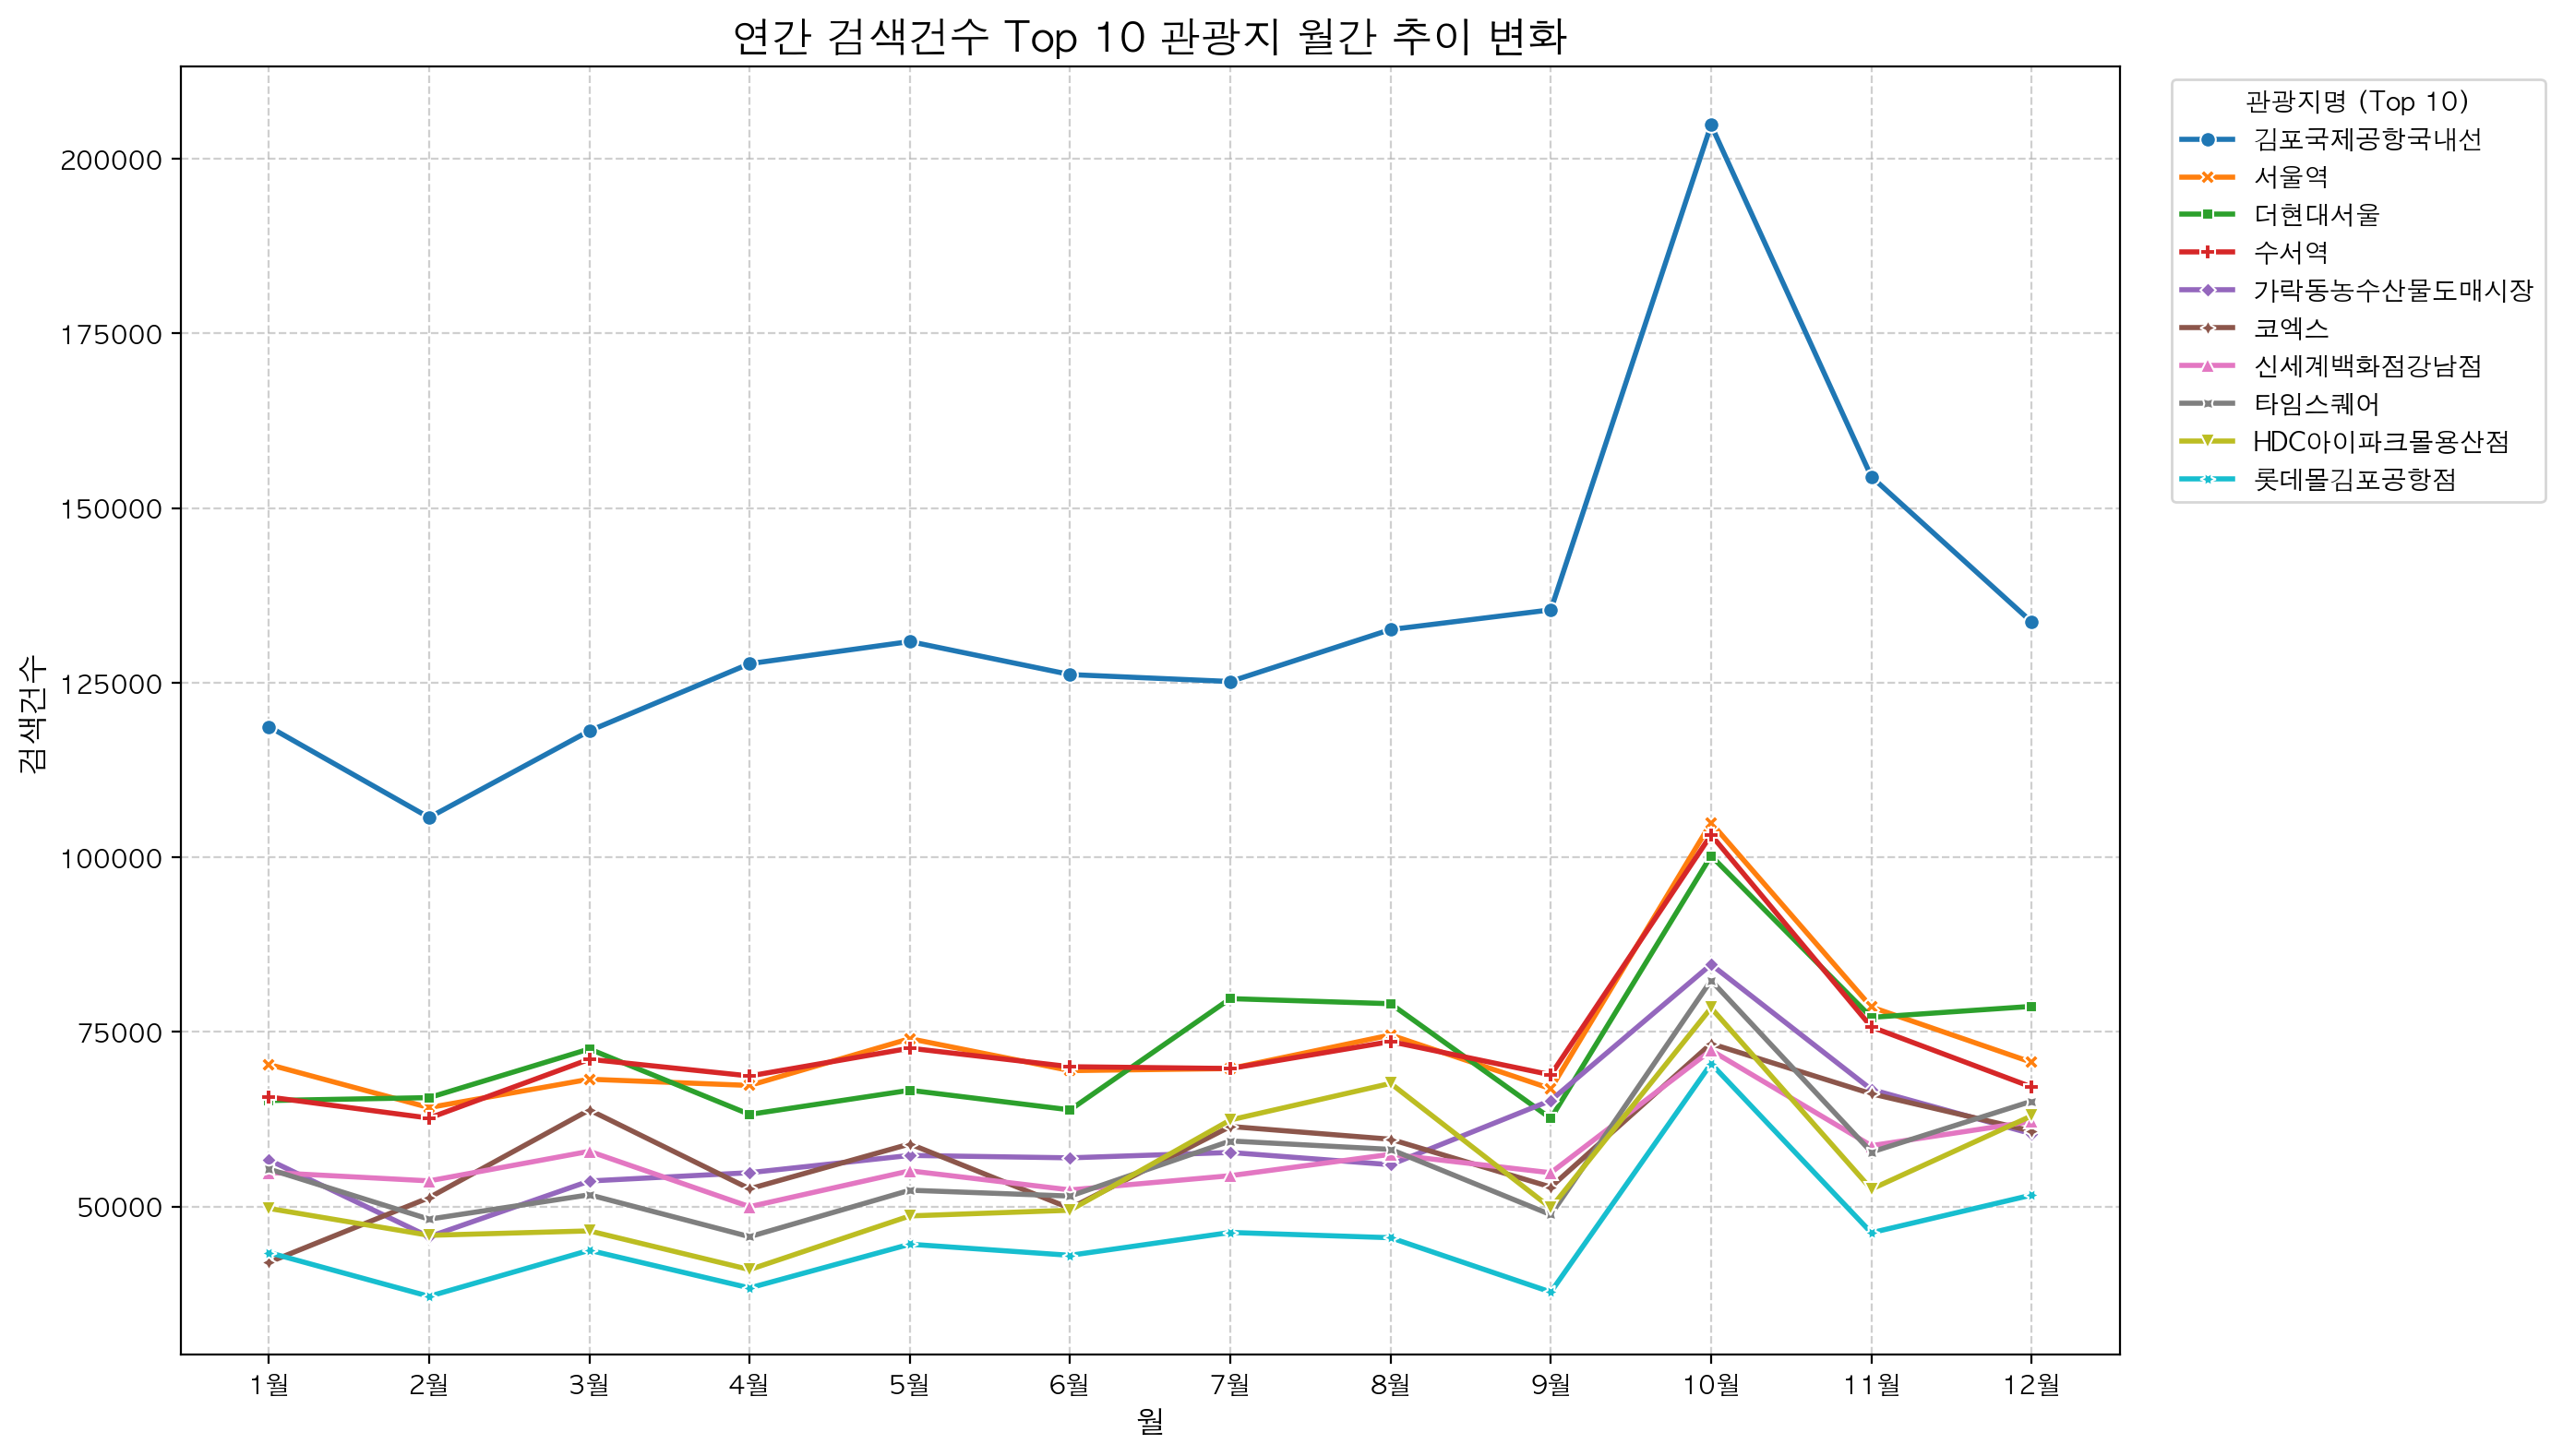

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 맥(Mac) 환경 한글 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. Top 10 관광지 추출
# ==========================================
# 기존 피벗 테이블 복사
df_pivot_top = df_pivot.copy()

# 각 행(관광지)별 1~12월 검색건수 총합 계산하여 새로운 컬럼 생성
df_pivot_top['총합'] = df_pivot_top.sum(axis=1)

# '총합' 기준으로 내림차순 정렬 후 상위 10개만 추출
df_top10 = df_pivot_top.sort_values(by='총합', ascending=False).head(10)

# 시각화할 때는 '총합' 컬럼이 필요 없으므로 제거
df_top10 = df_top10.drop(columns=['총합'])


# ==========================================
# 2. 데이터 변환 (행과 열 바꾸기)
# ==========================================
# 전치(.T)하여 X축을 '월'로 설정
df_trend_top10 = df_top10.T

# 다중 인덱스에서 '관광지명'만 범례로 사용하기 위해 컬럼명 정리
if isinstance(df_trend_top10.columns, pd.MultiIndex):
    df_trend_top10.columns = df_trend_top10.columns.get_level_values('관광지명')


# ==========================================
# 3. 시각화 (선 그래프)
# ==========================================
plt.figure(figsize=(14, 8))

# Top 10 관광지에 대한 선 그래프 (팔레트를 tab10으로 주어 10개 색상을 명확하게 구분)
sns.lineplot(data=df_trend_top10, markers=True, dashes=False, palette='tab10', linewidth=2)

plt.title('연간 검색건수 Top 10 관광지 월간 추이 변화', fontsize=16)
plt.xlabel('월', fontsize=12)
plt.ylabel('검색건수', fontsize=12)

# 범례를 우측 바깥으로 배치
plt.legend(title='관광지명 (Top 10)', bbox_to_anchor=(1.02, 1), loc='upper left')

# 수치 비교를 돕는 격자(그리드) 추가
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [41]:
# 0. '소분류 카테고리'가 '교통시설'이 아닌 데이터만 필터링 (핵심 추가)
df_filtered = df_search[df_search['소분류 카테고리'] != '교통시설']

# 1. 필터링된 데이터에서 중분류와 월별로 그룹화하여 검색건수가 최대인 인덱스 추출
idx = df_filtered.groupby(['중분류 카테고리', '월'])['검색건수'].idxmax()

# 2. 해당 인덱스의 데이터만 가져오기 (관광지명 포함)
df_monthly_top = df_filtered.loc[idx, ['중분류 카테고리', '월', '관광지명', '검색건수']]

# 3. 시각화를 위해 피벗 (행: 중분류, 열: 월, 값: 관광지명)
top_names_pivot = df_monthly_top.pivot(index='중분류 카테고리', columns='월', values='관광지명')

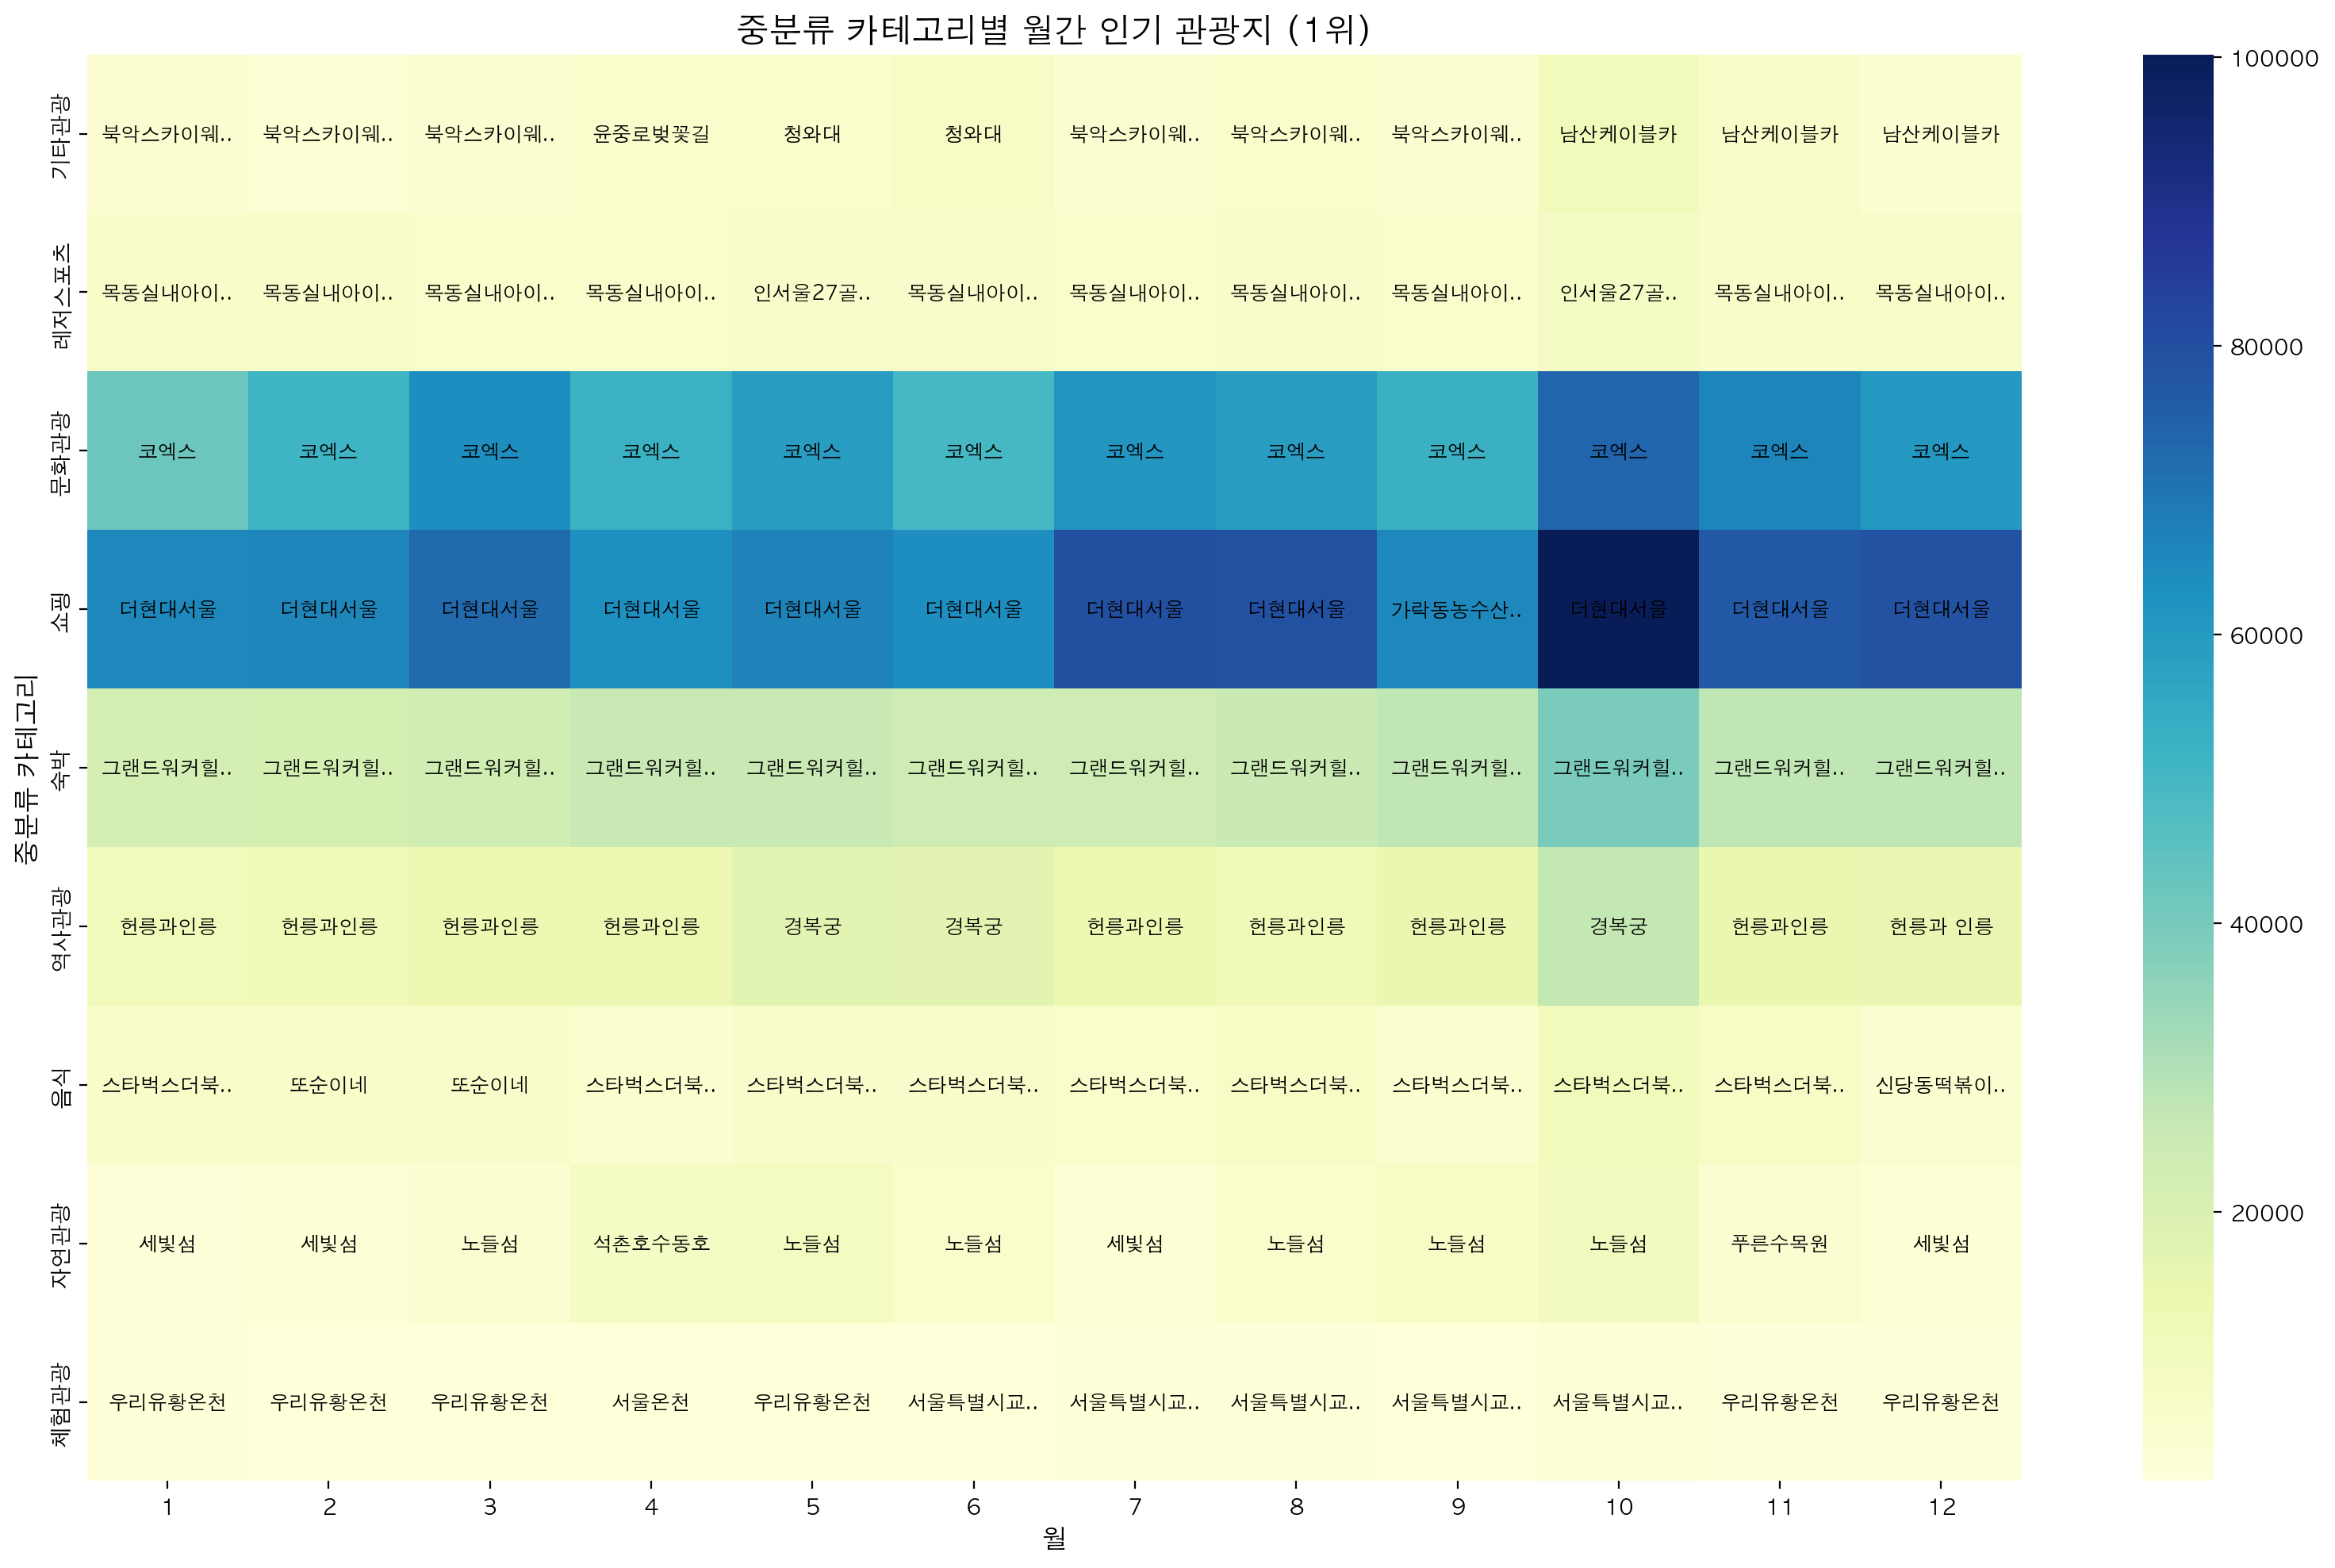

In [42]:

# 이름이 길면 앞 6글자만 보여주고 '..'을 붙이는 함수
def shorten_name(name, max_len=6):
    if len(str(name)) > max_len:
        return str(name)[:max_len] + '..'
    return str(name)

# 3. 피벗 생성 (히트맵 색상용 값)
top_values_pivot = df_monthly_top.pivot(index='중분류 카테고리', columns='월', values='검색건수')

# 4. 피벗 생성 (히트맵 텍스트 표시용 - 짧은 이름 적용)
top_names_pivot_short = df_monthly_top.pivot(index='중분류 카테고리', columns='월', values='관광지명').map(shorten_name)


# --- 시각화 ---
plt.figure(figsize=(16, 10)) # 가로를 조금 더 넓게 설정

sns.heatmap(
    top_values_pivot,
    annot=top_names_pivot_short.values, # 짧게 줄인 이름을 텍스트로 사용
    fmt="",
    cmap="YlGnBu",
    # 텍스트 스타일 조절 (글자 크기 줄임)
    annot_kws={'size': 9, 'weight': 'bold', 'color': 'black'}
)

plt.title('중분류 카테고리별 월간 인기 관광지 (1위)', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('중분류 카테고리', fontsize=12)
plt.xticks(rotation=0) # X축 레이블 회전 방지
plt.tight_layout()
plt.show()

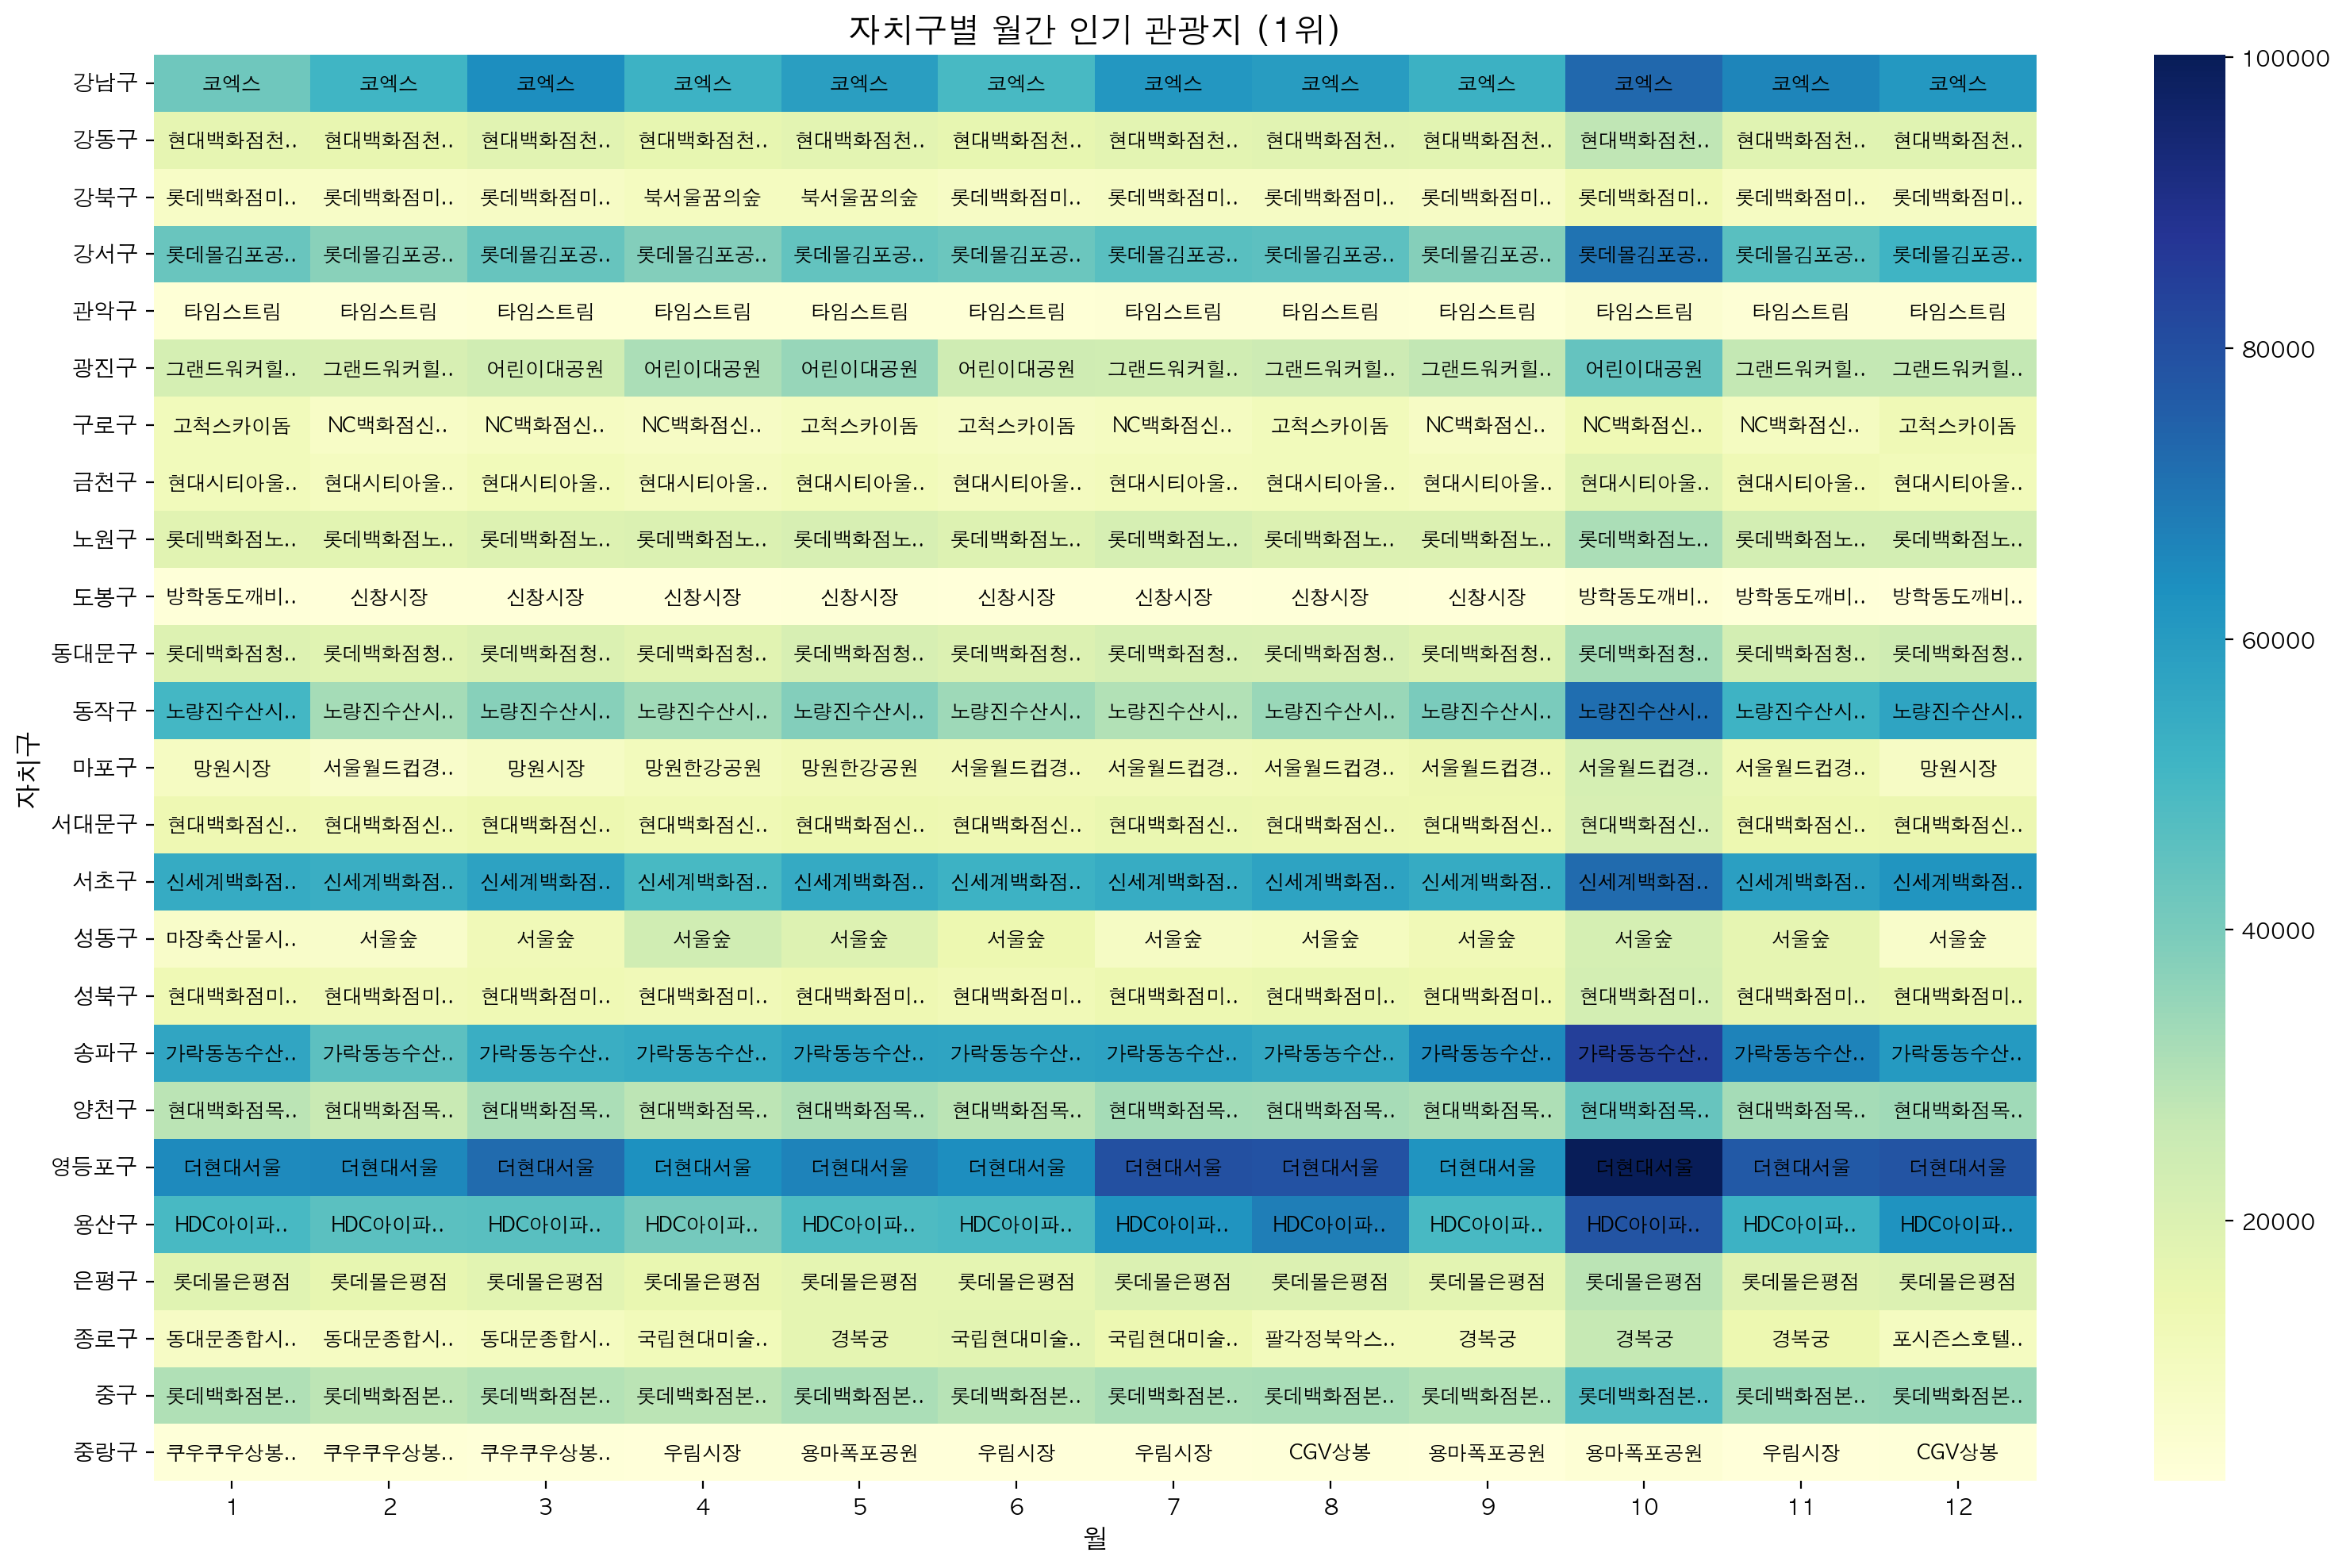

In [43]:
# 0. '소분류 카테고리'가 '교통시설'이 아닌 데이터만 필터링
df_filtered = df_search[df_search['소분류 카테고리'] != '교통시설']

# 1. 필터링된 데이터에서 '자치구'와 월별로 그룹화하여 검색건수가 최대인 인덱스 추출
idx = df_filtered.groupby(['자치구', '월'])['검색건수'].idxmax()

# 2. 해당 인덱스의 데이터만 가져오기 (변수명 변경: df_monthly_top -> df_gu_monthly_top)
df_gu_monthly_top = df_filtered.loc[idx, ['자치구', '월', '관광지명', '검색건수']]


# ==========================================
# 2. 시각화를 위한 피벗 테이블 생성
# ==========================================

# 이름이 길면 앞 6글자만 보여주고 '..'을 붙이는 함수
def shorten_name(name, max_len=6):
    if len(str(name)) > max_len:
        return str(name)[:max_len] + '..'
    return str(name)

# 3. 피벗 생성 (히트맵 색상용 값 / 변수명 변경: top_values_pivot -> gu_values_pivot)
gu_values_pivot = df_gu_monthly_top.pivot(index='자치구', columns='월', values='검색건수')

# 4. 피벗 생성 (히트맵 텍스트용 / 변수명 변경: top_names_pivot_short -> gu_names_pivot_short)
gu_names_pivot_short = df_gu_monthly_top.pivot(index='자치구', columns='월', values='관광지명').map(shorten_name)


# ==========================================
# 3. 시각화 (히트맵)
# ==========================================

plt.figure(figsize=(16, 10)) # 가로를 조금 더 넓게 설정

sns.heatmap(
    gu_values_pivot,
    annot=gu_names_pivot_short.values, # 짧게 줄인 이름을 텍스트로 사용
    fmt="",
    cmap="YlGnBu",
    # 텍스트 스타일 조절 (글자 크기 줄임)
    annot_kws={'size': 9, 'weight': 'bold', 'color': 'black'}
)

plt.title('자치구별 월간 인기 관광지 (1위)', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('자치구', fontsize=12)
plt.xticks(rotation=0) # X축 레이블 회전 방지
plt.tight_layout()
plt.show()

In [ ]:
# 1. 정렬: 카테고리 및 월별로 '검색건수'가 가장 많은 순(내림차순)으로 정렬
df_sorted = df_search.sort_values(by=['중분류 카테고리', '월', '검색건수'], ascending=[True, True, False])

# 2. Top 5 추출: 각 카테고리/월 그룹에서 상위 5개만 뽑아오기
df_top5 = df_sorted.groupby(['중분류 카테고리', '월']).head(5).copy()

# 3. 순위 매기기 (1~5위)
df_top5['순위'] = df_top5.groupby(['중분류 카테고리', '월']).cumcount() + 1

# 4. 텍스트 만들기 (예: "1. 남산서울타워")
# 표 형태는 가로 너비가 넓어지므로 굳이 글자를 자르지 않아도 잘 보입니다.
df_top5['표시텍스트'] = df_top5['순위'].astype(str) + ". " + df_top5['관광지명'].astype(str)

# 5. 같은 월, 같은 카테고리의 5개 데이터를 줄바꿈(\n)으로 묶어주기
df_text_combined = df_top5.groupby(['중분류 카테고리', '월'])['표시텍스트'].apply(lambda x: '\n'.join(x)).reset_index()

# 6. 피벗 테이블 생성 (행: 중분류, 열: 1~12월)
table_view = df_text_combined.pivot(index='중분류 카테고리', columns='월', values='표시텍스트')

# 7. 컬럼명 깔끔하게 변경 및 결측치(데이터 없는 달) 빈칸 처리
table_view.columns = [f'{int(col)}월' for col in table_view.columns]
table_view = table_view.fillna('')

# 8. 🌟 핵심 팁: 주피터 노트북에서 줄바꿈(\n)이 표에 예쁘게 적용되도록 스타일 설정 후 출력
styled_table = table_view.style.set_properties(**{
    'white-space': 'pre-wrap',  # 줄바꿈 적용
    'text-align': 'left'        # 텍스트 왼쪽 정렬 (보기 편하게)
})

# 화면에 출력
display(styled_table)

,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
중분류 카테고리,,,,,,,,,,,,
기타관광,1. 김포국제공항국내선 2. 서울역 3. 수서역 4. 서울고속버스터미널경부영동선 5. 용산역,1. 김포국제공항국내선 2. 서울역 3. 수서역 4. 서울고속버스터미널경부영동선 5. 용산역,1. 김포국제공항국내선 2. 수서역 3. 서울역 4. 서울고속버스터미널경부영동선 5. 용산역,1. 김포국제공항국내선 2. 수서역 3. 서울역 4. 서울고속버스터미널경부영동선 5. 용산역,1. 김포국제공항국내선 2. 서울역 3. 수서역 4. 서울고속버스터미널경부영동선 5. 동서울종합터미널,1. 김포국제공항국내선 2. 수서역 3. 서울역 4. 서울고속버스터미널경부영동선 5. 용산역,1. 김포국제공항국내선 2. 수서역 3. 서울역 4. 서울고속버스터미널경부영동선 5. 용산역,1. 김포국제공항국내선 2. 서울역 3. 수서역 4. 서울고속버스터미널경부영동선 5. 용산역,1. 김포국제공항국내선 2. 수서역 3. 서울역 4. 서울고속버스터미널경부영동선 5. 용산역,1. 김포국제공항국내선 2. 서울역 3. 수서역 4. 서울고속버스터미널경부영동선 5. 동서울종합터미널,1. 김포국제공항국내선 2. 서울역 3. 수서역 4. 서울고속버스터미널경부영동선 5. 동서울종합터미널,1. 김포국제공항국내선 2. 서울역 3. 수서역 4. 서울고속버스터미널경부영동선 5. 동서울종합터미널
레저스포츠,1. 목동실내아이스링크 2. 태릉국제스케이트장 3. 여의도눈썰매장 4. 인서울27골프클럽 5. 광운대학교아이스링크,1. 목동실내아이스링크 2. 태릉국제스케이트장 3. 광운대학교아이스링크 4. 인서울27골프클럽 5. 고려대아이스링크,1. 목동실내아이스링크 2. 인서울27골프클럽 3. 태릉국제스케이트장 4. 고려대아이스링크 5. 광운대학교아이스링크,1. 목동실내아이스링크 2. 인서울27골프클럽 3. 고려대아이스링크 4. 광운대학교아이스링크 5. 마곡실내배드민턴장,1. 인서울27골프클럽 2. 목동실내아이스링크 3. 고려대아이스링크 4. 광운대학교아이스링크 5. 태릉국제스케이트장,1. 목동실내아이스링크 2. 인서울27골프클럽 3. 고려대아이스링크 4. 광운대학교아이스링크 5. 동천실내스케이트장,1. 목동실내아이스링크 2. 인서울27골프클럽 3. 고려대아이스링크 4. 광운대학교아이스링크 5. 동천실내스케이트장,1. 목동실내아이스링크 2. 인서울27골프클럽 3. 고려대아이스링크 4. 광운대학교아이스링크 5. 마곡실내배드민턴장,1. 목동실내아이스링크 2. 인서울27골프클럽 3. 고려대아이스링크 4. 광운대학교아이스링크 5. 마곡실내배드민턴장,1. 인서울27골프클럽 2. 목동실내아이스링크 3. 태릉국제스케이트장 4. 고려대아이스링크 5. 광운대학교아이스링크,1. 목동실내아이스링크 2. 인서울27골프클럽 3. 고려대아이스링크 4. 태릉국제스케이트장 5. 광운대학교아이스링크,1. 목동실내아이스링크 2. 고려대아이스링크 3. 태릉국제스케이트장 4. 인서울27골프클럽 5. 광운대학교아이스링크
문화관광,1. 코엑스 2. 예술의전당 3. 롯데월드잠실점 4. 국립중앙박물관 5. CGV용산아이파크몰,1. 코엑스 2. 롯데월드잠실점 3. 예술의전당 4. 국립중앙박물관 5. CGV용산아이파크몰,1. 코엑스 2. 예술의전당 3. 롯데월드잠실점 4. 여의도한강공원 5. 어린이대공원,1. 코엑스 2. 여의도한강공원 3. 어린이대공원 4. 롯데월드잠실점 5. 서울숲,1. 코엑스 2. 어린이대공원 3. 여의도한강공원 4. 롯데월드잠실점 5. 국립중앙박물관,1. 코엑스 2. 여의도한강공원 3. 예술의전당 4. 어린이대공원 5. 롯데월드잠실점,1. 코엑스 2. 국립중앙박물관 3. 예술의전당 4. 롯데월드잠실점 5. CGV용산아이파크몰,1. 코엑스 2. 국립중앙박물관 3. 롯데월드잠실점 4. 여의도한강공원 5. 예술의전당,1. 코엑스 2. 여의도한강공원 3. 롯데월드잠실점 4. 어린이대공원 5. 예술의전당,1. 코엑스 2. 롯데월드잠실점 3. 어린이대공원 4. 여의도한강공원 5. 국립중앙박물관,1. 코엑스 2. 롯데월드잠실점 3. 올림픽공원 4. 어린이대공원 5. 예술의전당,1. 코엑스 2. 롯데월드잠실점 3. 예술의전당 4. 국립중앙박물관 5. CGV용산아이파크몰
쇼핑,1. 더현대서울 2. 가락동농수산물도매시장 3. 타임스퀘어 4. 신세계백화점강남점 5. 노량진수산시장,1. 더현대서울 2. 신세계백화점강남점 3. 타임스퀘어 4. HDC아이파크몰용산점 5. 가락동농수산물도매시장,1. 더현대서울 2. 신세계백화점강남점 3. 가락동농수산물도매시장 4. 타임스퀘어 5. HDC아이파크몰용산점,1. 더현대서울 2. 가락동농수산물도매시장 3. 신세계백화점강남점 4. 타임스퀘어 5. 롯데월드몰,1. 더현대서울 2. 가락동농수산물도매시장 3. 신세계백화점강남점 4. 타임스퀘어 5. HDC아이파크몰용산점,1. 더현대서울 2. 가락동농수산물도매시장 3. 신세계백화점강남점 4. 타임스퀘어 5. HDC아이파크몰용산점,1. 더현대서울 2. HDC아이파크몰용산점 3. 타임스퀘어 4. 가락동농수산물도매시장 5. 신세계백화점강남점,1. 더현대서울 2. HDC아이파크몰용산점 3. 타임스퀘어 4. 신세계백화점강남점 5. 가락동농수산물도매시장,1. 가락동농수산물도매시장 2. 더현대서울 3. 신세계백화점강남점 4. HDC아이파크몰용산점 5. 타임스퀘어,1. 더현대서울 2. 가락동농수산물도매시장 3. 타임스퀘어 4. HDC아이파크몰용산점 5. 신세계백화점강남점,1. 더현대서울 2. 가락동농수산물도매시장 3. 신세계백화점강남점 4. 타임스퀘어 5. HDC아이파크몰용산점,1. 더현대서울 2. 타임스퀘어 3. HDC아이파크몰용산점 4. 신세계백화점강남점 5. 가락동농수산물도매시장
숙박,1. 그랜드워커힐서울 2. 신라호텔서울 3. 그랜드하얏트서울 4. 그랜드인터컨티넨탈호텔서울파르나스 5. 롯데호텔서울점,1. 그랜드워커힐서울 2. 신라호텔서울 3. 그랜드하얏트서울 4. 그랜드인터컨티넨탈호텔서울파르나스 5. 롯데호텔서울점,1. 그랜드워커힐서울 2. 신라호텔서울 3. 그랜드하얏트서울 4. 그랜드인터컨티넨탈호텔서울파르나스 5. 롯데호텔서울점,1. 그랜드워커힐서울 2. 그랜드하얏트서울 3. 신라호텔서울 4. 그랜드인터컨티넨탈호텔서울파르나스 5. 롯데호텔서울점,1. 그랜드워커힐서울 2. 신라호텔서울 3. 그랜드하얏트서울 4. 그랜드인터컨티넨탈호텔서울파르나스 5. 롯데호텔서울점,1. 그랜드워커힐서울 2. 신라호텔서울 3. 그랜드하얏트서울 4. 그랜드인터컨티넨탈호텔서울파르나스 5. 롯데호텔서울점,1. 그랜드워커힐서울 2. 그랜드하얏트서울 3. 신라호텔서울 4. 그랜드인터컨티넨탈호텔서울파르나스 5. 콘래드서울호텔,1. 그랜드워커힐서울 2. 신라호텔서울 3. 그랜드하얏트서울 4. 그랜드인터컨티넨탈호텔서울파르나스 5. 롯데호텔서울점,1. 그랜드워커힐서울 2. 신라호텔서울 3. 그랜드하얏트서울 4. 그랜드인터컨티넨탈호텔서울파르나스 5. 롯데호텔서울점,1. 그랜드워커힐서울 2. 신라호텔서울 3. 그랜드하얏트서울 4. 롯데호텔서울점 5. 그랜드인터컨티넨탈호텔서울파르나스,1. 그랜드워커힐서울 2. 그랜드하얏트서울 3. 신라호텔서울 4. 그랜드인터컨티넨탈호텔서울파르나스 5. 롯데호텔서울점,1. 그랜드워커힐서울 2. 그랜드하얏트서울 3. 신라호텔서울 4. 그랜드인터컨티넨탈호텔서울파르나스 5. 롯데호텔서울점
역사관광,1. 헌릉과인릉 2. 경복궁 3. 봉은사 4. 광화문 5. 조계사,1. 헌릉과인릉 2. 봉은사 3. 경복궁 4. 조계사 5. 광화문,1. 헌릉과인릉 2. 봉은사 3. 경복궁 4. 광화문 5. 조계사,1. 헌릉과인릉 2. 경복궁 3. 봉은사 4. 조계사 5. 진관사,1. 경복궁 2. 헌릉과인릉 3. 봉은사 4. 진관사 5. 조계사,1. 경복궁 2. 헌릉과인릉 3. 봉은사 4. 진관사 5. 4.19기념탑,1. 헌릉과인릉 2. 경복궁 3. 봉은사 4. 조계사 5. 4.19기념탑,1. 헌릉과인릉 2. 봉은사 3. 경복궁 4. 진관사 5. 광화문,1. 헌릉과인릉 2. 경복궁 3. 봉은사 4. 진관사 5. 조계사,1. 경복궁 2. 헌릉과인릉 3. 봉은사 4. 진관사 5. 북한산성,1. 

In [ ]:
# 1. 정렬: 카테고리 무시하고 '자치구'와 '월'별 검색건수 내림차순 정렬
df_sorted = df_search.sort_values(by=['자치구', '월', '검색건수'], 
                                  ascending=[True, True, False])

# 2. Top 5 추출: 각 자치구의 월별 상위 5개만 뽑아오기
df_top5 = df_sorted.groupby(['자치구', '월']).head(5).copy()

# 3. 순위 매기기 (1~5위)
df_top5['순위'] = df_top5.groupby(['자치구', '월']).cumcount() + 1

# 4. 텍스트 만들기 (예: "1. 남산서울타워")
df_top5['표시텍스트'] = df_top5['순위'].astype(str) + ". " + df_top5['관광지명'].astype(str)

# 5. 같은 자치구, 같은 월의 5개 데이터를 줄바꿈(\n)으로 묶어주기
df_text_combined = df_top5.groupby(['자치구', '월'])['표시텍스트'].apply(lambda x: '\n'.join(x)).reset_index()

# 6. 피벗 테이블 생성 (행: 자치구, 열: 1~12월)
table_view = df_text_combined.pivot(index='자치구', columns='월', values='표시텍스트')

# 7. 컬럼명 깔끔하게 변경 및 결측치(데이터 없는 달) 빈칸 처리
table_view.columns = [f'{int(col)}월' for col in table_view.columns]
table_view = table_view.fillna('')

# 8. 스타일 설정 후 출력 (줄바꿈 및 정렬 적용)
styled_table = table_view.style.set_properties(**{
    'white-space': 'pre-wrap',  # 줄바꿈(\n)이 표에서 작동하도록 설정
    'text-align': 'left',       # 읽기 편하게 왼쪽 정렬
    'vertical-align': 'top'     # 텍스트가 칸의 위쪽부터 시작되도록 설정
})

# 화면에 출력
display(styled_table)

,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
자치구,,,,,,,,,,,,
강남구,1. 수서역 2. 코엑스 3. 현대백화점무역센터점 4. 현대백화점압구정본점 5. 롯데백화점강남점,1. 수서역 2. 코엑스 3. 현대백화점무역센터점 4. 현대백화점압구정본점 5. 롯데백화점강남점,1. 수서역 2. 코엑스 3. 현대백화점무역센터점 4. 현대백화점압구정본점 5. 롯데백화점강남점,1. 수서역 2. 코엑스 3. 현대백화점압구정본점 4. 현대백화점무역센터점 5. 그랜드인터컨티넨탈호텔서울파르나스,1. 수서역 2. 코엑스 3. 현대백화점무역센터점 4. 현대백화점압구정본점 5. 그랜드인터컨티넨탈호텔서울파르나스,1. 수서역 2. 코엑스 3. 현대백화점압구정본점 4. 현대백화점무역센터점 5. 롯데백화점강남점,1. 수서역 2. 코엑스 3. 현대백화점무역센터점 4. 현대백화점압구정본점 5. 롯데백화점강남점,1. 수서역 2. 코엑스 3. 현대백화점무역센터점 4. 현대백화점압구정본점 5. 롯데백화점강남점,1. 수서역 2. 코엑스 3. 현대백화점무역센터점 4. 현대백화점압구정본점 5. 그랜드인터컨티넨탈호텔서울파르나스,1. 수서역 2. 코엑스 3. 현대백화점압구정본점 4. 현대백화점무역센터점 5. 롯데백화점강남점,1. 수서역 2. 코엑스 3. 현대백화점무역센터점 4. 현대백화점압구정본점 5. 그랜드인터컨티넨탈호텔서울파르나스,1. 수서역 2. 코엑스 3. 현대백화점무역센터점 4. 현대백화점압구정본점 5. 그랜드인터컨티넨탈호텔서울파르나스
강동구,1. 현대백화점천호점 2. 맥도날드서울둔촌DT점 3. 뉴코아팩토리아울렛천호점 4. 백년화편 5. 암사종합시장,1. 현대백화점천호점 2. 맥도날드서울둔촌DT점 3. 뉴코아팩토리아울렛천호점 4. 강동아트센터 5. 쿠우쿠우강동점,1. 현대백화점천호점 2. 맥도날드서울둔촌DT점 3. 뉴코아팩토리아울렛천호점 4. 강동아트센터 5. 광나루한강공원,1. 현대백화점천호점 2. 맥도날드서울둔촌DT점 3. 광나루한강공원 4. 뉴코아팩토리아울렛천호점 5. 강동아트센터,1. 현대백화점천호점 2. 광나루한강공원 3. 맥도날드서울둔촌DT점 4. 강동아트센터 5. 뉴코아팩토리아울렛천호점,1. 현대백화점천호점 2. 맥도날드서울둔촌DT점 3. 광나루한강공원 4. 강동아트센터 5. 뉴코아팩토리아울렛천호점,1. 현대백화점천호점 2. 맥도날드서울둔촌DT점 3. CGV고덕강일 4. 강동아트센터 5. 스타벅스강동구청DT점,1. 현대백화점천호점 2. 맥도날드서울둔촌DT점 3. CGV고덕강일 4. 강동아트센터 5. 광나루한강공원,1. 현대백화점천호점 2. 맥도날드서울둔촌DT점 3. 광나루한강공원 4. 강동아트센터 5. 서울암사동유적,1. 현대백화점천호점 2. 맥도날드서울둔촌DT점 3. 서울암사동유적 4. 광나루한강공원 5. 뉴코아팩토리아울렛천호점,1. 현대백화점천호점 2. 맥도날드서울둔촌DT점 3. 강동아트센터 4. 뉴코아팩토리아울렛천호점 5. 광나루한강공원,1. 현대백화점천호점 2. CGV고덕강일 3. 맥도날드서울둔촌DT점 4. CGV천호 5. 강동아트센터
강북구,1. 롯데백화점미아점 2. 파라스파라서울 3. 북서울꿈의숲 4. 도선사 5. 수유시장,1. 롯데백화점미아점 2. 파라스파라서울 3. 북서울꿈의숲 4. 수유시장 5. 도선사,1. 롯데백화점미아점 2. 북서울꿈의숲 3. 파라스파라서울 4. 4.19기념탑 5. 도선사,1. 북서울꿈의숲 2. 롯데백화점미아점 3. 파라스파라서울 4. 4.19기념탑 5. 도선사,1. 북서울꿈의숲 2. 롯데백화점미아점 3. 파라스파라서울 4. 도선사 5. 4.19기념탑,1. 롯데백화점미아점 2. 북서울꿈의숲 3. 파라스파라서울 4. 4.19기념탑 5. 도선사,1. 롯데백화점미아점 2. 파라스파라서울 3. 북서울꿈의숲 4. 4.19기념탑 5. 수유시장,1. 롯데백화점미아점 2. 북서울꿈의숲 3. 안토 4. 도선사 5. 4.19기념탑,1. 롯데백화점미아점 2. 북서울꿈의숲 3. 안토 4. 4.19기념탑 5. 도선사,1. 롯데백화점미아점 2. 북서울꿈의숲 3. 도선사 4. 안토 5. 4.19기념탑,1. 롯데백화점미아점 2. 북서울꿈의숲 3. 안토 4. 도선사 5. 4.19기념탑,1. 롯데백화점미아점 2. 안토 3. 북서울꿈의숲 4. 수유시장 5. 4.19기념탑
강서구,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. 강서농산물도매시장,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. NC백화점강서점,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. NC백화점강서점,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. NC백화점강서점,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. 서울식물원,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. 강서농산물도매시장,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. NC백화점강서점,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. NC백화점강서점,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. 강서농산물도매시장,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. NC백화점강서점,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. 강서농산물도매시장,1. 김포국제공항국내선 2. 롯데몰김포공항점 3. 김포국제공항국제선 4. 김포국제공항 5. NC백화점강서점
관악구,1. 타임스트림 2. 강강술래신림점 3. 현대시장 4. 관악프라자 5. 스타벅스신림DT점,1. 타임스트림 2. 강강술래신림점 3. 관악프라자 4. 현대시장 5. 스타벅스낙성대DT점,1. 타임스트림 2. 강강술래신림점 3. 관악프라자 4. 현대시장 5. 스타벅스낙성대DT점,1. 타임스트림 2. 강강술래신림점 3. 관악프라자 4. 현대시장 5. 봉일시장,1. 타임스트림 2. 강강술래신림점 3. 관악프라자 4. 현대시장 5. 봉일시장,1. 타임스트림 2. 강강술래신림점 3. 관악프라자 4. 현대시장 5. 스타벅스신림DT점,1. 타임스트림 2. 강강술래신림점 3. 스타벅스신림DT점 4. 관악프라자 5. 현대시장,1. 타임스트림 2. 강강술래신림점 3. 관악프라자 4. 스타벅스신림DT점 5. 현대시장,1. 타임스트림 2. 강강술래신림점 3. 관악프라자 4. 현대시장 5. 스타벅스신림DT점,1. 타임스트림 2. 강강술래신림점 3. 낙성대공원 4. 관악프라자 5. 스타벅스신림DT점,1. 타임스트림 2. 강강술래신림점 3. 관악프라자 4. 현대시장 5. 스타벅스신림DT점,1. 타임스트림 2. 강강술래신림점 3. 관악프라자 4. 스타벅스신림DT점 5. 현대시장
광진구,1. 동서울종합터미널 2. 그랜드워커힐서울 3. 어린이대공원 4. 롯데백화점건대스타시티점 5. 뚝섬한강공원,1. 동서울종합터미널 2. 그랜드워커힐서울 3. 어린이대공원 4. 롯데백화점건대스타시티점 5. 뚝섬한강공원,1. 동서울종합터미널 2. 어린이대공원 3. 그랜드워커힐서울 4. 뚝섬한강공원 5. 롯데백화점건대스타시티점,1. 어린이대공원 2. 동서울종합터미널 3. 그랜드워커힐서울 4. 뚝섬한강공원 5. 롯데백화점건대스타시티점,1. 어린이대공원 2. 동서울종합터미널 3. 그랜드워커힐서울 4. 뚝섬한강공원 5. 롯데백화점건대스타시티점,1. 동서울종합터미널 2. 어린이대공원 3. 그랜드워커힐서울 4. 뚝섬한강공원 5. 롯데백화점건대스타시티점,1. 동서울종합터미널 2. 그랜드워커힐서울 3. 어린이대공원 4. 뚝섬한강공원 5. 롯데백화점건대스타시티점,1. 동서울종합터미널 2. 그랜드워커힐서울 3. 어린이대공원 4. 뚝섬한강공원 5. 롯데백화점건대스타시티점,1. 동서울종합터미널 2. 그랜드워커힐서울 3. 어린이대공원 4. 뚝섬한강공원 5. 롯데백화점건대스타시티점,1. 동서울종합터미널 2. 어린이대공원 3. 그랜드워커힐서울 4. 뚝섬한강공

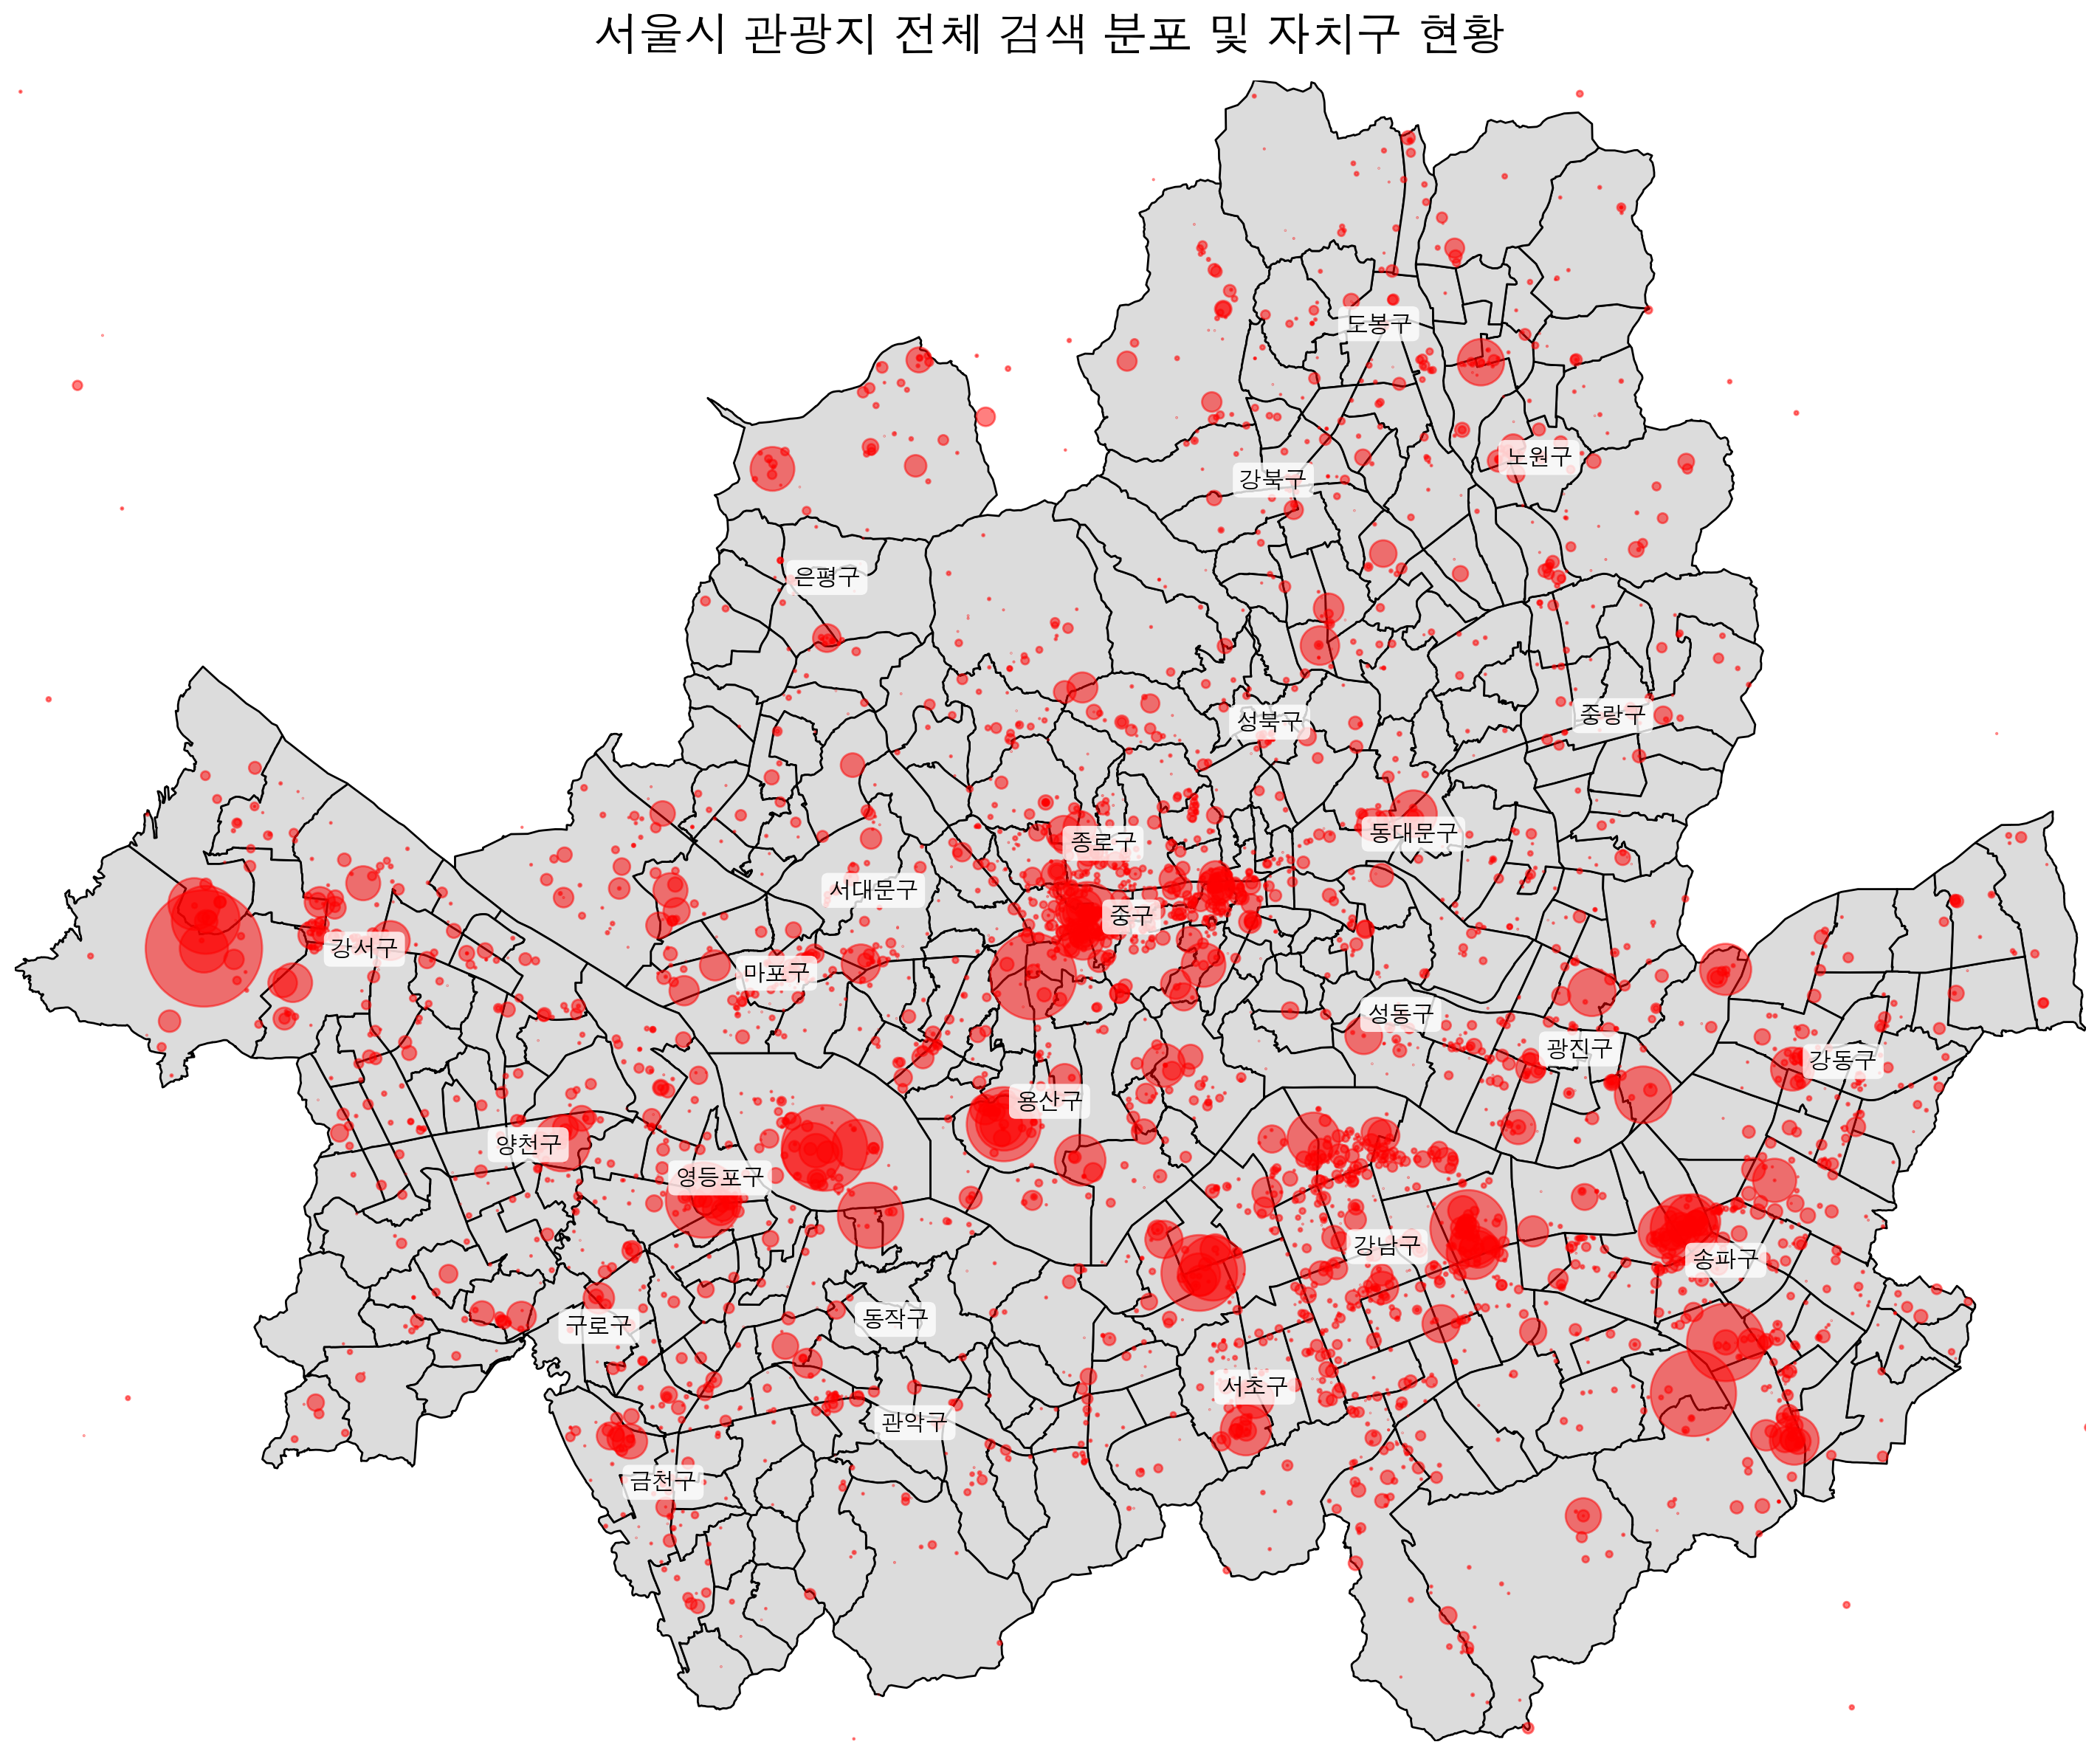

In [ ]:
# 2. 행정동 SHP 파일 불러오기
base_dir = os.getcwd()
shp_path = os.path.join(base_dir, '병합완료', '서울시 상권분석서비스(영역-행정동)', '서울시 상권분석서비스(영역-행정동).shp')
gdf_dong = gpd.read_file(shp_path, encoding='cp949') 

# 좌표계 자동 변환 (행정동 지도를 WGS84로 맞춤)
minx, miny, maxx, maxy = gdf_dong.total_bounds

if np.isnan(minx):
    print("🚨 [경고] SHP 파일에 지형 데이터가 없습니다! 폴더에 .shx 파일이 꼭 같이 있어야 합니다.")
else:
    if gdf_dong.crs is None:
        if maxx < 200:
            gdf_dong.set_crs(epsg=4326, inplace=True)
        elif maxy > 1000000:
            gdf_dong.set_crs(epsg=5179, inplace=True)
        else:
            gdf_dong.set_crs(epsg=5181, inplace=True)
            
    if gdf_dong.crs.to_epsg() != 4326:
        gdf_dong = gdf_dong.to_crs(epsg=4326)

# 3. 데이터 전처리 및 전체 기간 검색건수 합치기
df_search['X좌표 (WGS84)'] = df_search['X좌표 (WGS84)'].astype(float)
df_search['Y좌표 (WGS84)'] = df_search['Y좌표 (WGS84)'].astype(float)
df_search['검색건수'] = df_search['검색건수'].astype(float)

# 관광지별 총 검색건수 합산
df_total = df_search.groupby(['관광지명', 'X좌표 (WGS84)', 'Y좌표 (WGS84)'])['검색건수'].sum().reset_index()

# 지리 데이터(Point) 생성
gdf_points = gpd.GeoDataFrame(
    df_total, 
    geometry=gpd.points_from_xy(df_total['X좌표 (WGS84)'], df_total['Y좌표 (WGS84)']),
    crs="EPSG:4326"
)

# 4. 시각화 (도화지 큼직하게 16x12)
fig, ax = plt.subplots(figsize=(16, 12))

# 행정동 바탕 지도 그리기
gdf_dong.plot(ax=ax, color='gainsboro', edgecolor='black', linewidth=1)

# 빨간 점 찍기
if not gdf_points.empty:
    sizes = gdf_points['검색건수'] / 500  # 점 크기 조절 (필요시 1000, 2000 등으로 변경)
    gdf_points.plot(ax=ax, color='red', alpha=0.5, markersize=sizes)

# ---------------------------------------------------------
# 🌟 핵심 추가: 자치구 이름 텍스트 표시하기
# 각 자치구별 관광지 좌표의 중간값(Median)을 구해서 그 위치에 이름을 씁니다.
gu_centers = df_search.groupby('자치구')[['X좌표 (WGS84)', 'Y좌표 (WGS84)']].median().reset_index()

for idx, row in gu_centers.iterrows():
    ax.annotate(row['자치구'],
                xy=(row['X좌표 (WGS84)'], row['Y좌표 (WGS84)']),
                fontsize=11, 
                fontweight='bold',
                color='black',
                ha='center', va='center',
                # 글씨가 지도 선이나 빨간 점에 가려지지 않도록 반투명 흰색 배경 추가
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'))
# ---------------------------------------------------------

# 화면을 서울시 지도 크기에 꽉 차게 고정
minx, miny, maxx, maxy = gdf_dong.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title('서울시 관광지 전체 검색 분포 및 자치구 현황', fontsize=22, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()

# 기회지역의 수요

## 상권

In [37]:
df_commerce_final.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', '총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수',
       '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수', '연령대_40_직장_인구_수',
       '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '총_상주인구_수', '남성_상주인구_수',
       '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
       '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수', '은행_수', '약국_수',
       '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '공항_수', '철도_역_수', '버스_터미널_수',
       '지하철_역_수', '버스_정거장_수', '상권_변화_지표', '상권_변화_지표_명', '시군구코드', '자치구', '면적',
       'geometry', '총_순수방문객_수', '주간_유동인

In [50]:
# 1. 대상 행정동 리스트 정의
target_districts = [
    '역촌동', '천연동', '효창동', '가회동', 
    '정릉2동', '돈암1동', '창신3동', '사근동'
]

# 2. 보고 싶은 컬럼 리스트 정의 (오타 및 누락된 쉼표 수정)
selected_columns = [
    '기준_년분기_코드', '행정동', '상권_코드_명', '상권_구분_코드_명',
    '상권_변화_지표', '상권_변화_지표_명', '시간대별_활성화_유형', '상권_유형', '은행_수', '약국_수', 
    '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '공항_수', 
    '철도_역_수', '버스_터미널_수', '지하철_역_수', '버스_정거장_수',
]

# 3. 행정동 필터링 후 선택한 컬럼만 추출
# 데이터프레임 이름이 df_commerce_final인 경우를 가정합니다.
df_result = df_commerce_final[df_commerce_final['행정동'].isin(target_districts)][selected_columns]

In [51]:
df_result

,기준_년분기_코드,행정동,상권_코드_명,상권_구분_코드_명,상권_변화_지표,상권_변화_지표_명,시간대별_활성화_유형,상권_유형,은행_수,약국_수,백화점_수,슈퍼마켓_수,극장_수,숙박_시설_수,공항_수,철도_역_수,버스_터미널_수,지하철_역_수,버스_정거장_수
144,20253,천연동,영천시장,전통시장,HH,정체,종일 활성화,평일 상권,1.00,3.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.00
207,20253,정릉2동,정릉아리랑시장,전통시장,HL,상권축소,야간 활성화,주말 상권,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,4.00
257,20253,사근동,"한양대앞상점가(한양시장, 왕십리맛골목)",전통시장,LL,다이나믹,야간 활성화,평일 상권,NaN,1.00,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,2.00
552,20253,가회동,북촌(안국역),발달상권,LH,상권확장,주간 활성화,평일 상권,5.00,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.00
1112,20253,천연동,영천시장입구,골목상권,HH,정체,야간 활성화,평일 상권,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00
1179,20253,역촌동,응암역 3번,골목상권,LL,다이나믹,야간 활성화,주말 상권,NaN,3.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.00
1181,20253,역촌동,구산역 2번,골목상권,HL,상권축소,야간 활성화,주말 상권,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00
1192,20253,역촌동,역촌노인복지관,골목상권,LL,다이나믹,야간 활성화,주말 상권,2.00,4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.00
1352,20253,정릉2동,정릉우체국,골목상권,LH,상권확장,야간 활성화,주말 상권,1.00,3.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00
1355,20253,정릉2동,정릉역 2번,골목상권,LH,상권확장,야간 활성화,주말 상권,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00


In [52]:
import pandas as pd

# 1. 최신 분기(20253) 데이터만 필터링 (시설 수 중복 합산 방지)
df_latest = df_commerce_final[df_commerce_final['기준_년분기_코드'] == 20253]

# 2. 분석할 컬럼 정의
# 수치형 컬럼: 각 동별로 총합(Sum)을 구함
numeric_cols = [
    '은행_수', '약국_수', '백화점_수', '슈퍼마켓_수', '극장_수', 
    '숙박_시설_수', '공항_수', '철도_역_수', '버스_터미널_수', 
    '지하철_역_수', '버스_정거장_수'
]

# 범주형 컬럼: 해당 동 내에 존재하는 상권 특징들을 리스트로 요약
categorical_cols = ['상권_구분_코드_명', '상권_변화_지표_명', '시간대별_활성화_유형', '상권_유형']

# 3. 피벗 테이블 생성
# fill_value=0 을 통해 없는 시설은 0으로 표시
pivot_result = df_latest.pivot_table(
    index='행정동',
    values=numeric_cols + categorical_cols,
    aggfunc={
        **{col: 'sum' for col in numeric_cols}, # 시설 수는 모두 더함
        **{col: lambda x: ', '.join(set(x.dropna())) for col in categorical_cols} # 특징은 중복 제거 후 나열
    },
    fill_value=0
)

# 4. 가독성을 위해 컬럼 순서 재배치 (특징 먼저, 시설 수 나중)
ordered_cols = categorical_cols + numeric_cols
pivot_result = pivot_result[ordered_cols]

# 결과 출력
print("### 2025년 3분기 기준 행정동별 상권 요약 ###")
display(pivot_result)

### 2025년 3분기 기준 행정동별 상권 요약 ###


,상권_구분_코드_명,상권_변화_지표_명,시간대별_활성화_유형,상권_유형,은행_수,약국_수,백화점_수,슈퍼마켓_수,극장_수,숙박_시설_수,공항_수,철도_역_수,버스_터미널_수,지하철_역_수,버스_정거장_수
행정동,,,,,,,,,,,,,,,
가락1동,발달상권,정체,종일 활성화,평일 상권,4.00,2.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,2.00,9.00
가락2동,"골목상권, 발달상권","다이나믹, 정체, 상권축소","종일 활성화, 야간 활성화","평일 상권, 주말 상권",4.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00
가락본동,"골목상권, 발달상권, 전통시장","다이나믹, 정체, 상권확장, 상권축소",종일 활성화,평일 상권,11.00,27.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,22.00
가리봉동,"골목상권, 발달상권, 전통시장","다이나믹, 정체, 상권축소","종일 활성화, 야간 활성화","평일 상권, 주말 상권",0.00,6.00,0.00,0.00,0.00,18.00,0.00,0.00,0.00,1.00,12.00
가산동,"골목상권, 발달상권","다이나믹, 정체, 상권축소","야간 활성화, 종일 활성화, 주간 활성화","평일 상권, 주말 상권",25.00,18.00,0.00,0.00,1.00,16.00,0.00,0.00,0.00,2.00,97.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
효창동,골목상권,정체,"종일 활성화, 야간 활성화","평일 상권, 주말 상권",1.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11.00
후암동,"골목상권, 전통시장","다이나믹, 정체, 상권확장",야간 활성화,주말 상권,1.00,8.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,11.00
휘경1동,"골목상권, 발달상권, 전통시장","상권확장, 다이나믹, 정체","종일 활성화, 야간 활성화",주말 상권,0.00,7.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,3.00,13.00


In [ ]:
# 1. 분석 대상 설정
target_districts = ['역촌동', '천연동', '효창동', '가회동', '정릉2동', '돈암1동', '창신3동', '사근동']
selected_columns = [
    '행정동', '상권_코드_명', '상권_구분_코드_명', '상권_변화_지표_명', 
    '시간대별_활성화_유형', '상권_유형', '은행_수', '약국_수', '지하철_역_수', '버스_정거장_수'
]

# 2. 최신 분기 데이터 필터링 및 필요한 컬럼 추출
df_detail = df_commerce_final[
    (df_commerce_final['기준_년분기_코드'] == 20253) & 
    (df_commerce_final['행정동'].isin(target_districts))
][selected_columns]

# 3. 행정동 - 상권명 순으로 정렬 후 계층적 인덱스 설정
# 이렇게 하면 '행정동'이 묶여서 보여서 훨씬 가독성이 좋습니다.
df_hierarchy = df_detail.sort_values(['행정동', '상권_코드_명']).set_index(['행정동', '상권_코드_명'])

# 4. 결과 출력
print(f"### 행정동 내 상권별 특징 상세 리스트 (2025년 3분기) ###")
display(df_hierarchy)

### 행정동 내 상권별 특징 상세 리스트 (2025년 3분기) ###


상권_구분_코드_명 상권_변화_지표_명 시간대별_활성화_유형  상권_유형  은행_수  \
행정동  상권_코드_명                                                                
가회동  북촌(안국역)                     발달상권       상권확장      주간 활성화  평일 상권  5.00   
     정독도서관                       골목상권       상권확장      주간 활성화  평일 상권   NaN   
     중앙고등학교                      골목상권         정체      주간 활성화  평일 상권   NaN   
사근동  사근동살곶이상점가                   골목상권       상권확장      야간 활성화  평일 상권   NaN   
     한양대앞상점가(한양시장, 왕십리맛골목)       전통시장       다이나믹      야간 활성화  평일 상권   NaN   
     한양대역 4번                     골목상권       상권확장      야간 활성화  평일 상권  1.00   
역촌동  구산역 2번                      골목상권       상권축소      야간 활성화  주말 상권   NaN   
     역촌노인복지관                     골목상권       다이나믹      야간 활성화  주말 상권  2.00   
     응암역 3번                      골목상권       다이나믹      야간 활성화  주말 상권   NaN   
정릉2동 정릉아리랑시장                     전통시장       상권축소      야간 활성화  주말 상권  1.00   
     정릉역 2번                      골목상권       상권확장      야간 활성화  주말 상권  1.00   
     정릉우체국                       골목상권       상권확장      야간 활성화  주말 상권  1.00   
창신3동 창신역 1번                      골목상권         정체      종일 활성화  주말 상권   NaN   
천연동  영천시장                        전통시장         정체      종일 활성화  평일 상권  1.00   
     영천시장입구                      골목상권         정체      야간 활성화  평일 상권   NaN   
효창동  효창공원앞역 2번                   골목상권         정체      종일 활성화  평일 상권  1.00   
     효창동주민센터                     골목상권         정체      야간 활성화  주말 상권   NaN   

                            약국_수  지하철_역_수  버스_정거장_수  
행정동  상권_코드_명                                         
가회동  북촌(안국역)                2.00      NaN      9.00  
     정독도서관                   NaN      NaN      4.00  
     중앙고등학교                  NaN      NaN      7.00  
사근동  사근동살곶이상점가              2.00      NaN      8.00  
     한양대앞상점가(한양시장, 왕십리맛골목)  1.00      NaN      2.00  
     한양대역 4번                 NaN      NaN      1.00  
역촌동  구산역 2번                  NaN      NaN      2.00  
     역촌노인복지관                4.00      NaN      6.00  
     응암역 3번                 3.00      NaN      9.00  
정릉2동 정릉아리랑시장                 NaN     1.00      4.00  
     정릉역 2번                  NaN      NaN      3.00  
     정릉우체국                  3.00      NaN      5.00  
창신3동 창신역 1번                  NaN     1.00      4.00  
천연동  영천시장                   3.00      NaN     10.00  
     영천시장입구                  NaN      NaN      3.00  
효창동  효창공원앞역 2번              1.00      NaN      4.00  
     효창동주민센터                2.00      NaN      7.00